# Bias-variance in the Linear model

## Initialize

In [1]:
# import required libraries
import numpy as np
from numpy.polynomial.polynomial import Polynomial
import sympy as sp
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import tensorflow as tf #type: ignore
import torch #type: ignore
#
from IPython.display import display, Math
# Import typyng library for type hinting
from typing import Callable, Union, List, Any, Tuple
#
# Initialize pretty printing
sp.init_printing()

## True Model Definition

In [2]:
def series_expansion(f: sp.Expr, 
                     x: sp.Symbol, 
                     a: Union[int, float], 
                     n: int
                    ) -> sp.Expr:
    """
    Expands the given function f around point a to the n-th order.
    
    Args:
        f: A SymPy function to be expanded.
        x: The symbolic variable used in function f.
        a: The point around which the series is expanded.
        n: The order up to which the series is expanded.
        
    Returns:
        The series expansion of f as a SymPy expression.
    """
    return f.series(x, a, n+1).removeO()

def evaluate_expansion(expansion_func: Callable[[np.ndarray], np.ndarray], 
                       x_values: np.ndarray
                      ) -> np.ndarray:
    """
    Evaluates a given series expansion function for an array of x values.
    
    Args:
        expansion_func: A lambda function that takes x_values and evaluates the series expansion.
        x_values: A numpy array of x values at which to evaluate the expansion.
        
    Returns:
        A numpy array containing the evaluated series expansion at each x value.
    """
    try:
        result: np.ndarray = expansion_func(x_values)  # Variable annotation for Python 3.9+
        if np.isscalar(result):
            result = np.full(shape=x_values.shape, fill_value=result)  # Reusing annotation
    except TypeError:
        # Handles cases where the expansion function does not naturally vectorize
        result = np.vectorize(expansion_func)(x_values)  # Reusing annotation
    return result

# Main execution
if __name__ == "__main__": # not necessary when running in a Jupyter notebook
    i: int
    # Define the symbolic variable
    x: sp.Symbol = sp.symbols('x')

    # Define the function
    func: sp.Expr = sp.sympify(3) + sp.sin(x) - sp.cos(x)

    print("Function:", func)
    for i in range(10):
        # Generate and print series expansion up to x^i
        expn: sp.Expr = series_expansion(func, x, 0, i)
        print(f"Series Expansion at x^{i}:", expn)

        # Example: Convert series expansion to a lambda function for evaluation
        # (Illustration purposes; adjust x_vals as needed)
        x_vals: np.ndarray = np.linspace(-4, 4, 400)
        lambda_expn: Callable[[np.ndarray], np.ndarray] = sp.lambdify(x, expn, 'numpy')
        evaluated_vals: np.ndarray = evaluate_expansion(lambda_expn, x_vals)
        
        # The `evaluate_expansion` function's usage depends on further processing or plotting of `evaluated_vals`


Function: sin(x) - cos(x) + 3
Series Expansion at x^0: 2
Series Expansion at x^1: x + 2
Series Expansion at x^2: x**2/2 + x + 2
Series Expansion at x^3: -x**3/6 + x**2/2 + x + 2
Series Expansion at x^4: -x**4/24 - x**3/6 + x**2/2 + x + 2
Series Expansion at x^5: x**5/120 - x**4/24 - x**3/6 + x**2/2 + x + 2
Series Expansion at x^6: x**6/720 + x**5/120 - x**4/24 - x**3/6 + x**2/2 + x + 2
Series Expansion at x^7: -x**7/5040 + x**6/720 + x**5/120 - x**4/24 - x**3/6 + x**2/2 + x + 2
Series Expansion at x^8: -x**8/40320 - x**7/5040 + x**6/720 + x**5/120 - x**4/24 - x**3/6 + x**2/2 + x + 2
Series Expansion at x^9: x**9/362880 - x**8/40320 - x**7/5040 + x**6/720 + x**5/120 - x**4/24 - x**3/6 + x**2/2 + x + 2


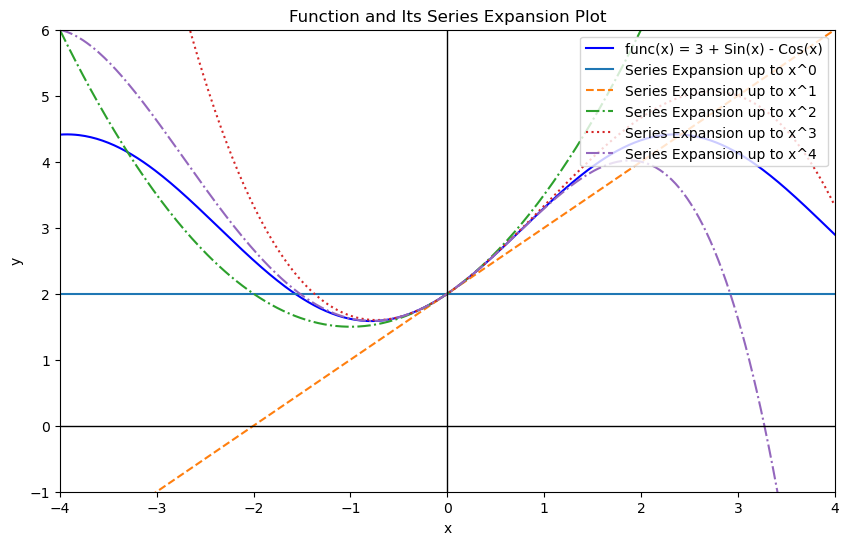

In [3]:
# Lambda function to convert SymPy expressions to NumPy functions
def sympy_to_numpy_function(sympy_func: sp.Expr, 
                            symbol: sp.Symbol
                           ) -> Callable[[np.ndarray], np.ndarray]:
    """
    Converts a SymPy function of a single variable to a NumPy-compatible function.
    
    Args:
        sympy_func: A SymPy expression representing the function.
        symbol: The SymPy symbol used in sympy_func.
    
    Returns:
        A lambda function that evaluates sympy_func over NumPy arrays.
    """
    return sp.lambdify(symbol, sympy_func, modules=['numpy'])

# Function to evaluate series expansions
def evaluate_expansion(expansion_func: Callable[[np.ndarray], np.ndarray], 
                       x_values: np.ndarray
                      ) -> np.ndarray:
    """
    Evaluates a given series expansion function for an array of x values.
    
    Args:
        expansion_func: A lambda function that takes x_values and evaluates the series expansion.
        x_values: A numpy array of x values at which to evaluate the expansion.
        
    Returns:
        A numpy array containing the evaluated series expansion at each x value.
    """
    # Evaluate the expansion for the provided x values
    result: np.ndarray = expansion_func(x_values)
    
    # Check if the result is a scalar and, if so, create an array filled with this value
    if np.isscalar(result):
        result = np.full_like(x_values, fill_value=result)
    
    return result

# Generate x values
x_values: np.ndarray = np.linspace(-4, 4, 400)

# Convert the main function to a numerical function and evaluate
func_lambdified: Callable[[np.ndarray], np.ndarray] = sympy_to_numpy_function(func, x)
y_values_func: np.ndarray = func_lambdified(x_values)

# Define line styles for different series expansions
line_styles: List[str] = ['-', '--', '-.', ':', 'dashdot']

# Plot the original function
plt.figure(figsize=(10, 6))
plt.plot(x_values, y_values_func, label='func(x) = 3 + Sin(x) - Cos(x)', color='blue', linestyle='-')

# Plot series expansions
n: int
style: str
for n, style in zip(range(5), line_styles):
    expansion_expr: sp.Expr = series_expansion(func, x, 0, n)
    expansion_lambdified: Callable[[np.ndarray], np.ndarray] = sympy_to_numpy_function(expansion_expr, x)
    y_values_expansion: np.ndarray = evaluate_expansion(expansion_lambdified, x_values)
    plt.plot(x_values, y_values_expansion, label=f'Series Expansion up to x^{n}', linestyle=style)

# Finalizing the plot
plt.title('Function and Its Series Expansion Plot')
plt.axhline(y=0, color='k', linestyle='-', linewidth=1)  # Horizontal line for x-axis
plt.axvline(x=0, color='k', linestyle='-', linewidth=1)  # Vertical line for y-axis
plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc='upper right')
plt.xlim(-4, 4)
plt.ylim(-1, 6)
plt.show()


## Numpy code

### Probabilistic model (polynomial data)

In [443]:
def y(x: np.ndarray) -> np.ndarray:
    """Generates polynomial data based on a given polynomial expression.
    
    Args:
        x: A numpy array of x values.
    
    Returns:
        A numpy array of y values computed from the polynomial expression.
    """
    return -x**4/24 - x**3/6 + x**2/2 + x + 2

def y_stat(x: np.ndarray,
           std: float = 0.1
          ) -> np.ndarray:
    """Generates noisy polynomial data by adding Gaussian noise to the true y values.
    
    Args:
        x: A numpy array of x values.
    
    Returns:
        A numpy array of y values computed from the polynomial expression with added Gaussian noise.
    """
    # Generate true y values based on a polynomial expression
    true_y_values: np.ndarray = y(x)
    
    # Add Gaussian noise with a mean of 0 and standard deviation of 1 to the true y values
    noisy_y_values: np.ndarray = np.random.normal(true_y_values, std)
    
    return noisy_y_values

def design_matrix(degree: int, 
                  x_values: np.ndarray
                 ) -> np.ndarray:
    """Generates a design matrix for polynomial regression of a specified degree.
    
    Args:
        degree: The degree of the polynomial hypothesis.
        x_values: A numpy array of x values.
    
    Returns:
        A design matrix as a numpy array.
    """
    return np.array([[x**i for i in range(degree+1)] for x in x_values])

def omega_solution(X: np.ndarray, 
                   Y: np.ndarray
                  ) -> np.ndarray:
    """Calculates the polynomial coefficients (omega) that best fit the data.
    
    Args:
        X: The design matrix.
        Y: A numpy array of target y values.
    
    Returns:
        A numpy array of calculated omega values.
    """
    return np.linalg.pinv(X.T @ X) @ X.T @ Y

def poly_solution(omega_solution: np.ndarray) -> Polynomial:
    """Converts omega coefficients to a numpy Polynomial object.
    
    Args:
        omega_solution: A numpy array of omega coefficients.
    
    Returns:
        A numpy Polynomial object representing the fitted polynomial.
    """
    return Polynomial(omega_solution)

In [444]:
def generate_data(x: np.ndarray,
                  std: float = 0.1,
                  n: int = 1
                 ) -> np.ndarray:
    """Generates Monte Carlo data for a given set of x values, noise level, and number of samples.
    
    Args:
        x: A numpy array of x values.
    
    Returns:
        A numpy array of y values generated from the statistical model.
    """
    data = np.array([np.concatenate((x.reshape(-1, 1), y_stat(x, std).reshape(-1, 1)), axis=1) for _ in range(n)])
    return data

# Generate data coordinates
step = 1
x_values: np.ndarray = np.arange(-3, 3+step, step)

np.random.seed(100)
train_data = generate_data(x_values, 1, 1)
test_data = generate_data(x_values, 1, 1)
train_MC = generate_data(x_values, 1, 1000)
test_MC = generate_data(x_values, 1, 1000)

In [445]:
def fit(data: np.ndarray,
        d: int,
        x: np.ndarray
       ) -> np.ndarray:
    """Fits a polynomial of degree d to the given data and computes the polynomial at the x values.
    
    Args:
        data: A numpy array of data points.
        d: The degree of the polynomial to fit.
        x: A numpy array of x values.
        
    Returns:
        The fitted polynomial computed at the x values.
    """
    result: list = []
    for dat in data:
        X = design_matrix(d, dat[:, 0])
        Y = dat[:, 1]
        omega = omega_solution(X, Y)
        poly = poly_solution(omega)
        val = poly(x)
        result.append(val)
    return np.array(result)

In [446]:
fit(train_data, 3, x_values)

array([[3.25581018, 2.233492  , 2.44612719, 3.22223603, 3.89033881,
        3.7789558 , 2.21660731]])

In [447]:
fit(train_MC, 3, x_values)

array([[5.20256288, 2.5745848 , 1.77064255, ..., 2.87954765, 3.41473608,
        3.01864248],
       [6.31255258, 1.97038503, 1.1326947 , ..., 4.0091147 , 4.74240954,
        3.01855061],
       [4.68723732, 2.01569147, 1.34106384, ..., 2.84566773, 3.45645149,
        2.92725797],
       ...,
       [4.70063054, 2.63664735, 1.76452261, ..., 1.82304792, 1.8672977 ,
        1.33060537],
       [5.96801499, 1.91300172, 0.86169998, ..., 2.5086146 , 2.57602271,
        0.38552586],
       [3.86268523, 1.32345491, 0.88393333, ..., 2.60223425, 2.90916568,
        1.6140237 ]], shape=(1000, 7))

In [448]:
np.mean(fit(train_MC, 3, x_values), axis=0)

array([4.87192469, 2.17290124, 1.69106103, 2.4195304 , 3.35143573,
       3.47990335, 1.79805962])

In [449]:
def Ef(d: int,
       x: np.ndarray
      ) -> np.ndarray:
    """
    Computes the expected value of the polynomial fit over multiple Monte Carlo samples.
    
    Args:
        d: The degree of the polynomial to fit.
        x: A numpy array of x values.
        
    Returns:
        The expected value of the polynomial fit at the x values.
    """
    fit_vals = fit(train_MC, d, x)
    return np.mean(fit_vals, axis=0)

def Varf(d: int,
         x: np.ndarray
        ) -> np.ndarray:
        """Computes the variance of the polynomial fit over multiple Monte Carlo samples.
        
        Args:
            d: The degree of the polynomial to fit.
            x: A numpy array of x values.
            
        Returns:
            The variance of the polynomial fit at the x values.
        """
        fit_vals = fit(train_MC, d, x)
        return np.mean(np.var(fit_vals, axis=0))
    
def Bias2f(d: int,
           x: np.ndarray
          ) -> np.ndarray:
     """Computes the squared bias of the polynomial fit over multiple Monte Carlo samples.
     
     Args:
          d: The degree of the polynomial to fit.
          x: A numpy array of x values.
          
     Returns:
          The squared bias of the polynomial fit at the x values.
     """
     Ef_vals = Ef(d, x)
     return np.mean((Ef_vals - y(x))**2)
 
def Noise_variance(x: np.ndarray) -> float:
    """Computes the noise variance of the data.
    
    Args:
        data: A numpy array of data points.
        
    Returns:
        The noise variance for a given data point x
    """
    lst: list = []
    for i in range(test_MC.shape[1]):
        lst.append(np.mean((y(test_MC[:, i, 0])-test_MC[:, i, 1])**2))
    return np.mean(lst)        

def MSE_MC(d: int,
          ) -> np.ndarray:
    """Computes the mean squared error of the polynomial fit over multiple Monte Carlo samples.
    
    Args:
        d: The degree of the polynomial to fit.
        x: A numpy array of x values.
        
    Returns:
        The mean squared error of the polynomial fit at the x values.
    """
    #print("Train MC data:", train_MC)
    #print("Test MC data:", test_MC)
    x_test = test_MC[:, :, 0]
    #print("Test x values:", x_test)
    y_test = test_MC[:, :, 1]
    #print("Test y values:", y_test)
    y_train_pred = fit(train_MC, d, x_test)
    #print("Predicted y values from multiple trainings:", y_train_pred)
    #print("Difference between predicted and true y values:", y_train_pred - y_test)
    #print("Mean squared error over train data for each test data:", np.mean((y_test - y_train_pred)**2, axis=0))
    #print("Mean squared error over train and test data:", np.mean(np.mean((y_test - y_train_pred)**2, axis=0), axis=0))
    #print("Mean squared error over train and test data and over data points:", np.mean(np.mean(np.mean((y_test - y_train_pred)**2, axis=1), axis=0)))
    return np.mean((y_test - y_train_pred)**2)

In [450]:
Ef(3, x_values)

array([4.87192469, 2.17290124, 1.69106103, 2.4195304 , 3.35143573,
       3.47990335, 1.79805962])

In [451]:
Varf(3, x_values)

In [452]:
Bias2f(3, x_values)

In [453]:
Noise_variance(x_val)

In [454]:
MSE_MC(3)

In [455]:
result: list = []
for d in range(10):
    #Ef_val = Ef(d, x_values)
    Varf_val = Varf(d, x_values)
    Bias2f_val = Bias2f(d, x_values)
    Noise_variance_val = Noise_variance(x_values)
    sum_val = Bias2f_val + Varf_val + Noise_variance_val
    MSE_MC_val = MSE_MC(d)
    result.append((d, Varf_val, Bias2f_val, Noise_variance_val, sum_val, MSE_MC_val))


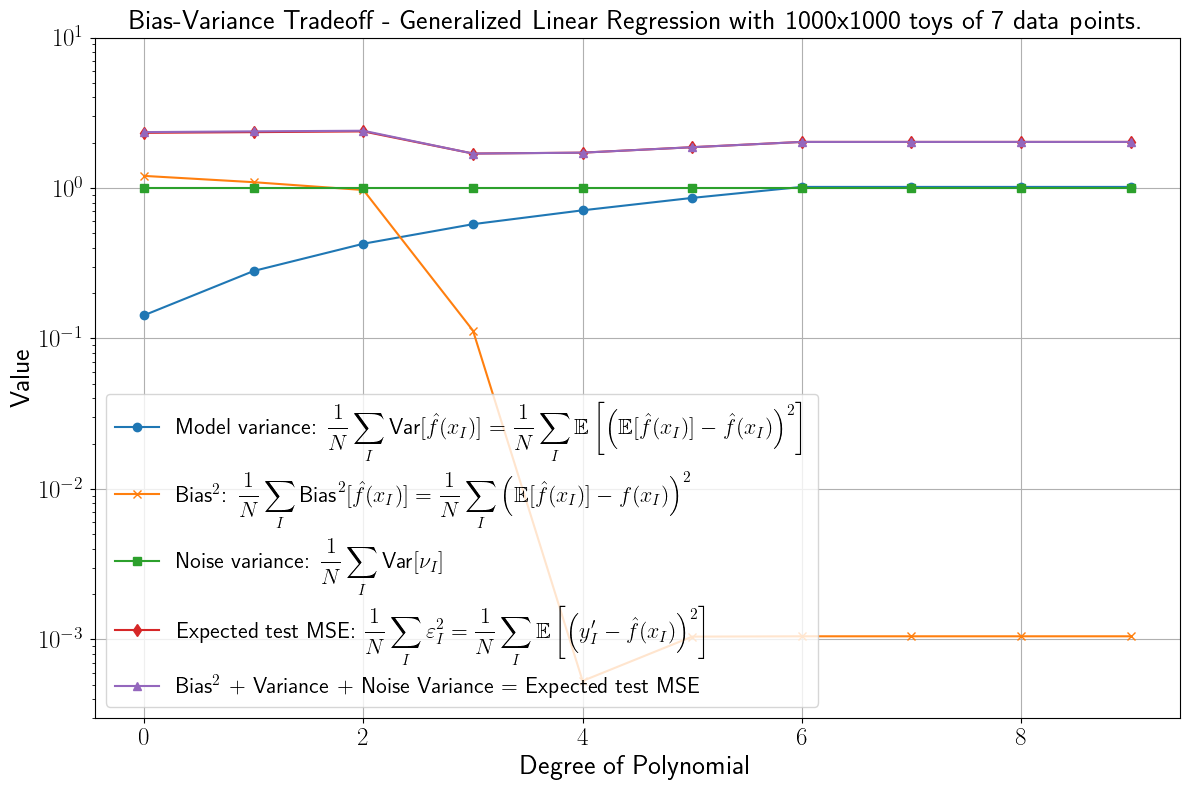

In [456]:
plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r"""\usepackage{amsmath}
\usepackage{amsfonts}
\usepackage{amssymb}
\usepackage{bm}"""

# Plot the various quantities vs the degree of the polynomial
degrees, variances, biases, noise_variances, sums, mse_mc = zip(*result)
plt.figure(figsize=(12, 8))

plt.plot(degrees, variances, label=r'Model variance: $\displaystyle\frac{1}{N} \sum_{I}\text{Var}[\hat{f}(x_{I})] = \frac{1}{N} \sum_{I}\mathbb{E}\left[\left(\mathbb{E}[\hat{f}(x_{I})] - \hat{f}(x_{I})\right)^{2}\right]$', marker='o')
plt.plot(degrees, biases, label=r'Bias$^2$: $\displaystyle\frac{1}{N} \sum_{I}\text{Bias}^{2}[\hat{f}(x_{I})] = \frac{1}{N} \sum_{I}\left(\mathbb{E}[\hat{f}(x_{I})] - f(x_{I})\right)^{2}$', marker='x')
plt.plot(degrees, noise_variances, label=r'Noise variance: $\displaystyle\frac{1}{N} \sum_{I}\text{Var}[\nu_{I}]$', marker='s')
plt.plot(degrees, mse_mc, label=r'Expected test MSE: $\displaystyle\frac{1}{N} \sum_{I}\varepsilon_{I}^{2} = \frac{1}{N} \sum_{I}\mathbb{E}\left[\left(y_{I}^{\prime} - \hat{f}(x_{I})\right)^{2}\right]$', marker='d')
plt.plot(degrees, sums, label=r'Bias$^2$ + Variance + Noise Variance = Expected test MSE', marker='^')

plt.tick_params(axis='both', which='major', labelsize=18)
plt.xlabel('Degree of Polynomial', fontsize = 20)
plt.ylabel('Value', fontsize = 20)
plt.title('Bias-Variance Tradeoff - Generalized Linear Regression with '+ str(len(train_MC))+ 'x'+str(len(train_MC))+ ' toys of '+ str(len(x_values))+' data points.', fontsize = 20)
plt.legend(loc='lower left', fontsize = 16)
plt.grid(True)
plt.yscale('log')
plt.ylim(3e-4, 10)
plt.tight_layout()
plt.savefig(f'/Users/rtorre/Dropbox/Apps/Overleaf/ML Methods for Physics/Figures/Chapter_3/variance_bias_tradeoff_1.pdf')
plt.show()

### Probabilistic model (non-polynomial data)

In [457]:
def y(x: np.ndarray) -> np.ndarray:
    """Generates polynomial data based on a given polynomial expression.
    
    Args:
        x: A numpy array of x values.
    
    Returns:
        A numpy array of y values computed from the polynomial expression.
    """
    return 3 + np.sin(x) - np.cos(x)

def y_stat(x: np.ndarray,
           std: float = 0.1
          ) -> np.ndarray:
    """Generates noisy polynomial data by adding Gaussian noise to the true y values.
    
    Args:
        x: A numpy array of x values.
    
    Returns:
        A numpy array of y values computed from the polynomial expression with added Gaussian noise.
    """
    # Generate true y values based on a polynomial expression
    true_y_values: np.ndarray = y(x)
    
    # Add Gaussian noise with a mean of 0 and standard deviation of 1 to the true y values
    noisy_y_values: np.ndarray = np.random.normal(true_y_values, std)
    
    return noisy_y_values

In [458]:
def generate_data(x: np.ndarray,
                  std: float = 0.1,
                  n: int = 1
                 ) -> np.ndarray:
    """Generates Monte Carlo data for a given set of x values, noise level, and number of samples.
    
    Args:
        x: A numpy array of x values.
    
    Returns:
        A numpy array of y values generated from the statistical model.
    """
    data = np.array([np.concatenate((x.reshape(-1, 1), y_stat(x, std).reshape(-1, 1)), axis=1) for _ in range(n)])
    return data

# Generate data coordinates
step = 1
x_values: np.ndarray = np.arange(-3, 3+step, step)

np.random.seed(100)
train_data = generate_data(x_values, 1, 1)
test_data = generate_data(x_values, 1, 1)
train_MC = generate_data(x_values, 1, 1000)
test_MC = generate_data(x_values, 1, 1000)

In [459]:
def Ef(d: int,
       x: np.ndarray
      ) -> np.ndarray:
    """
    Computes the expected value of the polynomial fit over multiple Monte Carlo samples.
    
    Args:
        d: The degree of the polynomial to fit.
        x: A numpy array of x values.
        
    Returns:
        The expected value of the polynomial fit at the x values.
    """
    fit_vals = fit(train_MC, d, x)
    return np.mean(fit_vals, axis=0)

def Varf(d: int,
         x: np.ndarray
        ) -> np.ndarray:
        """Computes the variance of the polynomial fit over multiple Monte Carlo samples.
        
        Args:
            d: The degree of the polynomial to fit.
            x: A numpy array of x values.
            
        Returns:
            The variance of the polynomial fit at the x values.
        """
        fit_vals = fit(train_MC, d, x)
        return np.mean(np.var(fit_vals, axis=0))
    
def Bias2f(d: int,
           x: np.ndarray
          ) -> np.ndarray:
     """Computes the squared bias of the polynomial fit over multiple Monte Carlo samples.
     
     Args:
          d: The degree of the polynomial to fit.
          x: A numpy array of x values.
          
     Returns:
          The squared bias of the polynomial fit at the x values.
     """
     Ef_vals = Ef(d, x)
     return np.mean((Ef_vals - y(x))**2)
 
def Noise_variance(x: np.ndarray) -> float:
    """Computes the noise variance of the data.
    
    Args:
        data: A numpy array of data points.
        
    Returns:
        The noise variance for a given data point x
    """
    lst: list = []
    for i in range(test_MC.shape[1]):
        lst.append(np.mean((y(test_MC[:, i, 0])-test_MC[:, i, 1])**2))
    return np.mean(lst)        

def MSE_MC(d: int,
          ) -> np.ndarray:
    """Computes the mean squared error of the polynomial fit over multiple Monte Carlo samples.
    
    Args:
        d: The degree of the polynomial to fit.
        x: A numpy array of x values.
        
    Returns:
        The mean squared error of the polynomial fit at the x values.
    """
    #print("Train MC data:", train_MC)
    #print("Test MC data:", test_MC)
    x_test = test_MC[:, :, 0]
    #print("Test x values:", x_test)
    y_test = test_MC[:, :, 1]
    #print("Test y values:", y_test)
    y_train_pred = fit(train_MC, d, x_test)
    #print("Predicted y values from multiple trainings:", y_train_pred)
    #print("Difference between predicted and true y values:", y_train_pred - y_test)
    #print("Mean squared error over train data for each test data:", np.mean((y_test - y_train_pred)**2, axis=0))
    #print("Mean squared error over train and test data:", np.mean(np.mean((y_test - y_train_pred)**2, axis=0), axis=0))
    #print("Mean squared error over train and test data and over data points:", np.mean(np.mean(np.mean((y_test - y_train_pred)**2, axis=1), axis=0)))
    return np.mean((y_test - y_train_pred)**2)

In [460]:
Ef(3, x_values)

array([4.03332079, 2.13372056, 1.73015819, 2.27921056, 3.23745457,
       4.06146709, 4.20782501])

In [461]:
Varf(3, x_values)

In [462]:
Bias2f(3, x_values)

In [463]:
Noise_variance(x_val)

In [464]:
MSE_MC(3)

In [465]:
result: list = []
for d in range(10):
    #Ef_val = Ef(d, x_values)
    Varf_val = Varf(d, x_values)
    Bias2f_val = Bias2f(d, x_values)
    Noise_variance_val = Noise_variance(x_values)
    sum_val = Bias2f_val + Varf_val + Noise_variance_val
    MSE_MC_val = MSE_MC(d)
    result.append((d, Varf_val, Bias2f_val, Noise_variance_val, sum_val, MSE_MC_val))


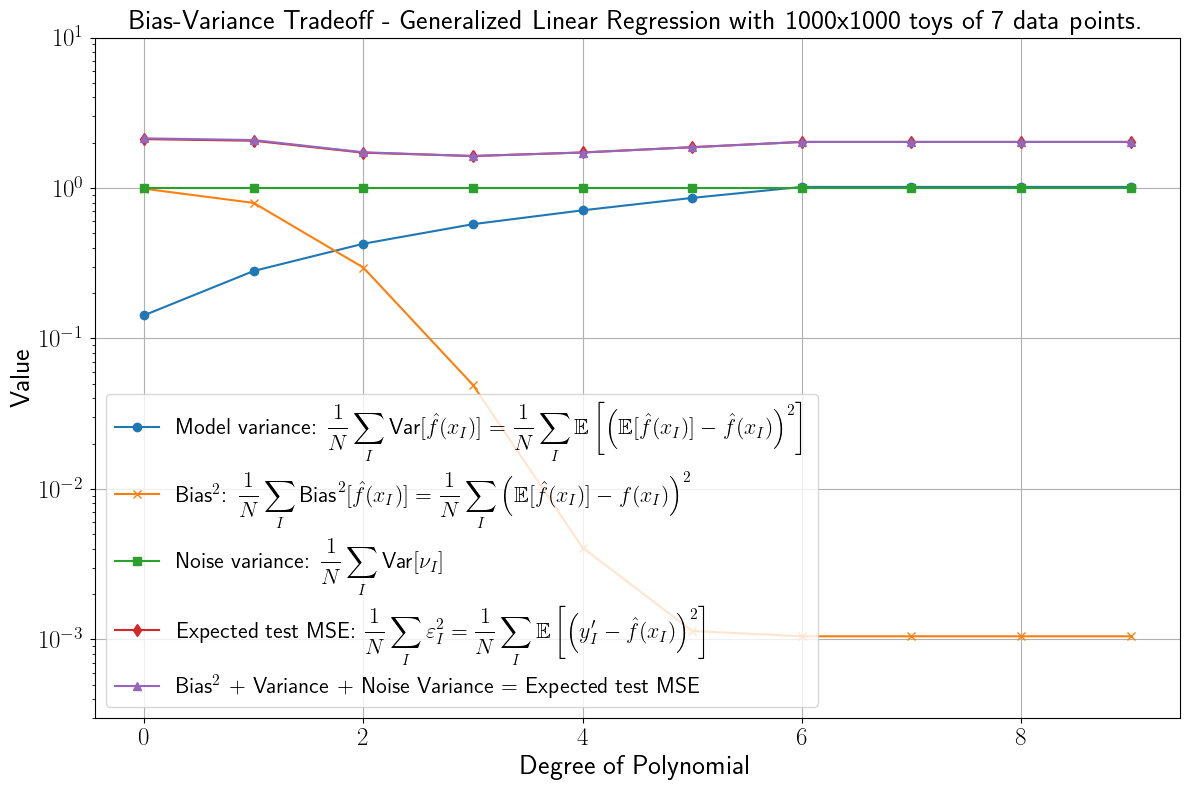

In [467]:
plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r"""\usepackage{amsmath}
\usepackage{amsfonts}
\usepackage{amssymb}
\usepackage{bm}"""

# Plot the various quantities vs the degree of the polynomial
degrees, variances, biases, noise_variances, sums, mse_mc = zip(*result)
plt.figure(figsize=(12, 8))

plt.plot(degrees, variances, label=r'Model variance: $\displaystyle\frac{1}{N} \sum_{I}\text{Var}[\hat{f}(x_{I})] = \frac{1}{N} \sum_{I}\mathbb{E}\left[\left(\mathbb{E}[\hat{f}(x_{I})] - \hat{f}(x_{I})\right)^{2}\right]$', marker='o')
plt.plot(degrees, biases, label=r'Bias$^2$: $\displaystyle\frac{1}{N} \sum_{I}\text{Bias}^{2}[\hat{f}(x_{I})] = \frac{1}{N} \sum_{I}\left(\mathbb{E}[\hat{f}(x_{I})] - f(x_{I})\right)^{2}$', marker='x')
plt.plot(degrees, noise_variances, label=r'Noise variance: $\displaystyle\frac{1}{N} \sum_{I}\text{Var}[\nu_{I}]$', marker='s')
plt.plot(degrees, mse_mc, label=r'Expected test MSE: $\displaystyle\frac{1}{N} \sum_{I}\varepsilon_{I}^{2} = \frac{1}{N} \sum_{I}\mathbb{E}\left[\left(y_{I}^{\prime} - \hat{f}(x_{I})\right)^{2}\right]$', marker='d')
plt.plot(degrees, sums, label=r'Bias$^2$ + Variance + Noise Variance = Expected test MSE', marker='^')

plt.tick_params(axis='both', which='major', labelsize=18)
plt.xlabel('Degree of Polynomial', fontsize = 20)
plt.ylabel('Value', fontsize = 20)
plt.title('Bias-Variance Tradeoff - Generalized Linear Regression with '+ str(len(train_MC))+ 'x'+str(len(train_MC))+ ' toys of '+ str(len(x_values))+' data points.', fontsize = 20)
plt.legend(loc='lower left', fontsize = 16)
plt.grid(True)
plt.yscale('log')
plt.ylim(3e-4, 10)
plt.tight_layout()
plt.savefig(f'/Users/rtorre/Dropbox/Apps/Overleaf/ML Methods for Physics/Figures/Chapter_3/variance_bias_tradeoff_2.pdf')
plt.show()

### Probabilistic model with non-polynomial fit (non-polynomial data)

In [469]:
def y(x: np.ndarray) -> np.ndarray:
    """Generates polynomial data based on a given polynomial expression.
    
    Args:
        x: A numpy array of x values.
    
    Returns:
        A numpy array of y values computed from the polynomial expression.
    """
    return 3 + np.sin(x) - np.cos(x)

def y_stat(x: np.ndarray,
           std: float = 0.1
          ) -> np.ndarray:
    """Generates noisy polynomial data by adding Gaussian noise to the true y values.
    
    Args:
        x: A numpy array of x values.
    
    Returns:
        A numpy array of y values computed from the polynomial expression with added Gaussian noise.
    """
    # Generate true y values based on a polynomial expression
    true_y_values: np.ndarray = y(x)
    
    # Add Gaussian noise with a mean of 0 and standard deviation of 1 to the true y values
    noisy_y_values: np.ndarray = np.random.normal(true_y_values, std)
    
    return noisy_y_values

def design_matrix_trig(x_values: np.ndarray) -> np.ndarray:
    """Generates a design matrix for trigonometric regression.
    
    Args:
        x_values: A numpy array of x values.
    
    Returns:
        A design matrix as a numpy array with columns for 1, sin(x), and cos(x).
    """
    # The design matrix includes columns for the constant term, sin(x), and cos(x)
    return np.column_stack((np.ones_like(x_values), np.sin(x_values), np.cos(x_values)))

def omega_solution(X: np.ndarray, 
                   Y: np.ndarray
                  ) -> np.ndarray:
    """Calculates the coefficients (omega) that best fit the data for a given design matrix.
    
    Args:
        X: The design matrix.
        Y: A numpy array of target y values.
    
    Returns:
        A numpy array of calculated omega values.
    """
    return np.linalg.pinv(X.T @ X) @ X.T @ Y

def trig_solution(omega_solution: np.ndarray, 
                  x_values: np.ndarray
                 ) -> np.ndarray:
    """Evaluates the trigonometric model at given x values using the omega coefficients.
    
    Args:
        omega_solution: A numpy array of omega coefficients for [constant, sin(x), cos(x)].
        x_values: A numpy array of x values for evaluation.
    
    Returns:
        A numpy array of y values predicted by the trigonometric model.
    """
    return omega_solution[0] + omega_solution[1] * np.sin(x_values) + omega_solution[2] * np.cos(x_values)


In [470]:
def fit(data: np.ndarray,
        x: np.ndarray
       ) -> np.ndarray:
    """Fits a polynomial of trigonometric functions and computes the polynomial at the x values.
    
    Args:
        data: A numpy array of data points.
        x: A numpy array of x values.
        
    Returns:
        The fitted polynomial computed at the x values.
    """
    result: list = []
    for dat in data:
        X = design_matrix_trig(dat[:, 0])
        Y = dat[:, 1]
        omega = omega_solution(X, Y)
        val = trig_solution(omega, x)
        result.append(val)
    return np.array(result)

In [471]:
def generate_data(x: np.ndarray,
                  std: float = 0.1,
                  n: int = 1
                 ) -> np.ndarray:
    """Generates Monte Carlo data for a given set of x values, noise level, and number of samples.
    
    Args:
        x: A numpy array of x values.
    
    Returns:
        A numpy array of y values generated from the statistical model.
    """
    data = np.array([np.concatenate((x.reshape(-1, 1), y_stat(x, std).reshape(-1, 1)), axis=1) for _ in range(n)])
    return data

# Generate data coordinates
step = 1
x_values: np.ndarray = np.arange(-3, 3+step, step)

np.random.seed(100)
train_data = generate_data(x_values, 1, 1)
test_data = generate_data(x_values, 1, 1)
train_MC = generate_data(x_values, 1, 1000)
test_MC = generate_data(x_values, 1, 1000)

In [472]:
def Ef(x: np.ndarray
      ) -> np.ndarray:
    """
    Computes the expected value of the polynomial fit over multiple Monte Carlo samples.
    
    Args:
        x: A numpy array of x values.
        
    Returns:
        The expected value of the polynomial fit at the x values.
    """
    fit_vals = fit(train_MC, x)
    return np.mean(fit_vals, axis=0)

def Varf(x: np.ndarray
        ) -> np.ndarray:
        """Computes the variance of the polynomial fit over multiple Monte Carlo samples.
        
        Args:
            x: A numpy array of x values.
            
        Returns:
            The variance of the polynomial fit at the x values.
        """
        fit_vals = fit(train_MC, x)
        return np.mean(np.var(fit_vals, axis=0))
    
def Bias2f(x: np.ndarray
          ) -> np.ndarray:
     """Computes the squared bias of the polynomial fit over multiple Monte Carlo samples.
     
     Args:
          x: A numpy array of x values.
          
     Returns:
          The squared bias of the polynomial fit at the x values.
     """
     Ef_vals = Ef(x)
     return np.mean((Ef_vals - y(x))**2)
 
def Noise_variance(x: np.ndarray) -> float:
    """Computes the noise variance of the data.
    
    Args:
        data: A numpy array of data points.
        
    Returns:
        The noise variance for a given data point x
    """
    lst: list = []
    for i in range(test_MC.shape[1]):
        lst.append(np.mean((y(test_MC[:, i, 0])-test_MC[:, i, 1])**2))
    return np.mean(lst)        

def MSE_MC() -> np.ndarray:
    """Computes the mean squared error of the polynomial fit over multiple Monte Carlo samples.
    
    Args:
        d: The degree of the polynomial to fit.
        x: A numpy array of x values.
        
    Returns:
        The mean squared error of the polynomial fit at the x values.
    """
    #print("Train MC data:", train_MC)
    #print("Test MC data:", test_MC)
    x_test = test_MC[:, :, 0]
    #print("Test x values:", x_test)
    y_test = test_MC[:, :, 1]
    #print("Test y values:", y_test)
    y_train_pred = fit(train_MC, x_test)
    #print("Predicted y values from multiple trainings:", y_train_pred)
    #print("Difference between predicted and true y values:", y_train_pred - y_test)
    #print("Mean squared error over train data for each test data:", np.mean((y_test - y_train_pred)**2, axis=0))
    #print("Mean squared error over train and test data:", np.mean(np.mean((y_test - y_train_pred)**2, axis=0), axis=0))
    #print("Mean squared error over train and test data and over data points:", np.mean(np.mean(np.mean((y_test - y_train_pred)**2, axis=1), axis=0)))
    return np.mean((y_test - y_train_pred)**2)

In [473]:
Ef(x_values)

array([3.84835367, 2.5157108 , 1.62149407, 1.98784221, 3.27793643,
       4.30567006, 4.12614954])

In [474]:
Varf(x_values)

In [475]:
Bias2f(x_values)

In [476]:
Noise_variance(x_val)

In [477]:
MSE_MC()

In [478]:
Varf_val = Varf(x_values)
Bias2f_val = Bias2f(x_values)
Noise_variance_val = Noise_variance(x_values)
sum_val = Bias2f_val + Varf_val + Noise_variance_val
MSE_MC_val = MSE_MC()
print(Varf_val, Bias2f_val, Noise_variance_val, sum_val, MSE_MC_val)

0.43146923314431573 0.00017038124360916292 1.006137500361673 1.437777114749598 1.4377881212881205


### Probabilistic model (polynomial data) - Large sample small variance

In [479]:
def y(x: np.ndarray) -> np.ndarray:
    """Generates polynomial data based on a given polynomial expression.
    
    Args:
        x: A numpy array of x values.
    
    Returns:
        A numpy array of y values computed from the polynomial expression.
    """
    return -x**4/24 - x**3/6 + x**2/2 + x + 2

def y_stat(x: np.ndarray,
           std: float = 0.1
          ) -> np.ndarray:
    """Generates noisy polynomial data by adding Gaussian noise to the true y values.
    
    Args:
        x: A numpy array of x values.
    
    Returns:
        A numpy array of y values computed from the polynomial expression with added Gaussian noise.
    """
    # Generate true y values based on a polynomial expression
    true_y_values: np.ndarray = y(x)
    
    # Add Gaussian noise with a mean of 0 and standard deviation of 1 to the true y values
    noisy_y_values: np.ndarray = np.random.normal(true_y_values, std)
    
    return noisy_y_values

def design_matrix(degree: int, 
                  x_values: np.ndarray
                 ) -> np.ndarray:
    """Generates a design matrix for polynomial regression of a specified degree.
    
    Args:
        degree: The degree of the polynomial hypothesis.
        x_values: A numpy array of x values.
    
    Returns:
        A design matrix as a numpy array.
    """
    return np.array([[x**i for i in range(degree+1)] for x in x_values])

def omega_solution(X: np.ndarray, 
                   Y: np.ndarray
                  ) -> np.ndarray:
    """Calculates the polynomial coefficients (omega) that best fit the data.
    
    Args:
        X: The design matrix.
        Y: A numpy array of target y values.
    
    Returns:
        A numpy array of calculated omega values.
    """
    return np.linalg.pinv(X.T @ X) @ X.T @ Y

def poly_solution(omega_solution: np.ndarray) -> Polynomial:
    """Converts omega coefficients to a numpy Polynomial object.
    
    Args:
        omega_solution: A numpy array of omega coefficients.
    
    Returns:
        A numpy Polynomial object representing the fitted polynomial.
    """
    return Polynomial(omega_solution)

In [480]:
def generate_data(x: np.ndarray,
                  std: float = 0.1,
                  n: int = 1
                 ) -> np.ndarray:
    """Generates Monte Carlo data for a given set of x values, noise level, and number of samples.
    
    Args:
        x: A numpy array of x values.
    
    Returns:
        A numpy array of y values generated from the statistical model.
    """
    data = np.array([np.concatenate((x.reshape(-1, 1), y_stat(x, std).reshape(-1, 1)), axis=1) for _ in range(n)])
    return data

# Generate data coordinates
step = 0.1
x_values: np.ndarray = np.arange(-3, 3+step, step)

np.random.seed(100)
train_data = generate_data(x_values, 0.1, 1)
test_data = generate_data(x_values, 0.1, 1)
train_MC = generate_data(x_values, 0.1, 1000)
test_MC = generate_data(x_values, 0.1, 1000)

In [481]:
def fit(data: np.ndarray,
        d: int,
        x: np.ndarray
       ) -> np.ndarray:
    """Fits a polynomial of degree d to the given data and computes the polynomial at the x values.
    
    Args:
        data: A numpy array of data points.
        d: The degree of the polynomial to fit.
        x: A numpy array of x values.
        
    Returns:
        The fitted polynomial computed at the x values.
    """
    result: list = []
    for dat in data:
        X = design_matrix(d, dat[:, 0])
        Y = dat[:, 1]
        omega = omega_solution(X, Y)
        poly = poly_solution(omega)
        val = poly(x)
        result.append(val)
    return np.array(result)

In [482]:
fit(train_data, 3, x_values)

array([[5.2927403 , 4.86631204, 4.47154085, 4.10744969, 3.77306151,
        3.4673993 , 3.189486  , 2.9383446 , 2.71299804, 2.51246931,
        2.33578136, 2.18195716, 2.05001967, 1.93899187, 1.84789671,
        1.77575716, 1.72159619, 1.68443677, 1.66330185, 1.6572144 ,
        1.66519739, 1.68627379, 1.71946656, 1.76379866, 1.81829306,
        1.88197273, 1.95386063, 2.03297973, 2.11835299, 2.20900338,
        2.30395386, 2.4022274 , 2.50284696, 2.60483552, 2.70721603,
        2.80901146, 2.90924478, 3.00693895, 3.10111693, 3.1908017 ,
        3.27501622, 3.35278345, 3.42312636, 3.48506792, 3.53763108,
        3.57983882, 3.6107141 , 3.62927989, 3.63455915, 3.62557485,
        3.60134995, 3.56090742, 3.50327022, 3.42746132, 3.33250369,
        3.21742028, 3.08123407, 2.92296803, 2.74164511, 2.53628828,
        2.30592051]])

In [483]:
fit(train_MC, 3, x_values)

array([[5.24337674, 4.81840212, 4.42520953, ..., 2.75302929, 2.54404532,
        2.30974277],
       [5.32519286, 4.89655519, 4.49978164, ..., 2.75075518, 2.5424771 ,
        2.30894878],
       [5.3572204 , 4.92682796, 4.52823328, ..., 2.85230475, 2.65347616,
        2.42985915],
       ...,
       [5.35991081, 4.9211883 , 4.51504292, ..., 2.81591843, 2.60873621,
        2.37595801],
       [5.30062621, 4.8681532 , 4.46794541, ..., 2.79133965, 2.58237837,
        2.34786227],
       [5.26797075, 4.84086064, 4.44546835, ..., 2.80146134, 2.60021594,
        2.37406488]], shape=(1000, 61))

In [484]:
np.mean(fit(train_MC, 3, x_values), axis=0)

array([5.3229215 , 4.88831139, 4.48608413, 4.11523906, 3.77477549,
       3.46369278, 3.18099025, 2.92566724, 2.69672309, 2.49315713,
       2.31396869, 2.15815711, 2.02472173, 1.91266188, 1.8209769 ,
       1.74866612, 1.69472887, 1.65816449, 1.63797232, 1.63315169,
       1.64270194, 1.66562239, 1.7009124 , 1.74757128, 1.80459838,
       1.87099304, 1.94575458, 2.02788234, 2.11637565, 2.21023386,
       2.3084563 , 2.4100423 , 2.51399119, 2.61930232, 2.72497501,
       2.83000861, 2.93340244, 3.03415585, 3.13126816, 3.22373871,
       3.31056685, 3.39075189, 3.46329318, 3.52719006, 3.58144185,
       3.6250479 , 3.65700753, 3.67632009, 3.6819849 , 3.67300131,
       3.64836864, 3.60708624, 3.54815344, 3.47056957, 3.37333397,
       3.25544597, 3.11590491, 2.95371012, 2.76786094, 2.55735671,
       2.32119675])

In [485]:
def Ef(d: int,
       x: np.ndarray
      ) -> np.ndarray:
    """
    Computes the expected value of the polynomial fit over multiple Monte Carlo samples.
    
    Args:
        d: The degree of the polynomial to fit.
        x: A numpy array of x values.
        
    Returns:
        The expected value of the polynomial fit at the x values.
    """
    fit_vals = fit(train_MC, d, x)
    return np.mean(fit_vals, axis=0)

def Varf(d: int,
         x: np.ndarray
        ) -> np.ndarray:
        """Computes the variance of the polynomial fit over multiple Monte Carlo samples.
        
        Args:
            d: The degree of the polynomial to fit.
            x: A numpy array of x values.
            
        Returns:
            The variance of the polynomial fit at the x values.
        """
        fit_vals = fit(train_MC, d, x)
        return np.mean(np.var(fit_vals, axis=0))
    
def Bias2f(d: int,
           x: np.ndarray
          ) -> np.ndarray:
     """Computes the squared bias of the polynomial fit over multiple Monte Carlo samples.
     
     Args:
          d: The degree of the polynomial to fit.
          x: A numpy array of x values.
          
     Returns:
          The squared bias of the polynomial fit at the x values.
     """
     Ef_vals = Ef(d, x)
     return np.mean((Ef_vals - y(x))**2)
 
def Noise_variance(x: np.ndarray) -> float:
    """Computes the noise variance of the data.
    
    Args:
        data: A numpy array of data points.
        
    Returns:
        The noise variance for a given data point x
    """
    lst: list = []
    for i in range(test_MC.shape[1]):
        lst.append(np.mean((y(test_MC[:, i, 0])-test_MC[:, i, 1])**2))
    return np.mean(lst)        

def MSE_MC(d: int,
          ) -> np.ndarray:
    """Computes the mean squared error of the polynomial fit over multiple Monte Carlo samples.
    
    Args:
        d: The degree of the polynomial to fit.
        x: A numpy array of x values.
        
    Returns:
        The mean squared error of the polynomial fit at the x values.
    """
    #print("Train MC data:", train_MC)
    #print("Test MC data:", test_MC)
    x_test = test_MC[:, :, 0]
    #print("Test x values:", x_test)
    y_test = test_MC[:, :, 1]
    #print("Test y values:", y_test)
    y_train_pred = fit(train_MC, d, x_test)
    #print("Predicted y values from multiple trainings:", y_train_pred)
    #print("Difference between predicted and true y values:", y_train_pred - y_test)
    #print("Mean squared error over train data for each test data:", np.mean((y_test - y_train_pred)**2, axis=0))
    #print("Mean squared error over train and test data:", np.mean(np.mean((y_test - y_train_pred)**2, axis=0), axis=0))
    #print("Mean squared error over train and test data and over data points:", np.mean(np.mean(np.mean((y_test - y_train_pred)**2, axis=1), axis=0)))
    return np.mean((y_test - y_train_pred)**2)

In [486]:
Ef(3, x_values)

array([5.3229215 , 4.88831139, 4.48608413, 4.11523906, 3.77477549,
       3.46369278, 3.18099025, 2.92566724, 2.69672309, 2.49315713,
       2.31396869, 2.15815711, 2.02472173, 1.91266188, 1.8209769 ,
       1.74866612, 1.69472887, 1.65816449, 1.63797232, 1.63315169,
       1.64270194, 1.66562239, 1.7009124 , 1.74757128, 1.80459838,
       1.87099304, 1.94575458, 2.02788234, 2.11637565, 2.21023386,
       2.3084563 , 2.4100423 , 2.51399119, 2.61930232, 2.72497501,
       2.83000861, 2.93340244, 3.03415585, 3.13126816, 3.22373871,
       3.31056685, 3.39075189, 3.46329318, 3.52719006, 3.58144185,
       3.6250479 , 3.65700753, 3.67632009, 3.6819849 , 3.67300131,
       3.64836864, 3.60708624, 3.54815344, 3.47056957, 3.37333397,
       3.25544597, 3.11590491, 2.95371012, 2.76786094, 2.55735671,
       2.32119675])

In [487]:
Varf(3, x_values)

In [488]:
Bias2f(3, x_values)

In [489]:
Noise_variance(x_val)

In [490]:
MSE_MC(3)

In [491]:
result: list = []
for d in range(20):
    #Ef_val = Ef(d, x_values)
    Varf_val = Varf(d, x_values)
    Bias2f_val = Bias2f(d, x_values)
    Noise_variance_val = Noise_variance(x_values)
    sum_val = Bias2f_val + Varf_val + Noise_variance_val
    MSE_MC_val = MSE_MC(d)
    result.append((d, Varf_val, Bias2f_val, Noise_variance_val, sum_val, MSE_MC_val))


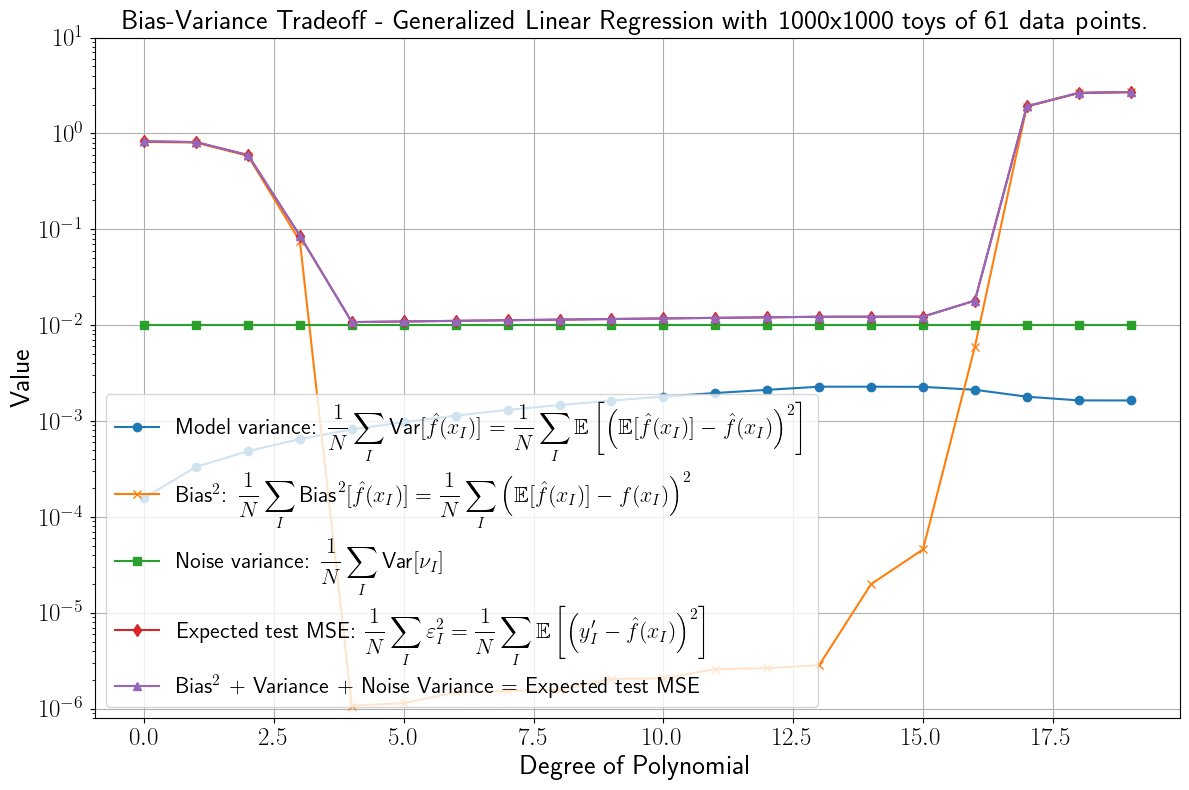

In [493]:
plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r"""\usepackage{amsmath}
\usepackage{amsfonts}
\usepackage{amssymb}
\usepackage{bm}"""

# Plot the various quantities vs the degree of the polynomial
degrees, variances, biases, noise_variances, sums, mse_mc = zip(*result)
plt.figure(figsize=(12, 8))

plt.plot(degrees, variances, label=r'Model variance: $\displaystyle\frac{1}{N} \sum_{I}\text{Var}[\hat{f}(x_{I})] = \frac{1}{N} \sum_{I}\mathbb{E}\left[\left(\mathbb{E}[\hat{f}(x_{I})] - \hat{f}(x_{I})\right)^{2}\right]$', marker='o')
plt.plot(degrees, biases, label=r'Bias$^2$: $\displaystyle\frac{1}{N} \sum_{I}\text{Bias}^{2}[\hat{f}(x_{I})] = \frac{1}{N} \sum_{I}\left(\mathbb{E}[\hat{f}(x_{I})] - f(x_{I})\right)^{2}$', marker='x')
plt.plot(degrees, noise_variances, label=r'Noise variance: $\displaystyle\frac{1}{N} \sum_{I}\text{Var}[\nu_{I}]$', marker='s')
plt.plot(degrees, mse_mc, label=r'Expected test MSE: $\displaystyle\frac{1}{N} \sum_{I}\varepsilon_{I}^{2} = \frac{1}{N} \sum_{I}\mathbb{E}\left[\left(y_{I}^{\prime} - \hat{f}(x_{I})\right)^{2}\right]$', marker='d')
plt.plot(degrees, sums, label=r'Bias$^2$ + Variance + Noise Variance = Expected test MSE', marker='^')

plt.tick_params(axis='both', which='major', labelsize=18)
plt.xlabel('Degree of Polynomial', fontsize = 20)
plt.ylabel('Value', fontsize = 20)
plt.title('Bias-Variance Tradeoff - Generalized Linear Regression with '+ str(len(train_MC))+ 'x'+str(len(train_MC))+ ' toys of '+ str(len(x_values))+' data points.', fontsize = 20)
plt.legend(loc='lower left', fontsize = 16)
plt.grid(True)
plt.yscale('log')
plt.ylim(8e-7, 10)
plt.tight_layout()
plt.savefig(f'/Users/rtorre/Dropbox/Apps/Overleaf/ML Methods for Physics/Figures/Chapter_3/variance_bias_tradeoff_3.pdf')
plt.show()

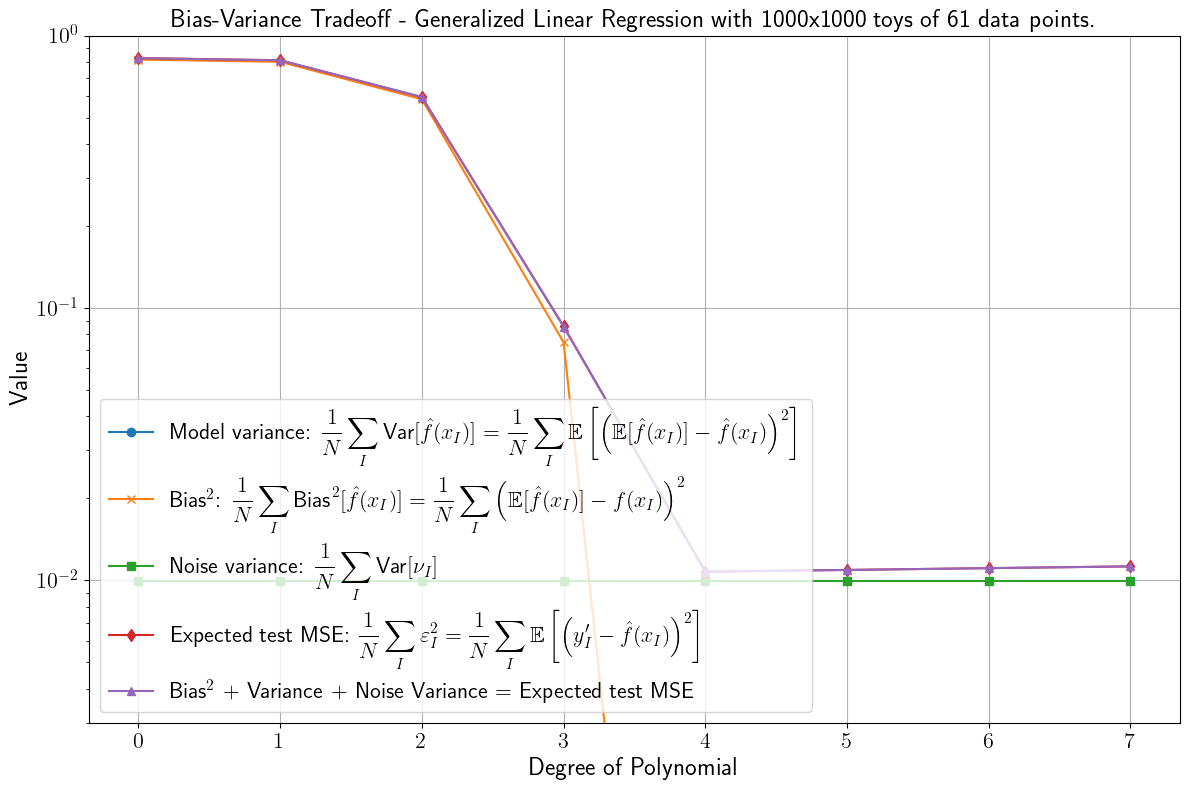

In [494]:
plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r"""\usepackage{amsmath}
\usepackage{amsfonts}
\usepackage{amssymb}
\usepackage{bm}"""

# Plot the various quantities vs the degree of the polynomial
degrees, variances, biases, noise_variances, sums, mse_mc = zip(*result[:8])
plt.figure(figsize=(12, 8))

plt.plot(degrees, variances, label=r'Model variance: $\displaystyle\frac{1}{N} \sum_{I}\text{Var}[\hat{f}(x_{I})] = \frac{1}{N} \sum_{I}\mathbb{E}\left[\left(\mathbb{E}[\hat{f}(x_{I})] - \hat{f}(x_{I})\right)^{2}\right]$', marker='o')
plt.plot(degrees, biases, label=r'Bias$^2$: $\displaystyle\frac{1}{N} \sum_{I}\text{Bias}^{2}[\hat{f}(x_{I})] = \frac{1}{N} \sum_{I}\left(\mathbb{E}[\hat{f}(x_{I})] - f(x_{I})\right)^{2}$', marker='x')
plt.plot(degrees, noise_variances, label=r'Noise variance: $\displaystyle\frac{1}{N} \sum_{I}\text{Var}[\nu_{I}]$', marker='s')
plt.plot(degrees, mse_mc, label=r'Expected test MSE: $\displaystyle\frac{1}{N} \sum_{I}\varepsilon_{I}^{2} = \frac{1}{N} \sum_{I}\mathbb{E}\left[\left(y_{I}^{\prime} - \hat{f}(x_{I})\right)^{2}\right]$', marker='d')
plt.plot(degrees, sums, label=r'Bias$^2$ + Variance + Noise Variance = Expected test MSE', marker='^')

plt.tick_params(axis='both', which='major', labelsize=16)
plt.xlabel('Degree of Polynomial', fontsize = 18)
plt.ylabel('Value', fontsize = 18)
plt.title('Bias-Variance Tradeoff - Generalized Linear Regression with '+ str(len(train_MC))+ 'x'+str(len(train_MC))+ ' toys of '+ str(len(x_values))+' data points.', fontsize = 18)
plt.legend(loc='lower left', fontsize = 16)
plt.grid(True)
plt.yscale('log')
plt.ylim(3e-3, 1)
plt.tight_layout()
plt.show()

### Probabilistic model (non-polynomial data) - Large sample small variance

In [495]:
def y(x: np.ndarray) -> np.ndarray:
    """Generates polynomial data based on a given polynomial expression.
    
    Args:
        x: A numpy array of x values.
    
    Returns:
        A numpy array of y values computed from the polynomial expression.
    """
    return 3 + np.sin(x) - np.cos(x)

def y_stat(x: np.ndarray,
           std: float = 0.1
          ) -> np.ndarray:
    """Generates noisy polynomial data by adding Gaussian noise to the true y values.
    
    Args:
        x: A numpy array of x values.
    
    Returns:
        A numpy array of y values computed from the polynomial expression with added Gaussian noise.
    """
    # Generate true y values based on a polynomial expression
    true_y_values: np.ndarray = y(x)
    
    # Add Gaussian noise with a mean of 0 and standard deviation of 1 to the true y values
    noisy_y_values: np.ndarray = np.random.normal(true_y_values, std)
    
    return noisy_y_values

In [496]:
def generate_data(x: np.ndarray,
                  std: float = 0.1,
                  n: int = 1
                 ) -> np.ndarray:
    """Generates Monte Carlo data for a given set of x values, noise level, and number of samples.
    
    Args:
        x: A numpy array of x values.
    
    Returns:
        A numpy array of y values generated from the statistical model.
    """
    data = np.array([np.concatenate((x.reshape(-1, 1), y_stat(x, std).reshape(-1, 1)), axis=1) for _ in range(n)])
    return data

# Generate data coordinates
step = 0.1
x_values: np.ndarray = np.arange(-3, 3+step, step)

np.random.seed(100)
train_data = generate_data(x_values, 0.1, 1)
test_data = generate_data(x_values, 0.1, 1)
train_MC = generate_data(x_values, 0.1, 1000)
test_MC = generate_data(x_values, 0.1, 1000)

In [497]:
def Ef(d: int,
       x: np.ndarray
      ) -> np.ndarray:
    """
    Computes the expected value of the polynomial fit over multiple Monte Carlo samples.
    
    Args:
        d: The degree of the polynomial to fit.
        x: A numpy array of x values.
        
    Returns:
        The expected value of the polynomial fit at the x values.
    """
    fit_vals = fit(train_MC, d, x)
    return np.mean(fit_vals, axis=0)

def Varf(d: int,
         x: np.ndarray
        ) -> np.ndarray:
        """Computes the variance of the polynomial fit over multiple Monte Carlo samples.
        
        Args:
            d: The degree of the polynomial to fit.
            x: A numpy array of x values.
            
        Returns:
            The variance of the polynomial fit at the x values.
        """
        fit_vals = fit(train_MC, d, x)
        return np.mean(np.var(fit_vals, axis=0))
    
def Bias2f(d: int,
           x: np.ndarray
          ) -> np.ndarray:
     """Computes the squared bias of the polynomial fit over multiple Monte Carlo samples.
     
     Args:
          d: The degree of the polynomial to fit.
          x: A numpy array of x values.
          
     Returns:
          The squared bias of the polynomial fit at the x values.
     """
     Ef_vals = Ef(d, x)
     return np.mean((Ef_vals - y(x))**2)
 
def Noise_variance(x: np.ndarray) -> float:
    """Computes the noise variance of the data.
    
    Args:
        data: A numpy array of data points.
        
    Returns:
        The noise variance for a given data point x
    """
    lst: list = []
    for i in range(test_MC.shape[1]):
        lst.append(np.mean((y(test_MC[:, i, 0])-test_MC[:, i, 1])**2))
    return np.mean(lst)        

def MSE_MC(d: int,
          ) -> np.ndarray:
    """Computes the mean squared error of the polynomial fit over multiple Monte Carlo samples.
    
    Args:
        d: The degree of the polynomial to fit.
        x: A numpy array of x values.
        
    Returns:
        The mean squared error of the polynomial fit at the x values.
    """
    #print("Train MC data:", train_MC)
    #print("Test MC data:", test_MC)
    x_test = test_MC[:, :, 0]
    #print("Test x values:", x_test)
    y_test = test_MC[:, :, 1]
    #print("Test y values:", y_test)
    y_train_pred = fit(train_MC, d, x_test)
    #print("Predicted y values from multiple trainings:", y_train_pred)
    #print("Difference between predicted and true y values:", y_train_pred - y_test)
    #print("Mean squared error over train data for each test data:", np.mean((y_test - y_train_pred)**2, axis=0))
    #print("Mean squared error over train and test data:", np.mean(np.mean((y_test - y_train_pred)**2, axis=0), axis=0))
    #print("Mean squared error over train and test data and over data points:", np.mean(np.mean(np.mean((y_test - y_train_pred)**2, axis=1), axis=0)))
    return np.mean((y_test - y_train_pred)**2)

In [498]:
Ef(3, x_values)

array([4.40443535, 4.09527674, 3.80784124, 3.5415472 , 3.29581296,
       3.07005689, 2.86369732, 2.67615261, 2.50684112, 2.35518118,
       2.22059116, 2.1024894 , 2.00029425, 1.91342407, 1.8412972 ,
       1.78333199, 1.7389468 , 1.70755998, 1.68858986, 1.68145482,
       1.68557319, 1.70036333, 1.72524359, 1.75963232, 1.80294786,
       1.85460857, 1.91403281, 1.98063891, 2.05384524, 2.13307013,
       2.21773195, 2.30724904, 2.40103975, 2.49852244, 2.59911544,
       2.70223713, 2.80730584, 2.91373992, 3.02095773, 3.12837761,
       3.23541793, 3.34149702, 3.44603323, 3.54844493, 3.64815045,
       3.74456816, 3.83711639, 3.9252135 , 4.00827785, 4.08572777,
       4.15698163, 4.22145777, 4.27857454, 4.3277503 , 4.36840338,
       4.39995216, 4.42181497, 4.43341016, 4.43415609, 4.4234711 ,
       4.40077356])

In [499]:
Varf(3, x_values)

In [500]:
Bias2f(3, x_values)

In [501]:
Noise_variance(x_val)

In [502]:
MSE_MC(3)

In [503]:
result: list = []
for d in range(20):
    #Ef_val = Ef(d, x_values)
    Varf_val = Varf(d, x_values)
    Bias2f_val = Bias2f(d, x_values)
    Noise_variance_val = Noise_variance(x_values)
    sum_val = Bias2f_val + Varf_val + Noise_variance_val
    MSE_MC_val = MSE_MC(d)
    result.append((d, Varf_val, Bias2f_val, Noise_variance_val, sum_val, MSE_MC_val))


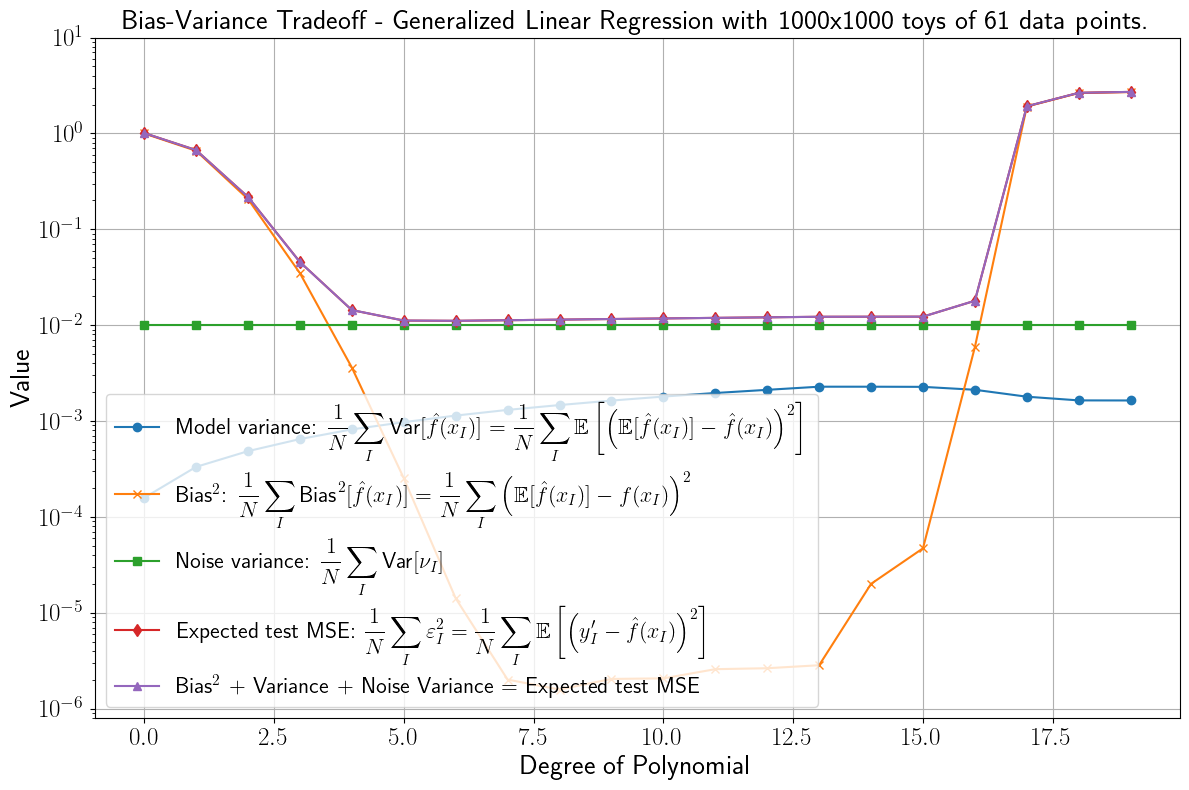

In [504]:
plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r"""\usepackage{amsmath}
\usepackage{amsfonts}
\usepackage{amssymb}
\usepackage{bm}"""

# Plot the various quantities vs the degree of the polynomial
degrees, variances, biases, noise_variances, sums, mse_mc = zip(*result)
plt.figure(figsize=(12, 8))

plt.plot(degrees, variances, label=r'Model variance: $\displaystyle\frac{1}{N} \sum_{I}\text{Var}[\hat{f}(x_{I})] = \frac{1}{N} \sum_{I}\mathbb{E}\left[\left(\mathbb{E}[\hat{f}(x_{I})] - \hat{f}(x_{I})\right)^{2}\right]$', marker='o')
plt.plot(degrees, biases, label=r'Bias$^2$: $\displaystyle\frac{1}{N} \sum_{I}\text{Bias}^{2}[\hat{f}(x_{I})] = \frac{1}{N} \sum_{I}\left(\mathbb{E}[\hat{f}(x_{I})] - f(x_{I})\right)^{2}$', marker='x')
plt.plot(degrees, noise_variances, label=r'Noise variance: $\displaystyle\frac{1}{N} \sum_{I}\text{Var}[\nu_{I}]$', marker='s')
plt.plot(degrees, mse_mc, label=r'Expected test MSE: $\displaystyle\frac{1}{N} \sum_{I}\varepsilon_{I}^{2} = \frac{1}{N} \sum_{I}\mathbb{E}\left[\left(y_{I}^{\prime} - \hat{f}(x_{I})\right)^{2}\right]$', marker='d')
plt.plot(degrees, sums, label=r'Bias$^2$ + Variance + Noise Variance = Expected test MSE', marker='^')

plt.tick_params(axis='both', which='major', labelsize=18)
plt.xlabel('Degree of Polynomial', fontsize = 20)
plt.ylabel('Value', fontsize = 20)
plt.title('Bias-Variance Tradeoff - Generalized Linear Regression with '+ str(len(train_MC))+ 'x'+str(len(train_MC))+ ' toys of '+ str(len(x_values))+' data points.', fontsize = 20)
plt.legend(loc='lower left', fontsize = 16)
plt.grid(True)
plt.yscale('log')
plt.ylim(8e-7, 10)
plt.tight_layout()
plt.savefig(f'/Users/rtorre/Dropbox/Apps/Overleaf/ML Methods for Physics/Figures/Chapter_3/variance_bias_tradeoff_4.pdf')
plt.show()

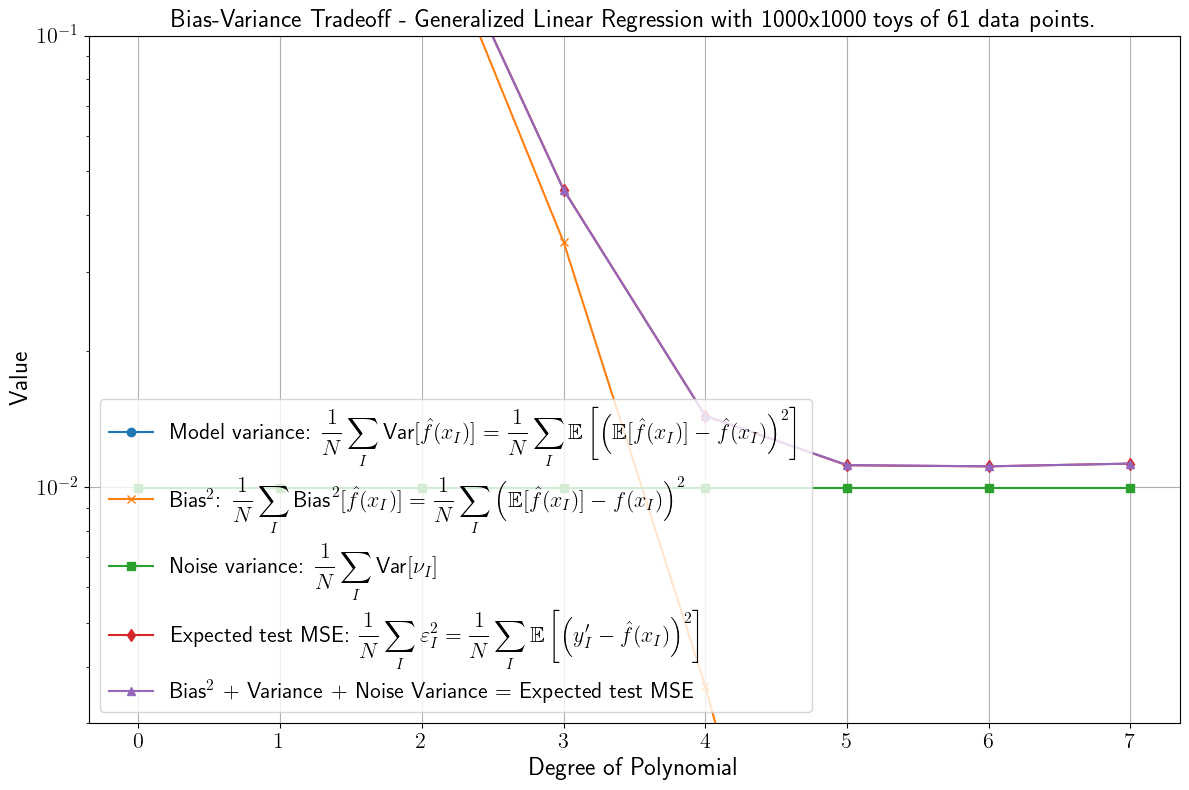

In [417]:
plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r"""\usepackage{amsmath}
\usepackage{amsfonts}
\usepackage{amssymb}
\usepackage{bm}"""

# Plot the various quantities vs the degree of the polynomial
degrees, variances, biases, noise_variances, sums, mse_mc = zip(*result[:8])
plt.figure(figsize=(12, 8))

plt.plot(degrees, variances, label=r'Model variance: $\displaystyle\frac{1}{N} \sum_{I}\text{Var}[\hat{f}(x_{I})] = \frac{1}{N} \sum_{I}\mathbb{E}\left[\left(\mathbb{E}[\hat{f}(x_{I})] - \hat{f}(x_{I})\right)^{2}\right]$', marker='o')
plt.plot(degrees, biases, label=r'Bias$^2$: $\displaystyle\frac{1}{N} \sum_{I}\text{Bias}^{2}[\hat{f}(x_{I})] = \frac{1}{N} \sum_{I}\left(\mathbb{E}[\hat{f}(x_{I})] - f(x_{I})\right)^{2}$', marker='x')
plt.plot(degrees, noise_variances, label=r'Noise variance: $\displaystyle\frac{1}{N} \sum_{I}\text{Var}[\nu_{I}]$', marker='s')
plt.plot(degrees, mse_mc, label=r'Expected test MSE: $\displaystyle\frac{1}{N} \sum_{I}\varepsilon_{I}^{2} = \frac{1}{N} \sum_{I}\mathbb{E}\left[\left(y_{I}^{\prime} - \hat{f}(x_{I})\right)^{2}\right]$', marker='d')
plt.plot(degrees, sums, label=r'Bias$^2$ + Variance + Noise Variance = Expected test MSE', marker='^')

plt.tick_params(axis='both', which='major', labelsize=16)
plt.xlabel('Degree of Polynomial', fontsize = 18)
plt.ylabel('Value', fontsize = 18)
plt.title('Bias-Variance Tradeoff - Generalized Linear Regression with '+ str(len(train_MC))+ 'x'+str(len(train_MC))+ ' toys of '+ str(len(x_values))+' data points.', fontsize = 18)
plt.legend(loc='lower left', fontsize = 16)
plt.grid(True)
plt.yscale('log')
plt.ylim(3e-3, 0.1)
plt.tight_layout()
plt.show()

## TensorFlow2 code

### Deterministic model (polynomial data)

In [72]:
class PolynomialTF:
    def __init__(self, coefficients):
        """
        Initializes the polynomial with given coefficients.

        Args:
            coefficients: A 1D tf.Tensor or a Python list of polynomial coefficients
                          from the lowest to the highest degree.
        """
        self.coefficients = tf.convert_to_tensor(coefficients, dtype=tf.float64)

    def __call__(self, x):
        """
        Evaluates the polynomial at given x values.

        Args:
            x: A 1D tf.Tensor of x values where the polynomial is to be evaluated.

        Returns:
            A tf.Tensor containing the evaluated polynomial values at each x value.
        """
        x = tf.convert_to_tensor(x, dtype=tf.float64)
        degree = tf.shape(self.coefficients)[0]
        x_powers = tf.pow(tf.expand_dims(x, -1), tf.range(0, degree, dtype=tf.float64))
        poly_values = tf.reduce_sum(tf.multiply(x_powers, self.coefficients), axis=1)
        return poly_values

    def __str__(self):
        """
        Returns a string representation of the polynomial.
        """
        terms = []
        for i, coeff in enumerate(self.coefficients.numpy()):
            if coeff != 0:  # Skip terms with a coefficient of zero
                if i == 0:
                    terms.append(f"{coeff:.10g}")
                elif i == 1:
                    terms.append(f"{coeff:+.10g} x")
                else:
                    terms.append(f"{coeff:+.10g} x**{i}")
        return " ".join(terms)


In [73]:
def y(x: tf.Tensor) -> tf.Tensor:
    """Generates polynomial data based on a given polynomial expression.
    
    Args:
        x: A tf tensor of x values.
    
    Returns:
        A tf tensor of y values computed from the polynomial expression.
    """
    return tf.cast(-tf.pow(x, 4)/24 - tf.pow(x, 3)/6 + tf.pow(x, 2)/2 + x + 2, dtype=tf.float64)

def design_matrix(degree: int,
                  x_values: tf.Tensor
                 ) -> tf.Tensor:
    """Generates a design matrix for polynomial regression of a specified degree.
    
    Args:
        degree: The degree of the polynomial hypothesis.
        x_values: A tf tensor of x values.
    
    Returns:
        A design matrix as a tf tensor.
    """
    return tf.stack([x_values**i for i in range(degree + 1)], axis=1)

def omega_solution(X: tf.Tensor, 
                   Y: tf.Tensor
                  ) -> tf.Tensor:
    """Calculates the polynomial coefficients (omega) that best fit the data.
    
    Args:
        X: The design matrix.
        Y: A tf tensor of target y values.
    
    Returns:
        A tf tensor of calculated omega values.
    """
    XT: tf.Tensor = tf.transpose(X)
    Y: tf.Tensor = tf.reshape(Y, (-1, 1))
    omega: tf.Tensor = tf.linalg.pinv(XT @ X) @ XT @ Y
    return tf.reshape(omega, [-1])

def poly_solution(omega_solution: tf.Tensor) -> PolynomialTF:
    """Converts omega coefficients to a tf PolynomialTF object.
    
    Args:
        omega_solution: A tf.Tensor of omega coefficients.
    
    Returns:
        A tf PolynomialTF object representing the fitted polynomial.
    """
    return PolynomialTF(omega_solution)

def MSE(omega_solution: tf.Tensor, 
        x_values: tf.Tensor,
        y_true: tf.Tensor
       ) -> tf.Tensor:
    """Calculates the Mean Squared Error (MSE) for given omega coefficients and x values.
    
    Args:
        omega_solution: A 1D tf.Tensor of omega coefficients.
        x_values: A 1D tf.Tensor of x values for evaluation.
        y_true: A 1D tf.Tensor of true y values.
    
    Returns:
        The MSE as a tf.Tensor.
    """
    poly: PolynomialTF = poly_solution(omega_solution)
    y_pred: tf.Tensor = poly(x_values)
    return tf.reduce_mean(tf.square(y_true - y_pred))

In [74]:
# Generate data coordinates
x_train: tf.Tensor = tf.range(-3, 4, 1, dtype=tf.float64)
x_val: tf.Tensor = tf.range(-2.5, 3.5, 1, dtype=tf.float64)

# Generate target values
y_train: tf.Tensor = y(x_train)
y_val: tf.Tensor = y(x_val)

# Perform the fit for each degree and print the results
show: bool = True
for d in range(8):
    # Generate the design matrix
    X_train: tf.Tensor = design_matrix(d, x_train)
    
    # Compute the weights of the solution
    omega_hat: tf.Tensor = omega_solution(X_train, y_train)
    
    # Define the fit polynomial
    poly: PolynomialTF = poly_solution(omega_hat)
    
    # Compute the MSE for the training and validation data
    MSE_train: tf.Tensor = MSE(omega_hat, x_train, y_train)
    MSE_val: tf.Tensor = MSE(omega_hat, x_val, y_val)
    
    # Print the results
    if show:
        print(f"===================================================")
        print(f"---------------------- d = {d} ----------------------")
        print(f"===================================================")
        print(f"The degree of the polynomial is: {d}\n")
        print(f"The design matrix is:\n{X_train}\n")
        print(f"The solution for omega is: {omega_hat}\n")  
        print(f"The polynomial is: {poly}\n")
        print(f"The MSE for the training data is: {MSE_train}")
        print(f"The MSE for the validation data is: {MSE_val}\n")

---------------------- d = 0 ----------------------
The degree of the polynomial is: 0

The design matrix is:
[[1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]]

The solution for omega is: [2.83333333]

The polynomial is: 2.833333333

The MSE for the training data is: 1.2033730158730158
The MSE for the validation data is: 0.6907619900173613

---------------------- d = 1 ----------------------
The degree of the polynomial is: 1

The design matrix is:
[[ 1. -3.]
 [ 1. -2.]
 [ 1. -1.]
 [ 1.  0.]
 [ 1.  1.]
 [ 1.  2.]
 [ 1.  3.]]

The solution for omega is: [ 2.83333333 -0.16666667]

The polynomial is: 2.833333333 -0.1666666667 x

The MSE for the training data is: 1.0922619047619047
The MSE for the validation data is: 0.925715693721065

---------------------- d = 2 ----------------------
The degree of the polynomial is: 2

The design matrix is:
[[ 1. -3.  9.]
 [ 1. -2.  4.]
 [ 1. -1.  1.]
 [ 1.  0.  0.]
 [ 1.  1.  1.]
 [ 1.  2.  4.]
 [ 1.  3.  9.]]

The solution for omega is: [ 2.42857143 -0.16666

### Deterministic model (non-polynomial data)

In [75]:
def y(x: tf.Tensor) -> tf.Tensor:
    """Computes the function 3 + sin(x) - cos(x) for given x values.
    
    Args:
        x: A tf tensor of x values.
    
    Returns:
        A tf tensor of y values computed from the function.
    """
    return 3. + tf.sin(x) - tf.cos(x)

In [76]:
# Generate data coordinates
x_train: tf.Tensor = tf.range(-3, 4, 1, dtype=tf.float64)
x_val: tf.Tensor = tf.range(-2.5, 3.5, 1, dtype=tf.float64)

# Generate target values
y_train: tf.Tensor = y(x_train)
y_val: tf.Tensor = y(x_val)

# Perform the fit for each degree and print the results
show: bool = True
for d in range(10):
    # Generate the design matrix
    X_train: tf.Tensor = design_matrix(d, x_train)
    
    # Compute the weights of the solution
    omega_hat: tf.Tensor = omega_solution(X_train, y_train)
    
    # Define the fit polynomial
    poly: PolynomialTF = poly_solution(omega_hat)
    
    # Compute the MSE for the training and validation data
    MSE_train: tf.Tensor = MSE(omega_hat, x_train, y_train)
    MSE_val: tf.Tensor = MSE(omega_hat, x_val, y_val)
    
    # Print the results
    if show:
        print(f"===================================================")
        print(f"---------------------- d = {d} ----------------------")
        print(f"===================================================")
        print(f"The degree of the polynomial is: {d}\n")
        #print(f"The hypothesis is: {poly}\n")
        print(f"The design matrix is:\n{X_train}\n")
        print(f"The solution for omega is: {omega_hat}\n")  
        print(f"The polynomial is: {poly}\n")
        print(f"The MSE for the training data is: {MSE_train}")
        print(f"The MSE for the validation data is: {MSE_val}\n")

---------------------- d = 0 ----------------------
The degree of the polynomial is: 0

The design matrix is:
[[1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]]

The solution for omega is: [3.10452486]

The polynomial is: 3.104524865

The MSE for the training data is: 0.9890745526099051
The MSE for the validation data is: 1.0211811587186352

---------------------- d = 1 ----------------------
The degree of the polynomial is: 1

The design matrix is:
[[ 1. -3.]
 [ 1. -2.]
 [ 1. -1.]
 [ 1.  0.]
 [ 1.  1.]
 [ 1.  2.]
 [ 1.  3.]]

The solution for omega is: [3.10452486 0.2202447 ]

The polynomial is: 3.104524865 +0.2202447045 x

The MSE for the training data is: 0.7950436332141866
The MSE for the validation data is: 0.6880882026927811

---------------------- d = 2 ----------------------
The degree of the polynomial is: 2

The design matrix is:
[[ 1. -3.  9.]
 [ 1. -2.  4.]
 [ 1. -1.  1.]
 [ 1.  0.  0.]
 [ 1.  1.  1.]
 [ 1.  2.  4.]
 [ 1.  3.  9.]]

The solution for omega is: [2.28825159 0.2202447 

### Deterministic model with non-polynomial fit (non-polynomial data)

In [ ]:
def y(x: tf.Tensor) -> tf.Tensor:
    """Computes the function 3 + sin(x) - cos(x) for given x values.
    
    Args:
        x: A tf tensor of x values.
    
    Returns:
        A tf tensor of y values computed from the function.
    """
    return 3. + tf.sin(x) - tf.cos(x)

def y_stat_np(x: np.ndarray) -> np.ndarray:
    """Generates noisy polynomial data by adding Gaussian noise to the true y values.
    
    Args:
        x: A numpy array of x values.
    
    Returns:
        A numpy array of y values computed from the polynomial expression with added Gaussian noise.
    """
    # Generate true y values based on a polynomial expression
    true_y_values: np.ndarray = y(x).numpy()
    
    # Add Gaussian noise with a mean of 0 and standard deviation of 1 to the true y values
    noisy_y_values: np.ndarray = np.random.normal(true_y_values, 1)
    
    return tf.cast(noisy_y_values, dtype=tf.float64)

def design_matrix_trig_tf(x_values: tf.Tensor) -> tf.Tensor:
    """Generates a design matrix for trigonometric regression with TensorFlow.
    
    Args:
        x_values: A tf.Tensor of x values.
    
    Returns:
        A tf.Tensor representing the design matrix with columns for 1, sin(x), and cos(x).
    """
    ones = tf.ones_like(x_values)
    sin_x = tf.sin(x_values)
    cos_x = tf.cos(x_values)
    # Stack along the second dimension (axis=1) to form the design matrix
    return tf.stack([ones, sin_x, cos_x], axis=1)

def omega_solution(X: tf.Tensor, 
                   Y: tf.Tensor
                  ) -> tf.Tensor:
    """Calculates the polynomial coefficients (omega) that best fit the data.
    
    Args:
        X: The design matrix.
        Y: A tf tensor of target y values.
    
    Returns:
        A tf tensor of calculated omega values.
    """
    XT: tf.Tensor = tf.transpose(X)
    Y: tf.Tensor = tf.reshape(Y, (-1, 1))
    omega: tf.Tensor = tf.linalg.pinv(XT @ X) @ XT @ Y
    return tf.reshape(omega, [-1])

def trig_solution(omega_solution: tf.Tensor, 
                  x_values: tf.Tensor
                 ) -> tf.Tensor:
    """Evaluates the trigonometric model at given x values using the omega coefficients.
    
    Args:
        omega_solution: A tf.Tensor of omega coefficients for [constant, sin(x), cos(x)].
        x_values: A tf.Tensor of x values for evaluation.
    
    Returns:
        A tf.Tensor of y values predicted by the trigonometric model.
    """
    return omega_solution[0] + omega_solution[1] * tf.sin(x_values) + omega_solution[2] * tf.cos(x_values)

def MSE(omega_solution: tf.Tensor, 
        x_values: tf.Tensor,
        y_true: tf.Tensor
       ) -> tf.Tensor:
    """Calculates the Mean Squared Error (MSE) for given omega coefficients and x values.
    
    Args:
        omega_solution: A 1D tf.Tensor of omega coefficients.
        x_values: A 1D tf.Tensor of x values for evaluation.
    
    Returns:
        The MSE as a tf.Tensor.
    """
    y_pred: tf.Tensor = trig_solution(omega_solution, x_values)
    return tf.reduce_mean(tf.square(y_true - y_pred))


In [ ]:
# Generate data coordinates
x_train: tf.Tensor = tf.range(-3, 4, 1, dtype=tf.float64)
x_val: tf.Tensor = tf.range(-2.5, 3.5, 1, dtype=tf.float64)

# Generate target values through the statistical model with tf
tf.random.set_seed(100)
y_train: tf.Tensor = y(x_train)
y_val: tf.Tensor = y(x_val)

# Flag to control printing of the solution details
show: bool = True

# Generate the design matrix
X_train: tf.Tensor = design_matrix_trig_tf(x_train)

# Compute the weights of the solution
omega_hat: tf.Tensor = omega_solution(X_train, y_train)

# Compute the MSE for the training and validation data
MSE_train: tf.Tensor = MSE(omega_hat, x_train, y_train)
MSE_val: tf.Tensor = MSE(omega_hat, x_val, y_val)

# Print the results
if show:
    print("----------------- Trigonometric Model -----------------")
    print(f"The design matrix is:\n{X_train}\n")
    print(f"The target values are:\n{y_train}\n")
    print(f"The solution for omega is: {omega_hat}\n")
    print(f"The MSE for the training data is: {MSE_train}")
    print(f"The MSE for the validation data is: {MSE_val}\n")

----------------- Trigonometric Model -----------------
The design matrix is:
[[ 1.         -0.14112001 -0.9899925 ]
 [ 1.         -0.90929743 -0.41614684]
 [ 1.         -0.84147098  0.54030231]
 [ 1.          0.          1.        ]
 [ 1.          0.84147098  0.54030231]
 [ 1.          0.90929743 -0.41614684]
 [ 1.          0.14112001 -0.9899925 ]]

The target values are:
[3.94297593 2.59169823 1.16056079 1.82741399 2.66144389 5.37548165
 6.14539546]

The solution for omega is: [ 3.19642425  1.32011047 -1.81774952]

The MSE for the training data is: 0.3427335003902935
The MSE for the validation data is: 1.62950625238198



In [ ]:
# Generate data coordinates
x_train: tf.Tensor = tf.range(-3, 4, 1, dtype=tf.float64)
x_val: tf.Tensor = tf.range(-2.5, 3.5, 1, dtype=tf.float64)

# Generate target values through the statistical model with tf
#tf.random.set_seed(100)
#y_train: tf.Tensor = y_stat(x_train)
#y_val: tf.Tensor = y_stat(x_val)
# To reproduce the same results as with numpy
np.random.seed(100)
y_train: np.ndarray = y_stat_np(x_train)
y_val: np.ndarray = y_stat_np(x_val)

# Flag to control printing of the solution details
show: bool = True

# Generate the design matrix
X_train: tf.Tensor = design_matrix_trig_tf(x_train)

# Compute the weights of the solution
omega_hat: tf.Tensor = omega_solution(X_train, y_train)

# Compute the MSE for the training and validation data
MSE_train: tf.Tensor = MSE(omega_hat, x_train, y_train)
MSE_val: tf.Tensor = MSE(omega_hat, x_val, y_val)

# Print the results
if show:
    print("----------------- Trigonometric Model -----------------")
    print(f"The design matrix is:\n{X_train}\n")
    print(f"The target values are:\n{y_train}\n")
    print(f"The solution for omega is: {omega_hat}\n")
    print(f"The MSE for the training data is: {MSE_train}")
    print(f"The MSE for the validation data is: {MSE_val}\n")

----------------- Trigonometric Model -----------------
The design matrix is:
[[ 1.         -0.14112001 -0.9899925 ]
 [ 1.         -0.90929743 -0.41614684]
 [ 1.         -0.84147098  0.54030231]
 [ 1.          0.          1.        ]
 [ 1.          0.84147098  0.54030231]
 [ 1.          0.90929743 -0.41614684]
 [ 1.          0.14112001 -0.9899925 ]]

The target values are:
[2.09910702 2.84952981 2.77126251 1.74756396 4.28248947 4.8396631
 4.35229217]

The solution for omega is: [ 3.23274463  1.09313872 -0.42737018]

The MSE for the training data is: 0.6231208529025821
The MSE for the validation data is: 0.4426790841588102



### Probabilistic model (polynomial data)

In [78]:
def y(x: tf.Tensor) -> tf.Tensor:
    """Generates polynomial data based on a given polynomial expression.
    
    Args:
        x: A tf tensor of x values.
    
    Returns:
        A tf tensor of y values computed from the polynomial expression.
    """
    return tf.cast(-tf.pow(x, 4)/24 - tf.pow(x, 3)/6 + tf.pow(x, 2)/2 + x + 2, dtype=tf.float64)
    
def y_stat(x: tf.Tensor) -> tf.Tensor:
    """Generates noisy polynomial data by adding Gaussian noise to the true y values.
    
    Args:
        x: A tf tensor of x values.
    
    Returns:
        A tf tensor of y values computed from the polynomial expression with added Gaussian noise.
    """
    # Generate true y values based on a polynomial expression
    true_y_values: tf.Tensor = y(x)
    
    # Add Gaussian noise with a mean of 0 and standard deviation of 1 to the true y values
    noisy_y_values: tf.Tensor = true_y_values + tf.random.normal(tf.shape(true_y_values), mean=0.0, stddev=1.0, dtype=tf.float64)
    
    return noisy_y_values

In [80]:
# Generate data coordinates
x_train: tf.Tensor = tf.range(-3, 4, 1, dtype=tf.float64)
x_val: tf.Tensor = tf.range(-2.5, 3.5, 1, dtype=tf.float64)

# Generate target values
tf.random.set_seed(100)
y_train: tf.Tensor = y_stat(x_train)
y_val: tf.Tensor = y_stat(x_val)

# Prepare a list to store solutions
solutions: List[Tuple[Any, tf.Tensor, PolynomialTF, tf.Tensor, tf.Tensor]] = []

# Perform the fit for each degree and print the results
show: bool = True
for d in range(10):
    # Generate the design matrix
    X_train: tf.Tensor = design_matrix(d, x_train)
    
    # Compute the weights of the solution
    omega_hat: tf.Tensor = omega_solution(X_train, y_train)
    
    # Define the fit polynomial
    poly: PolynomialTF = poly_solution(omega_hat)
    
    # Compute the MSE for the training and validation data
    MSE_train: tf.Tensor = MSE(omega_hat, x_train, y_train)
    MSE_val: tf.Tensor = MSE(omega_hat, x_val, y_val)
    
    # Store the results
    solutions.append((d, omega_hat, poly, MSE_train, MSE_val))
    
    # Print the results
    if show:
        print(f"===================================================")
        print(f"---------------------- d = {d} ----------------------")
        print(f"===================================================")
        print(f"The degree of the polynomial is: {d}\n")
        #print(f"The hypothesis is: {poly}\n")
        print(f"The design matrix is:\n{X_train}\n")
        print(f"The solution for omega is: {omega_hat}\n")  
        print(f"The polynomial is: {poly}\n")
        print(f"The MSE for the training data is: {MSE_train}")
        print(f"The MSE for the validation data is: {MSE_val}\n")
polynomial_fits = [sol[2] for sol in solutions]

---------------------- d = 0 ----------------------
The degree of the polynomial is: 0

The design matrix is:
[[1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]]

The solution for omega is: [3.11523274]

The polynomial is: 3.115232744

The MSE for the training data is: 1.7700305520833184
The MSE for the validation data is: 0.9464090512998898

---------------------- d = 1 ----------------------
The degree of the polynomial is: 1

The design matrix is:
[[ 1. -3.]
 [ 1. -2.]
 [ 1. -1.]
 [ 1.  0.]
 [ 1.  1.]
 [ 1.  2.]
 [ 1.  3.]]

The solution for omega is: [3.11523274 0.10150679]

The polynomial is: 3.115232744 +0.1015067909 x

The MSE for the training data is: 1.7288160376530215
The MSE for the validation data is: 0.8718905749612728

---------------------- d = 2 ----------------------
The degree of the polynomial is: 2

The design matrix is:
[[ 1. -3.  9.]
 [ 1. -2.  4.]
 [ 1. -1.  1.]
 [ 1.  0.  0.]
 [ 1.  1.  1.]
 [ 1.  2.  4.]
 [ 1.  3.  9.]]

The solution for omega is: [2.01883045 0.10150679

The polynomial is: 2.927436776 



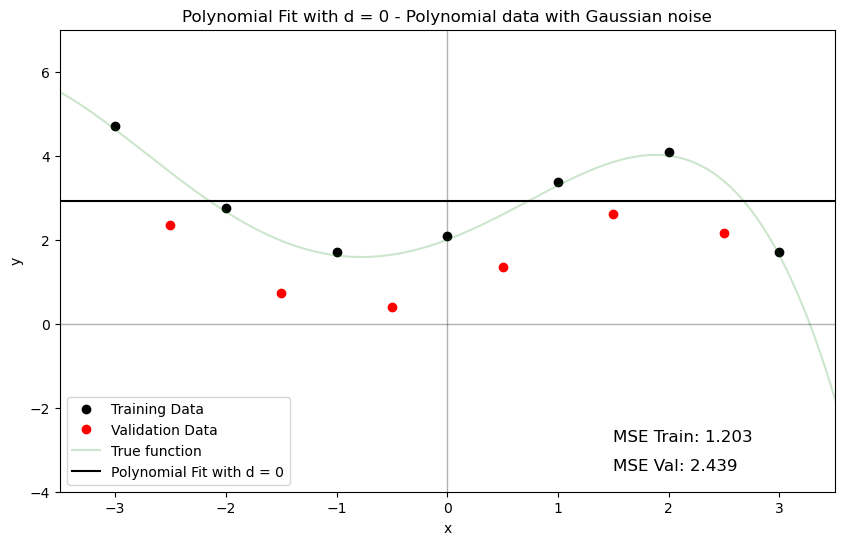

The polynomial is: 2.927436776 -0.1666666667 x 



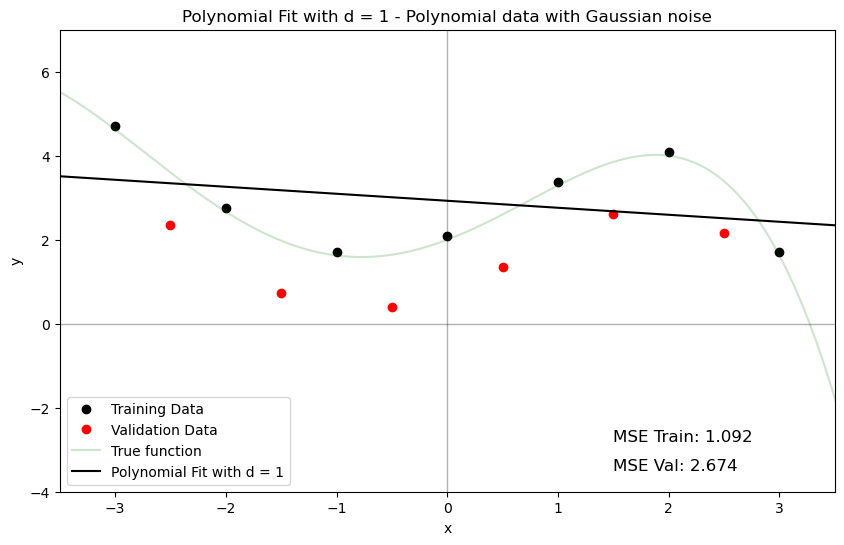

The polynomial is: 2.522674871 -0.1666666667 x +0.1011904762 x**2 



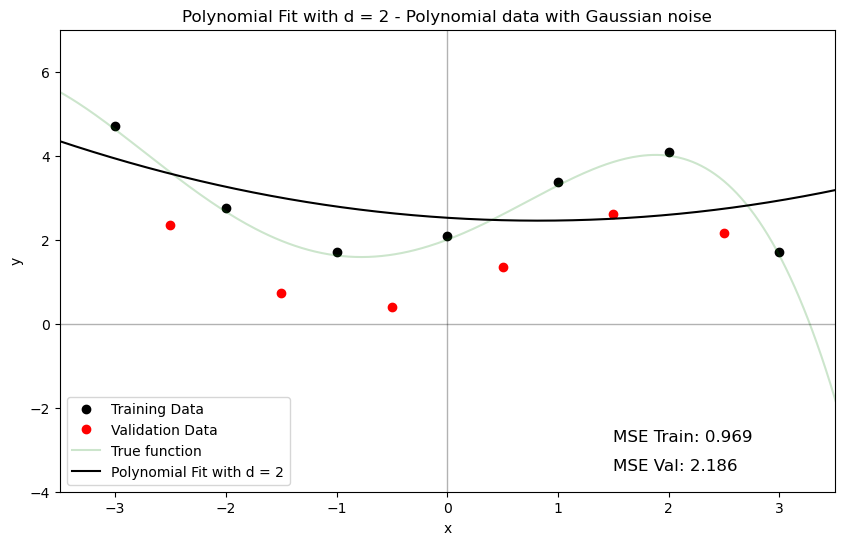

The polynomial is: 2.522674871 +1 x +0.1011904762 x**2 -0.1666666667 x**3 



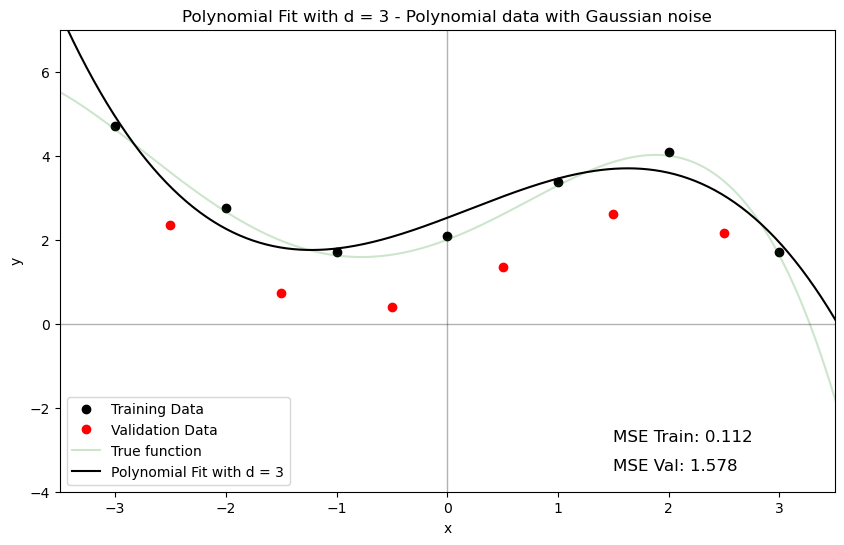

The polynomial is: 2.094103442 +1 x +0.5 x**2 -0.1666666667 x**3 -0.04166666667 x**4 



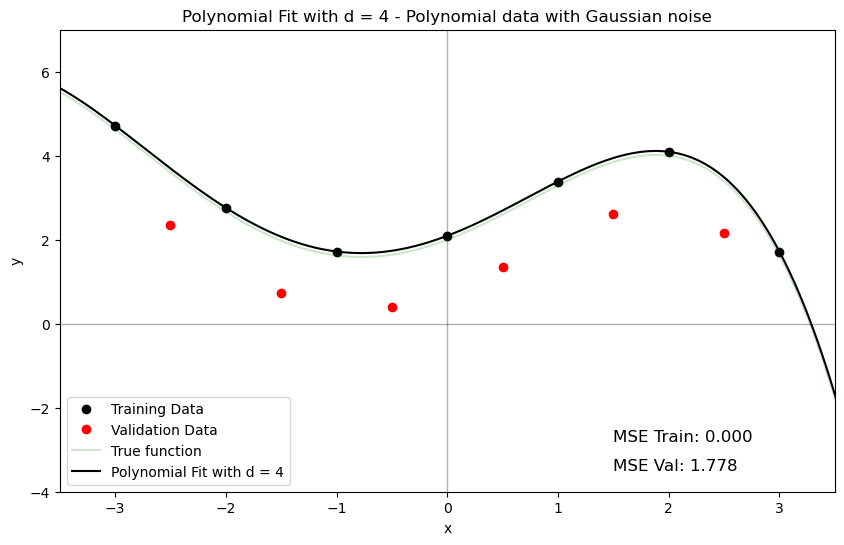

The polynomial is: 2.094103442 +1 x +0.5 x**2 -0.1666666667 x**3 -0.04166666667 x**4 +2.200496729e-15 x**5 



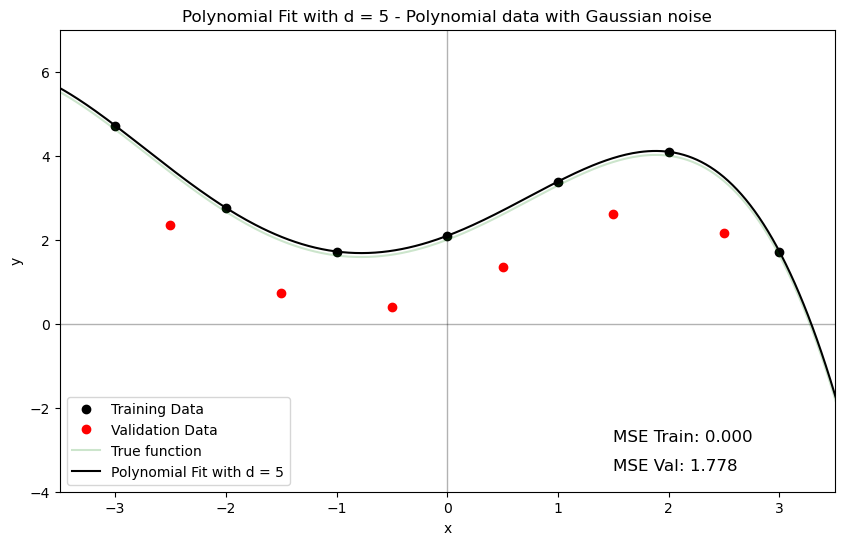

The polynomial is: 2.094103442 +1 x +0.5 x**2 -0.1666666667 x**3 -0.04166666667 x**4 +2.202231453e-15 x**5 +6.51575148e-14 x**6 



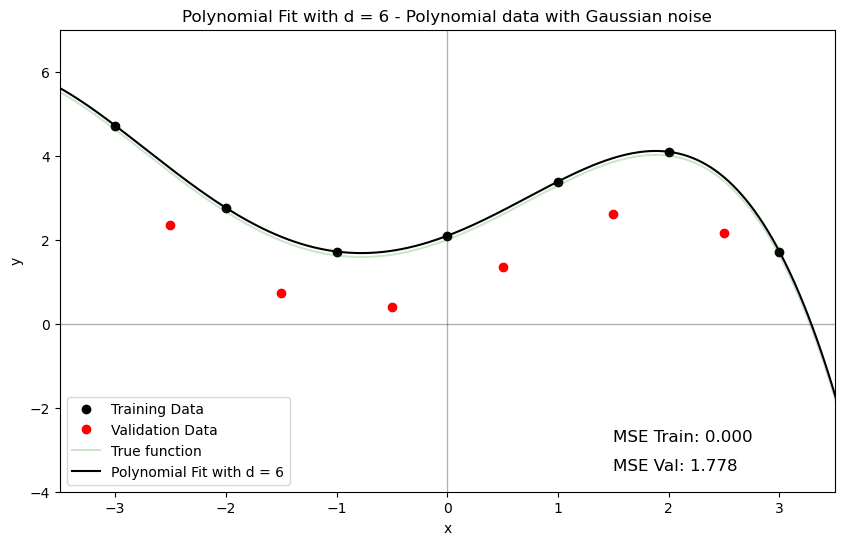

The polynomial is: 2.094103442 +0.5916795069 x +0.5 x**2 +0.3891028933 x**3 -0.04166666667 x**4 -0.1587913029 x**5 +6.603875433e-14 x**6 +0.01134223592 x**7 



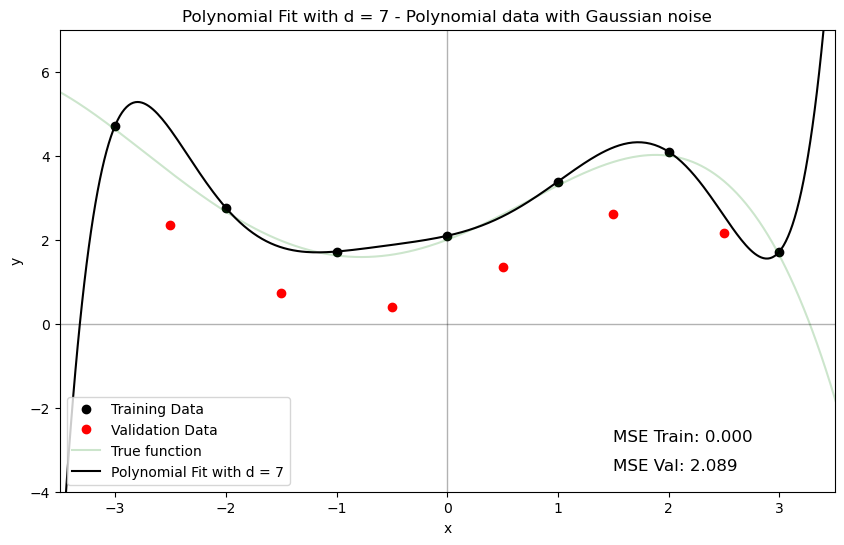

The polynomial is: 2.094103442 +0.5916795069 x +0.3147149461 x**2 +0.3891028933 x**3 +0.210526879 x**4 -0.1587913029 x**5 -0.07205529876 x**6 +0.01134223592 x**7 +0.005146807054 x**8 



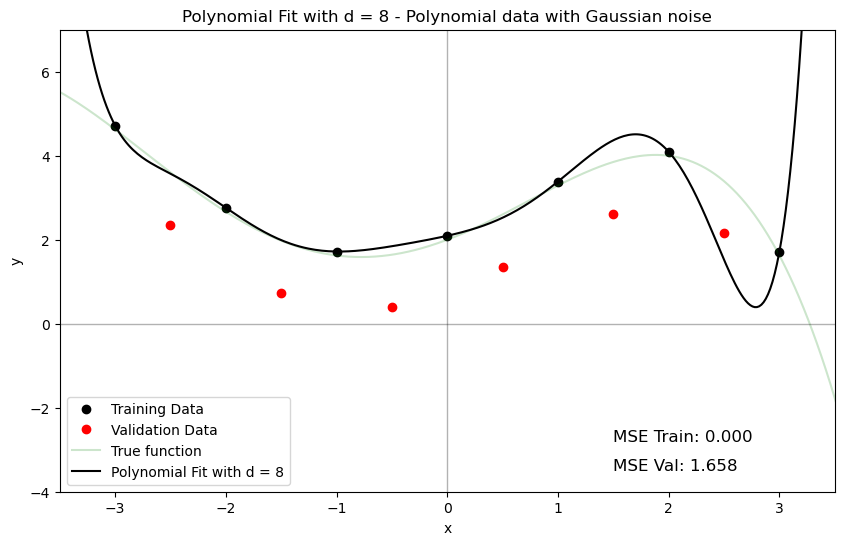

The polynomial is: 2.0941033 +0.3775546224 x +0.3147150621 x**2 +0.3421568668 x**3 +0.2105269541 x**4 +0.2185294509 x**5 -0.07205533397 x**6 -0.1143074341 x**7 +0.005146809901 x**8 +0.009399827393 x**9 



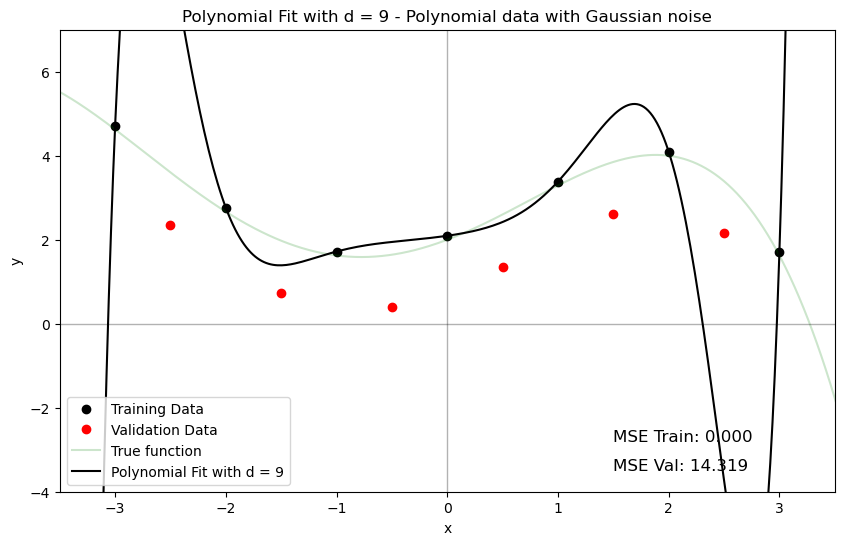

In [61]:
# Assuming polynomial_fits is a list of PolynomialTF objects and solutions is a list of tuples containing the degree,
# omega solutions, polynomial objects, MSE for training, and MSE for validation.

# Example preparation (ensure these are defined appropriately in your actual code)
# polynomial_fits = [PolynomialTF(omega_solution)(x) for d in range(8)]
# solutions = [(d, omega_hat, poly, MSE_train, MSE_val) for d, omega_hat, poly, MSE_train, MSE_val in ...]

def plot_polynomial_fits(x_train: tf.Tensor,
                         y_train: tf.Tensor,
                         x_val: tf.Tensor,
                         y_val: tf.Tensor,
                         polynomial_fits: List[PolynomialTF],
                         solutions: List[Tuple[int, tf.Tensor, PolynomialTF, tf.Tensor, tf.Tensor]],
                         dataset_name: str = "Dataset"
                        ) -> None:
    """Plots polynomial fits along with the training and validation data.
    
    Args:
        x_train: Training data x-values.
        y_train: Training data y-values.
        x_val: Validation data x-values.
        y_val: Validation data y-values.
        polynomial_fits: A list of polynomial fitting functions.
        solutions: A list of tuples containing information about each fit, including MSE for training and validation data.
    """
    for i in range(len(polynomial_fits)):
        print("The polynomial is:", polynomial_fits[i], "\n")
        plt.figure(figsize=(10, 6))
        plt.plot(x_train, y_train, 'o', label='Training Data', color='black')
        plt.plot(x_val, y_val, 'o', label='Validation Data', color='red')

        # Generate x values for plotting
        #x_values: np.ndarray = np.linspace(-4, 4, 400)
        x_values: tf.Tensor = tf.cast(tf.linspace(-4., 4., 400), dtype=tf.float64)
        
        # Generate y values for the original function and its polynomial fit
        y_values_func: tf.Tensor = y(x_values)
        y_values_fit: tf.Tensor = polynomial_fits[i](x_values)

        # Display MSE values as text on the plot
        mse_train: tf.Tensor = solutions[i][3]
        mse_val: tf.Tensor = solutions[i][4]
        plt.text(1.5, -2.8, f'MSE Train: {mse_train:.3f}', fontsize=12, color='black')
        plt.text(1.5, -3.5, f'MSE Val: {mse_val:.3f}', fontsize=12, color='black')
        
        # Plot the function and polynomial fit
        plt.plot(x_values, y_values_func, label='True function', color='green', alpha=0.2)
        plt.plot(x_values, y_values_fit, label=f'Polynomial Fit with d = {i}', color='black')
        
        # Draw axes
        plt.axhline(y=0, color='k', linestyle='-', linewidth=1, alpha=0.3)
        plt.axvline(x=0, color='k', linestyle='-', linewidth=1, alpha=0.3)
        
        # Finalizing plot
        plt.title(f'Polynomial Fit with d = {i} - '+dataset_name)
        plt.xlabel('x')
        plt.ylabel('y')
        plt.legend(loc='lower left')
        plt.xlim(-3.5, 3.5)
        plt.ylim(-4, 7)
        plt.show()

plot_polynomial_fits(x_train, y_train, x_val, y_val, polynomial_fits, solutions, "Polynomial data with Gaussian noise")


### Probabilistic model (non-polynomial data)

In [ ]:
def y(x: tf.Tensor) -> tf.Tensor:
    """Computes the function 3 + sin(x) - cos(x) for given x values.
    
    Args:
        x: A tf tensor of x values.
    
    Returns:
        A tf tensor of y values computed from the function.
    """
    return 3. + tf.sin(x) - tf.cos(x)

def y_stat(x: tf.Tensor) -> tf.Tensor:
    """Generates noisy polynomial data by adding Gaussian noise to the true y values.
    
    Args:
        x: A tf tensor of x values.
    
    Returns:
        A tf tensor of y values computed from the polynomial expression with added Gaussian noise.
    """
    # Generate true y values based on a polynomial expression
    true_y_values: tf.Tensor = y(x)
    
    # Add Gaussian noise with a mean of 0 and standard deviation of 1 to the true y values
    noisy_y_values: tf.Tensor = true_y_values + tf.random.normal(tf.shape(true_y_values), mean=0.0, stddev=1.0, dtype=tf.float64)
    
    return noisy_y_values

In [63]:
# Generate data coordinates
x_train: tf.Tensor = tf.range(-3, 4, 1, dtype=tf.float64)
x_val: tf.Tensor = tf.range(-2.5, 3.5, 1, dtype=tf.float64)

# Generate target values
tf.random.set_seed(100)
y_train: tf.Tensor = y_stat(x_train)
y_val: tf.Tensor = y_stat(x_val)

# Prepare a list to store solutions
solutions: List[Tuple[Any, tf.Tensor, PolynomialTF, tf.Tensor, tf.Tensor]] = []

# Perform the fit for each degree and print the results
show: bool = True
for d in range(10):
    # Generate the design matrix
    X_train: tf.Tensor = design_matrix(d, x_train)
    
    # Compute the weights of the solution
    omega_hat: tf.Tensor = omega_solution(X_train, y_train)
    
    # Define the fit polynomial
    poly: PolynomialTF = poly_solution(omega_hat)
    
    # Compute the MSE for the training and validation data
    MSE_train: tf.Tensor = MSE(omega_hat, x_train, y_train)
    MSE_val: tf.Tensor = MSE(omega_hat, x_val, y_val)
    
    # Store the results
    solutions.append((d, omega_hat, poly, MSE_train, MSE_val))
    
    # Print the results
    if show:
        print(f"===================================================")
        print(f"---------------------- d = {d} ----------------------")
        print(f"===================================================")
        print(f"The degree of the polynomial is: {d}\n")
        #print(f"The hypothesis is: {poly}\n")
        print(f"The design matrix is:\n{X_train}\n")
        print(f"The solution for omega is: {omega_hat}\n")  
        print(f"The polynomial is: {poly}\n")
        print(f"The MSE for the training data is: {MSE_train}")
        print(f"The MSE for the validation data is: {MSE_val}\n")
polynomial_fits = [sol[2] for sol in solutions]

---------------------- d = 0 ----------------------
The degree of the polynomial is: 0

The design matrix is:
[[1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]]

The solution for omega is: [3.19862831]

The polynomial is: 3.198628307

The MSE for the training data is: 0.989074552609905
The MSE for the validation data is: 3.2092694472138503

---------------------- d = 1 ----------------------
The degree of the polynomial is: 1

The design matrix is:
[[ 1. -3.]
 [ 1. -2.]
 [ 1. -1.]
 [ 1.  0.]
 [ 1.  1.]
 [ 1.  2.]
 [ 1.  3.]]

The solution for omega is: [3.19862831 0.2202447 ]

The polynomial is: 3.198628307 +0.2202447045 x

The MSE for the training data is: 0.7950436332141866
The MSE for the validation data is: 2.8761764911879957

---------------------- d = 2 ----------------------
The degree of the polynomial is: 2

The design matrix is:
[[ 1. -3.  9.]
 [ 1. -2.  4.]
 [ 1. -1.  1.]
 [ 1.  0.  0.]
 [ 1.  1.  1.]
 [ 1.  2.  4.]
 [ 1.  3.  9.]]

The solution for omega is: [2.38235503 0.2202447  

The polynomial is: 3.198628307 



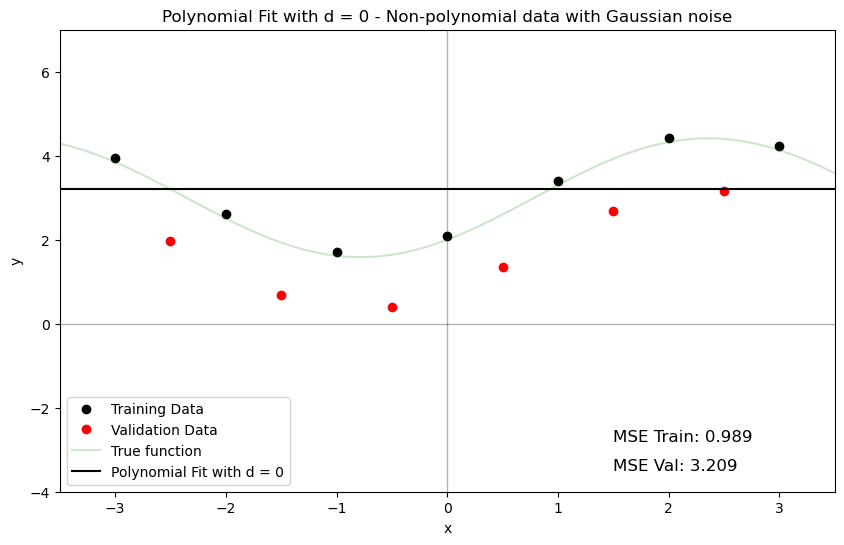

The polynomial is: 3.198628307 +0.2202447045 x 



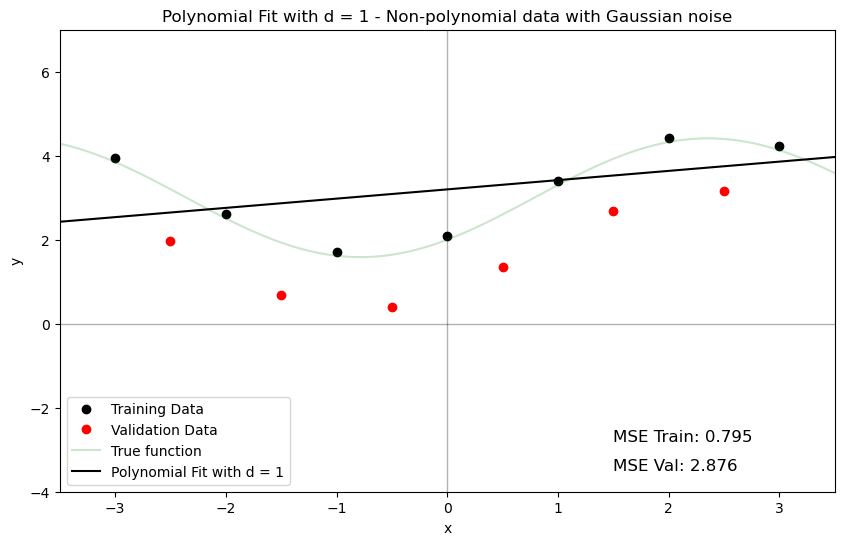

The polynomial is: 2.382355031 +0.2202447045 x +0.2040683191 x**2 



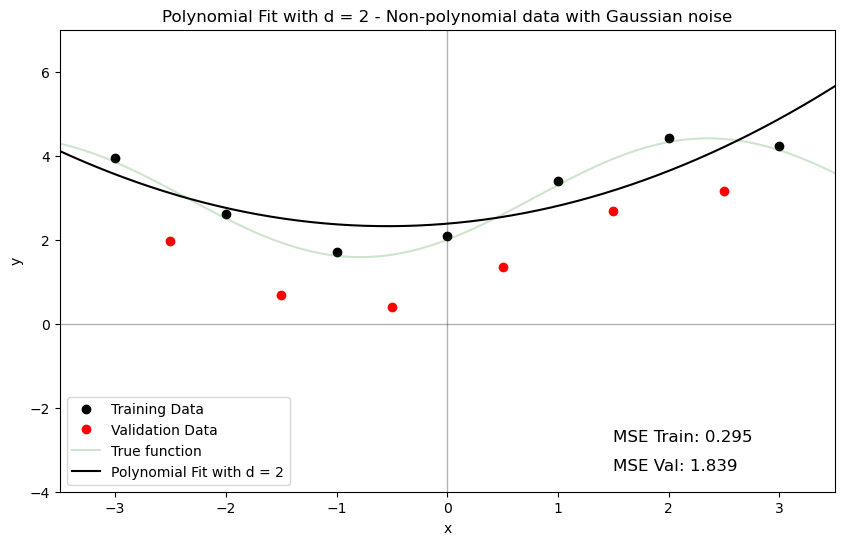

The polynomial is: 2.382355031 +0.8462190836 x +0.2040683191 x**2 -0.08942491131 x**3 



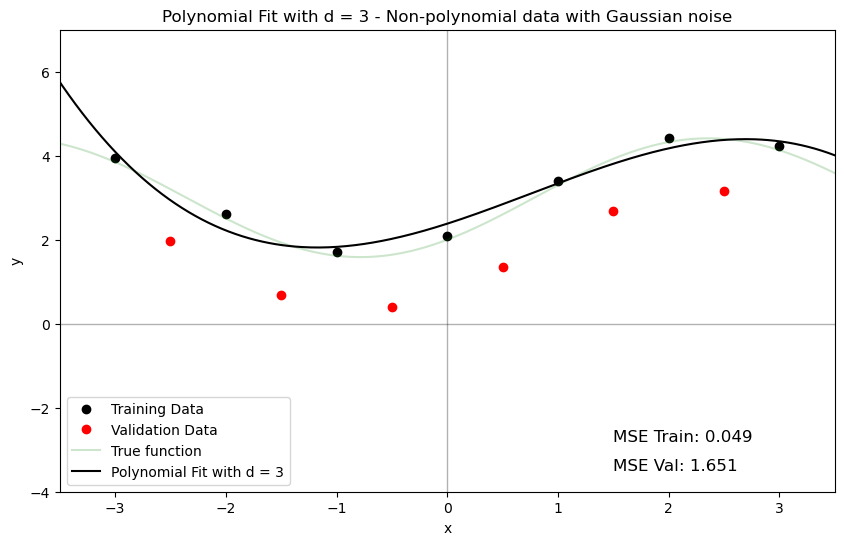

The polynomial is: 2.110924953 +0.8462190836 x +0.4566490864 x**2 -0.08942491131 x**3 -0.02638903539 x**4 



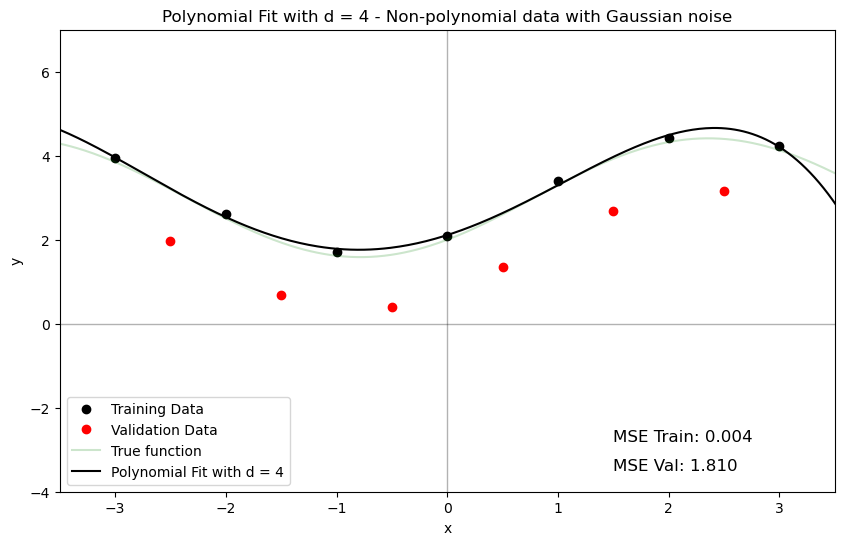

The polynomial is: 2.110924953 +0.9941212494 x +0.4566490864 x**2 -0.1585776415 x**3 -0.02638903539 x**4 +0.005927376873 x**5 



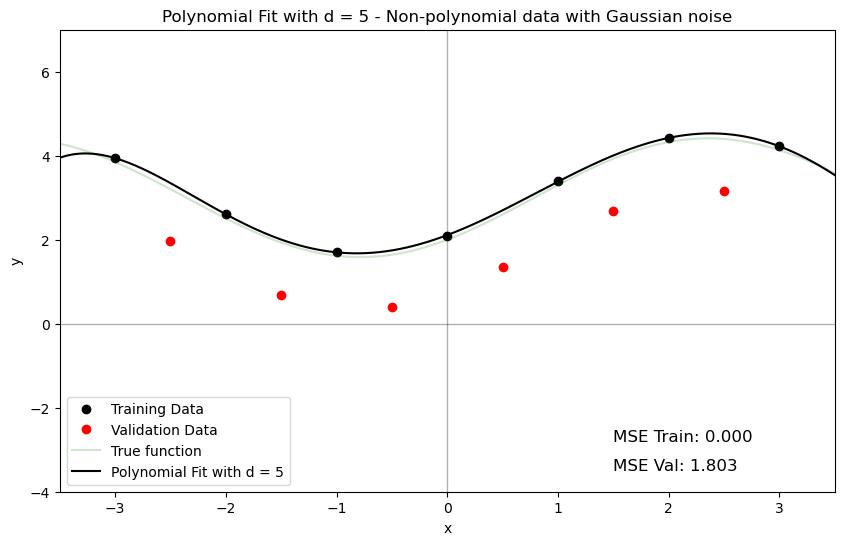

The polynomial is: 2.094103442 +0.9941212494 x +0.4992355435 x**2 -0.1585776415 x**3 -0.04061722957 x**4 +0.005927376873 x**5 +0.001079380248 x**6 



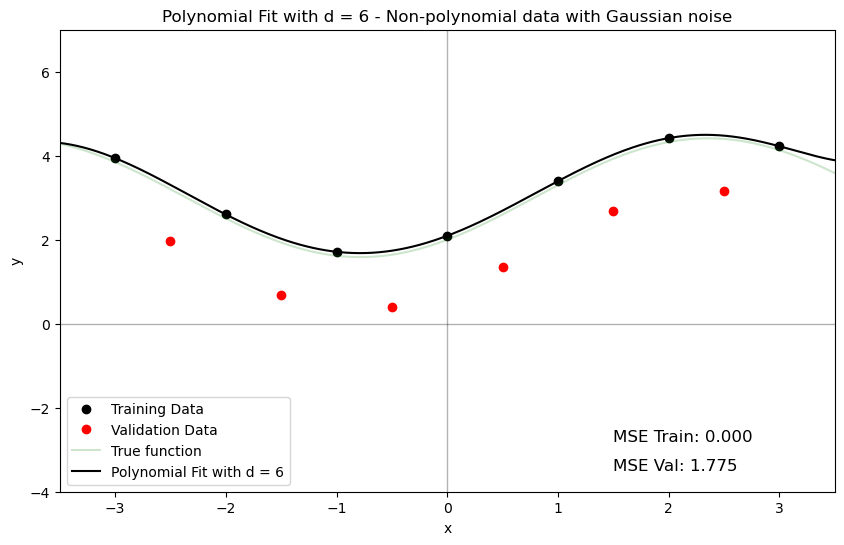

The polynomial is: 2.094103442 +0.5906545065 x +0.4992355435 x**2 +0.3905854252 x**3 -0.04061722957 x**4 -0.1509763565 x**5 +0.001079380248 x**6 +0.01120740952 x**7 



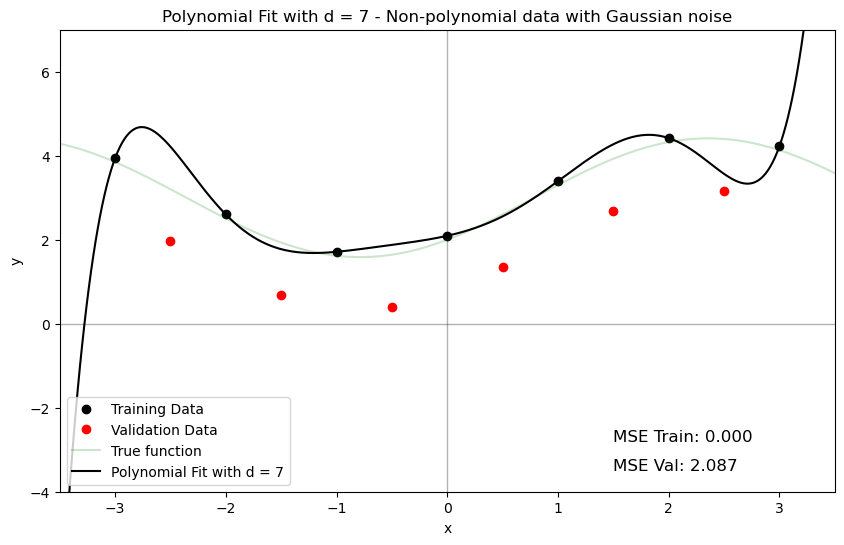

The polynomial is: 2.094103442 +0.5906545065 x +0.3145406115 x**2 +0.3905854252 x**3 +0.2107730945 x**4 -0.1509763565 x**5 -0.07074642662 x**6 +0.01120740952 x**7 +0.005130414777 x**8 



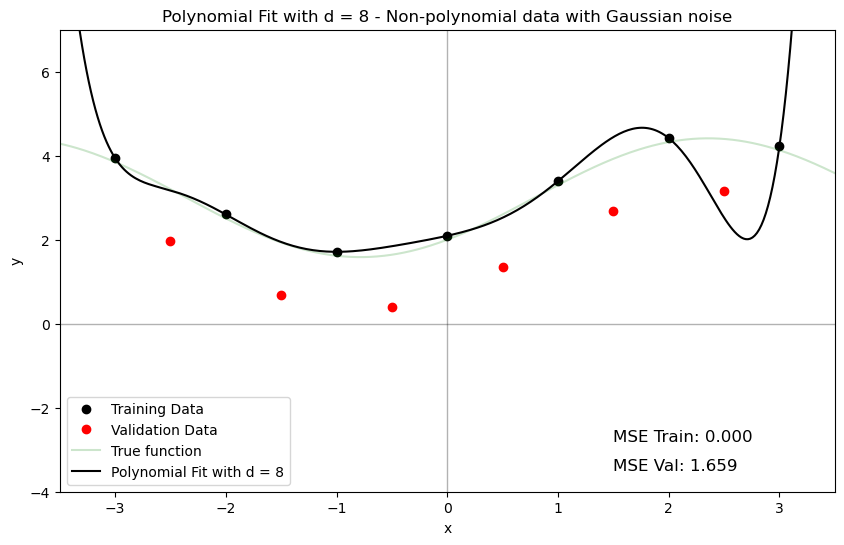

The polynomial is: 2.0941033 +0.379763347 x +0.3145407276 x**2 +0.3443483801 x**3 +0.2107731696 x**4 +0.2206460798 x**5 -0.07074646183 x**6 -0.1125446927 x**7 +0.005130417623 x**8 +0.009257870714 x**9 



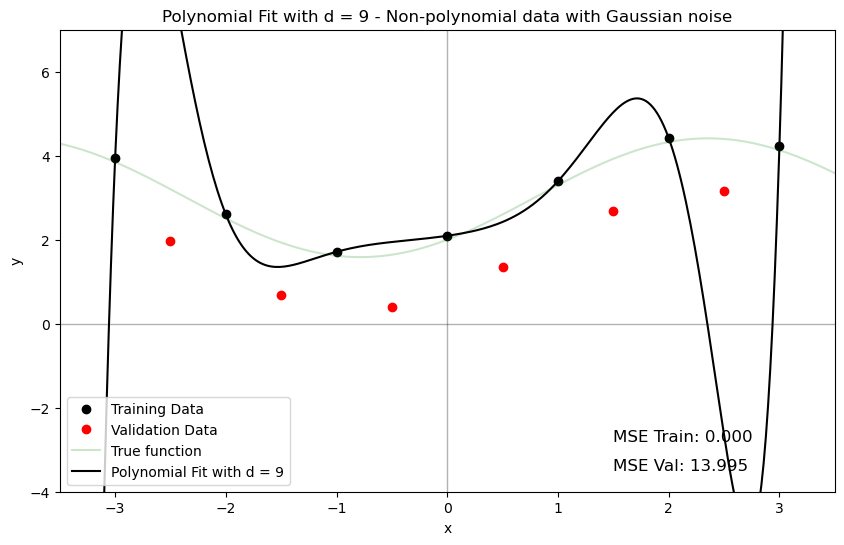

In [64]:
plot_polynomial_fits(x_train, y_train, x_val, y_val, polynomial_fits, solutions, "Non-polynomial data with Gaussian noise")

### Probabilistic model with non-polynomial fit (non-polynomial data)

In [ ]:
def y(x: tf.Tensor) -> tf.Tensor:
    """Computes the function 3 + sin(x) - cos(x) for given x values.
    
    Args:
        x: A tf tensor of x values.
    
    Returns:
        A tf tensor of y values computed from the function.
    """
    return 3. + tf.sin(x) - tf.cos(x)

def y_stat(x: tf.Tensor) -> tf.Tensor:
    """Generates noisy polynomial data by adding Gaussian noise to the true y values.
    
    Args:
        x: A tf tensor of x values.
    
    Returns:
        A tf tensor of y values computed from the polynomial expression with added Gaussian noise.
    """
    # Generate true y values based on a polynomial expression
    true_y_values: tf.Tensor = y(x)
    
    # Add Gaussian noise with a mean of 0 and standard deviation of 1 to the true y values
    noisy_y_values: tf.Tensor = true_y_values + tf.random.normal(tf.shape(true_y_values), mean=0.0, stddev=1.0, dtype=tf.float64)
    
    return noisy_y_values

def y_stat_np(x: np.ndarray) -> np.ndarray:
    """Generates noisy polynomial data by adding Gaussian noise to the true y values.
    
    Args:
        x: A numpy array of x values.
    
    Returns:
        A numpy array of y values computed from the polynomial expression with added Gaussian noise.
    """
    # Generate true y values based on a polynomial expression
    true_y_values: np.ndarray = y(x).numpy()
    
    # Add Gaussian noise with a mean of 0 and standard deviation of 1 to the true y values
    noisy_y_values: np.ndarray = np.random.normal(true_y_values, 1)
    
    return tf.cast(noisy_y_values, dtype=tf.float64)

def design_matrix_trig_tf(x_values: tf.Tensor) -> tf.Tensor:
    """Generates a design matrix for trigonometric regression with TensorFlow.
    
    Args:
        x_values: A tf.Tensor of x values.
    
    Returns:
        A tf.Tensor representing the design matrix with columns for 1, sin(x), and cos(x).
    """
    ones = tf.ones_like(x_values)
    sin_x = tf.sin(x_values)
    cos_x = tf.cos(x_values)
    # Stack along the second dimension (axis=1) to form the design matrix
    return tf.stack([ones, sin_x, cos_x], axis=1)

def omega_solution(X: tf.Tensor, 
                   Y: tf.Tensor
                  ) -> tf.Tensor:
    """Calculates the polynomial coefficients (omega) that best fit the data.
    
    Args:
        X: The design matrix.
        Y: A tf tensor of target y values.
    
    Returns:
        A tf tensor of calculated omega values.
    """
    XT: tf.Tensor = tf.transpose(X)
    Y: tf.Tensor = tf.reshape(Y, (-1, 1))
    omega: tf.Tensor = tf.linalg.pinv(XT @ X) @ XT @ Y
    return tf.reshape(omega, [-1])

def trig_solution(omega_solution: tf.Tensor, 
                  x_values: tf.Tensor
                 ) -> tf.Tensor:
    """Evaluates the trigonometric model at given x values using the omega coefficients.
    
    Args:
        omega_solution: A tf.Tensor of omega coefficients for [constant, sin(x), cos(x)].
        x_values: A tf.Tensor of x values for evaluation.
    
    Returns:
        A tf.Tensor of y values predicted by the trigonometric model.
    """
    return omega_solution[0] + omega_solution[1] * tf.sin(x_values) + omega_solution[2] * tf.cos(x_values)

def MSE(omega_solution: tf.Tensor, 
        x_values: tf.Tensor,
        y_true: tf.Tensor
       ) -> tf.Tensor:
    """Calculates the Mean Squared Error (MSE) for given omega coefficients and x values.
    
    Args:
        omega_solution: A 1D tf.Tensor of omega coefficients.
        x_values: A 1D tf.Tensor of x values for evaluation.
    
    Returns:
        The MSE as a tf.Tensor.
    """
    y_pred: tf.Tensor = trig_solution(omega_solution, x_values)
    return tf.reduce_mean(tf.square(y_true - y_pred))


In [38]:
# Generate data coordinates
x_train: tf.Tensor = tf.range(-3, 4, 1, dtype=tf.float64)
x_val: tf.Tensor = tf.range(-2.5, 3.5, 1, dtype=tf.float64)

# Generate target values through the statistical model with tf
tf.random.set_seed(100)
y_train: tf.Tensor = y_stat(x_train)
y_val: tf.Tensor = y_stat(x_val)

# Flag to control printing of the solution details
show: bool = True

# Generate the design matrix
X_train: tf.Tensor = design_matrix_trig_tf(x_train)

# Compute the weights of the solution
omega_hat: tf.Tensor = omega_solution(X_train, y_train)

# Compute the MSE for the training and validation data
MSE_train: tf.Tensor = MSE(omega_hat, x_train, y_train)
MSE_val: tf.Tensor = MSE(omega_hat, x_val, y_val)

# Print the results
if show:
    print("----------------- Trigonometric Model -----------------")
    print(f"The design matrix is:\n{X_train}\n")
    print(f"The target values are:\n{y_train}\n")
    print(f"The solution for omega is: {omega_hat}\n")
    print(f"The MSE for the training data is: {MSE_train}")
    print(f"The MSE for the validation data is: {MSE_val}\n")

----------------- Trigonometric Model -----------------
The design matrix is:
[[ 1.         -0.14112001 -0.9899925 ]
 [ 1.         -0.90929743 -0.41614684]
 [ 1.         -0.84147098  0.54030231]
 [ 1.          0.          1.        ]
 [ 1.          0.84147098  0.54030231]
 [ 1.          0.90929743 -0.41614684]
 [ 1.          0.14112001 -0.9899925 ]]

The target values are:
[3.94297593 2.59169823 1.16056079 1.82741399 2.66144389 5.37548165
 6.14539546]

The solution for omega is: [ 3.19642425  1.32011047 -1.81774952]

The MSE for the training data is: 0.3427335003902935
The MSE for the validation data is: 1.62950625238198



In [39]:
# Generate data coordinates
x_train: tf.Tensor = tf.range(-3, 4, 1, dtype=tf.float64)
x_val: tf.Tensor = tf.range(-2.5, 3.5, 1, dtype=tf.float64)

# Generate target values through the statistical model with tf
#tf.random.set_seed(100)
#y_train: tf.Tensor = y_stat(x_train)
#y_val: tf.Tensor = y_stat(x_val)
# To reproduce the same results as with numpy
np.random.seed(100)
y_train: np.ndarray = y_stat_np(x_train)
y_val: np.ndarray = y_stat_np(x_val)

# Flag to control printing of the solution details
show: bool = True

# Generate the design matrix
X_train: tf.Tensor = design_matrix_trig_tf(x_train)

# Compute the weights of the solution
omega_hat: tf.Tensor = omega_solution(X_train, y_train)

# Compute the MSE for the training and validation data
MSE_train: tf.Tensor = MSE(omega_hat, x_train, y_train)
MSE_val: tf.Tensor = MSE(omega_hat, x_val, y_val)

# Print the results
if show:
    print("----------------- Trigonometric Model -----------------")
    print(f"The design matrix is:\n{X_train}\n")
    print(f"The target values are:\n{y_train}\n")
    print(f"The solution for omega is: {omega_hat}\n")
    print(f"The MSE for the training data is: {MSE_train}")
    print(f"The MSE for the validation data is: {MSE_val}\n")

----------------- Trigonometric Model -----------------
The design matrix is:
[[ 1.         -0.14112001 -0.9899925 ]
 [ 1.         -0.90929743 -0.41614684]
 [ 1.         -0.84147098  0.54030231]
 [ 1.          0.          1.        ]
 [ 1.          0.84147098  0.54030231]
 [ 1.          0.90929743 -0.41614684]
 [ 1.          0.14112001 -0.9899925 ]]

The target values are:
[2.09910702 2.84952981 2.77126251 1.74756396 4.28248947 4.8396631
 4.35229217]

The solution for omega is: [ 3.23274463  1.09313872 -0.42737018]

The MSE for the training data is: 0.6231208529025821
The MSE for the validation data is: 0.4426790841588102



Fit with true function



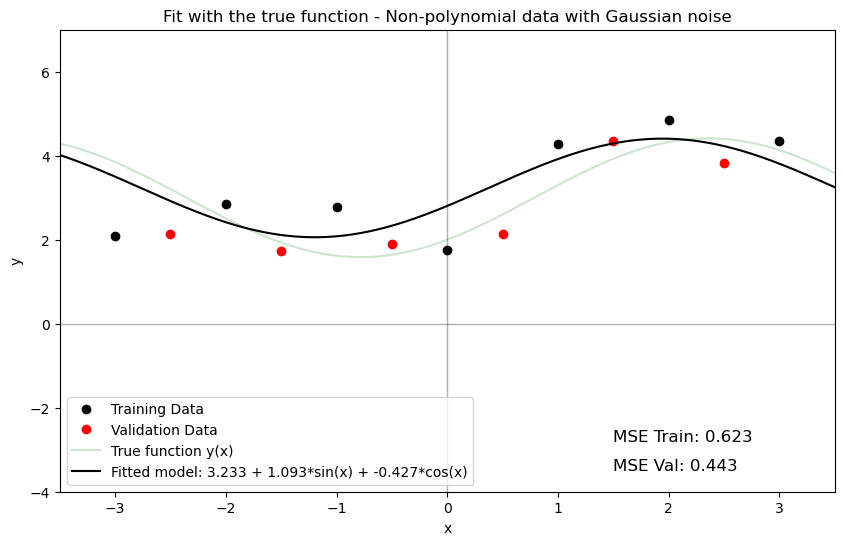

In [40]:
print("Fit with true function\n")
omega_hat_str = f"{omega_hat[0]:.3f} + {omega_hat[1]:.3f}*sin(x) + {omega_hat[2]:.3f}*cos(x)"
plt.figure(figsize=(10, 6))
plt.plot(x_train, y_train, 'o', label='Training Data', color='black')
plt.plot(x_val, y_val, 'o', label='Validation Data', color='red')

# Generate x values for plotting
x_values: tf.Tensor = tf.cast(tf.linspace(-4., 4., 400), dtype=tf.float64)

# Generate y values for the function and the model fit
y_values_func: tf.Tensor = y(x_values)
y_values_fit: tf.Tensor = trig_solution(omega_hat, x_values)  # Use trig_solution instead of poly_solution

plt.text(1.5, -2.8, f'MSE Train: {MSE_train:.3f}', fontsize=12, color='black')
plt.text(1.5, -3.5, f'MSE Val: {MSE_val:.3f}', fontsize=12, color='black')
    
plt.plot(x_values, y_values_func, label='True function y(x)', color='green', alpha=0.2)
plt.plot(x_values, y_values_fit, label='Fitted model: ' + omega_hat_str, color='black')

# Drawing axes
plt.axhline(y=0, color='k', linestyle='-', linewidth=1, alpha=0.3)
plt.axvline(x=0, color='k', linestyle='-', linewidth=1, alpha=0.3)

# Finalizing plot
plt.title(f'Fit with the true function - Non-polynomial data with Gaussian noise')
plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc='lower left')
plt.xlim(-3.5, 3.5)
plt.ylim(-4, 7)
plt.show()


## PyTorch code

### Deterministic solution (polynomial data)

In [130]:
class PolynomialTorch:
    def __init__(self, coefficients):
        """
        Initializes the polynomial with given coefficients.

        Args:
            coefficients: A 1D torch.Tensor or a Python list of polynomial coefficients
                          from the lowest to the highest degree.
        """
        self.coefficients = torch.tensor(coefficients, dtype=torch.float64)

    def __call__(self, x):
        """
        Evaluates the polynomial at given x values.

        Args:
            x: A 1D torch.Tensor or a list of x values where the polynomial is to be evaluated.

        Returns:
            A torch.Tensor containing the evaluated polynomial values at each x value.
        """
        x = torch.tensor(x, dtype=torch.float64)
        degree = self.coefficients.shape[0]
        x_powers = torch.pow(x.unsqueeze(-1), torch.arange(0, degree, dtype=torch.float64))
        poly_values = torch.sum(x_powers * self.coefficients, dim=1)
        return poly_values

    def __str__(self):
        """
        Returns a string representation of the polynomial.
        """
        terms = []
        for i, coeff in enumerate(self.coefficients.numpy()):
            if coeff != 0:  # Skip terms with a coefficient of zero
                if i == 0:
                    terms.append(f"{coeff:.10g}")
                elif i == 1:
                    terms.append(f"{coeff:+.10g} x")
                else:
                    terms.append(f"{coeff:+.10g} x**{i}")
        return " ".join(terms)

In [131]:
import torch

def y(x: torch.Tensor) -> torch.Tensor:
    """Generates polynomial data based on a given polynomial expression.
    
    Args:
        x: A torch tensor of x values.
    
    Returns:
        A torch tensor of y values computed from the polynomial expression.
    """
    return (-torch.pow(x, 4)/24 - torch.pow(x, 3)/6 + torch.pow(x, 2)/2 + x + 2).to(torch.float64)

def design_matrix(degree: int, x_values: torch.Tensor) -> torch.Tensor:
    """Generates a design matrix for polynomial regression of a specified degree.
    
    Args:
        degree: The degree of the polynomial hypothesis.
        x_values: A torch tensor of x values.
    
    Returns:
        A design matrix as a torch tensor.
    """
    return torch.stack([x_values**i for i in range(degree + 1)], dim=1)

def omega_solution(X: torch.Tensor, Y: torch.Tensor) -> torch.Tensor:
    """Calculates the polynomial coefficients (omega) that best fit the data.
    
    Args:
        X: The design matrix.
        Y: A torch tensor of target y values.
    
    Returns:
        A torch tensor of calculated omega values.
    """
    XT: torch.Tensor = X.T
    Y: torch.Tensor = Y.view(-1, 1)  # Reshape to column vector
    omega: torch.Tensor = torch.linalg.pinv(XT @ X) @ XT @ Y
    return omega.view(-1)  # Flatten

def poly_solution(omega_solution: torch.Tensor) -> PolynomialTorch:
    """Converts omega coefficients to a torch PolynomialTorch object.
    
    Args:
        omega_solution: A torch.Tensor of omega coefficients.
    
    Returns:
        A torch PolynomialTorch object representing the fitted polynomial.
    """
    return PolynomialTorch(omega_solution)

def MSE(omega_solution: torch.Tensor, x_values: torch.Tensor, y_true: torch.Tensor) -> torch.Tensor:
    """Calculates the Mean Squared Error (MSE) for given omega coefficients and x values.
    
    Args:
        omega_solution: A 1D torch.Tensor of omega coefficients.
        x_values: A 1D torch.Tensor of x values for evaluation.
        y_true: A 1D torch.Tensor of true y values.
    
    Returns:
        The MSE as a torch.Tensor.
    """
    poly: PolynomialTorch = poly_solution(omega_solution)
    y_pred: torch.Tensor = poly(x_values)
    return torch.mean((y_true - y_pred) ** 2)

In [132]:
# Generate data coordinates
x_train: torch.Tensor = torch.arange(-3, 4, 1, dtype=torch.float64)
x_val: torch.Tensor = torch.arange(-2.5, 3.5, 1, dtype=torch.float64)

# Generate target values
y_train: torch.Tensor = y(x_train)
y_val: torch.Tensor = y(x_val)

# Perform the fit for each degree and print the results
show: bool = True
for d in range(8):
    # Generate the design matrix
    X_train: torch.Tensor = design_matrix(d, x_train)
    
    # Compute the weights of the solution
    omega_hat: torch.Tensor = omega_solution(X_train, y_train)
    
    # Define the fit polynomial
    poly: PolynomialTorch = poly_solution(omega_hat)
    
    # Compute the MSE for the training and validation data
    MSE_train: torch.Tensor = MSE(omega_hat, x_train, y_train)
    MSE_val: torch.Tensor = MSE(omega_hat, x_val, y_val)
    
    # Print the results
    if show:
        print(f"===================================================")
        print(f"---------------------- d = {d} ----------------------")
        print(f"===================================================")
        print(f"The degree of the polynomial is: {d}\n")
        print(f"The design matrix is:\n{X_train}\n")
        print(f"The solution for omega is: {omega_hat}\n")  
        print(f"The polynomial is: {poly}\n")
        print(f"The MSE for the training data is: {MSE_train}")
        print(f"The MSE for the validation data is: {MSE_val}\n")

---------------------- d = 0 ----------------------
The degree of the polynomial is: 0

The design matrix is:
tensor([[1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.]], dtype=torch.float64)

The solution for omega is: tensor([2.8333], dtype=torch.float64)

The polynomial is: 2.833333333

The MSE for the training data is: 1.2033730158730158
The MSE for the validation data is: 0.6907619900173613

---------------------- d = 1 ----------------------
The degree of the polynomial is: 1

The design matrix is:
tensor([[ 1., -3.],
        [ 1., -2.],
        [ 1., -1.],
        [ 1.,  0.],
        [ 1.,  1.],
        [ 1.,  2.],
        [ 1.,  3.]], dtype=torch.float64)

The solution for omega is: tensor([ 2.8333, -0.1667], dtype=torch.float64)

The polynomial is: 2.833333333 -0.1666666667 x

The MSE for the training data is: 1.0922619047619049
The MSE for the validation data is: 0.925715693721065

---------------------- d = 2 ----------------------
The d

/var/folders/8p/lb_zz6bs7g7cdkt7y_yjy0z40000gn/T/ipykernel_41146/1536676131.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.coefficients = torch.tensor(coefficients, dtype=torch.float64)
/var/folders/8p/lb_zz6bs7g7cdkt7y_yjy0z40000gn/T/ipykernel_41146/1536676131.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float64)


### Deterministic solution (non-polynomial data)

In [133]:
def y(x: torch.Tensor) -> torch.Tensor:
    """Computes the function 3 + sin(x) - cos(x) for given x values.
    
    Args:
        x: A torch tensor of x values.
    
    Returns:
        A torch tensor of y values computed from the function.
    """
    return 3. + torch.sin(x) - torch.cos(x)

In [134]:
# Generate data coordinates
x_train = torch.arange(-3, 4, 1, dtype=torch.float64)
x_val = torch.arange(-2.5, 3.5, 1, dtype=torch.float64)

# Generate target values
y_train = y(x_train)
y_val = y(x_val)

# Perform the fit for each degree and print the results
show = True
for d in range(10):
    # Generate the design matrix
    X_train = design_matrix(d, x_train)

    # Compute the weights of the solution
    omega_hat = omega_solution(X_train, y_train)

    # Define the fit polynomial
    poly = poly_solution(omega_hat)

    # Compute the MSE for the training and validation data
    MSE_train = MSE(omega_hat, x_train, y_train)
    MSE_val = MSE(omega_hat, x_val, y_val)

    # Print the results
    if show:
        print(f"===================================================")
        print(f"---------------------- d = {d} ----------------------")
        print(f"===================================================")
        print(f"The degree of the polynomial is: {d}\n")
        print(f"The design matrix is:\n{X_train}\n")
        print(f"The solution for omega is: {omega_hat}\n")  
        print(f"The polynomial is: {poly}\n")
        print(f"The MSE for the training data is: {MSE_train}")
        print(f"The MSE for the validation data is: {MSE_val}\n")

---------------------- d = 0 ----------------------
The degree of the polynomial is: 0

The design matrix is:
tensor([[1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.]], dtype=torch.float64)

The solution for omega is: tensor([3.1045], dtype=torch.float64)

The polynomial is: 3.104524865

The MSE for the training data is: 0.989074552609905
The MSE for the validation data is: 1.0211811587186352

---------------------- d = 1 ----------------------
The degree of the polynomial is: 1

The design matrix is:
tensor([[ 1., -3.],
        [ 1., -2.],
        [ 1., -1.],
        [ 1.,  0.],
        [ 1.,  1.],
        [ 1.,  2.],
        [ 1.,  3.]], dtype=torch.float64)

The solution for omega is: tensor([3.1045, 0.2202], dtype=torch.float64)

The polynomial is: 3.104524865 +0.2202447045 x

The MSE for the training data is: 0.7950436332141865
The MSE for the validation data is: 0.6880882026927809

---------------------- d = 2 ----------------------
The deg

/var/folders/8p/lb_zz6bs7g7cdkt7y_yjy0z40000gn/T/ipykernel_41146/1536676131.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.coefficients = torch.tensor(coefficients, dtype=torch.float64)
/var/folders/8p/lb_zz6bs7g7cdkt7y_yjy0z40000gn/T/ipykernel_41146/1536676131.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float64)


### Deterministic model with non-polynomial fit (non-polynomial data)

In [ ]:
def y(x: torch.Tensor) -> torch.Tensor:
    """Computes the function 3 + sin(x) - cos(x) for given x values.
    
    Args:
        x: A torch tensor of x values.
    
    Returns:
        A torch tensor of y values computed from the function.
    """
    return (3 + torch.sin(x) - torch.cos(x)).double()

def design_matrix_trig_torch(x_values: torch.Tensor) -> torch.Tensor:
    """Generates a design matrix for trigonometric regression with PyTorch.
    
    Args:
        x_values: A torch.Tensor of x values.
    
    Returns:
        A torch.Tensor representing the design matrix with columns for 1, sin(x), and cos(x).
    """
    ones = torch.ones_like(x_values)
    sin_x = torch.sin(x_values)
    cos_x = torch.cos(x_values)
    # Stack along the second dimension (axis=1) to form the design matrix
    return torch.stack([ones, sin_x, cos_x], dim=1)

def omega_solution(X: torch.Tensor, 
                   Y: torch.Tensor
                  ) -> torch.Tensor:
    """Calculates the polynomial coefficients (omega) that best fit the data.
    
    Args:
        X: The design matrix.
        Y: A torch tensor of target y values.
    
    Returns:
        A torch tensor of calculated omega values.
    """
    XT: torch.Tensor = X.t()  # Transpose of X
    Y: torch.Tensor = Y.view(-1, 1)  # Reshape Y to be a column vector
    omega: torch.Tensor = torch.linalg.pinv(XT @ X) @ XT @ Y
    return omega.view(-1)  # Flatten the omega tensor

def trig_solution(omega_solution: torch.Tensor, 
                  x_values: torch.Tensor
                 ) -> torch.Tensor:
    """Evaluates the trigonometric model at given x values using the omega coefficients.
    
    Args:
        omega_solution: A torch.Tensor of omega coefficients for [constant, sin(x), cos(x)].
        x_values: A torch.Tensor of x values for evaluation.
    
    Returns:
        A torch.Tensor of y values predicted by the trigonometric model.
    """
    return omega_solution[0] + omega_solution[1] * torch.sin(x_values) + omega_solution[2] * torch.cos(x_values)

def MSE(omega_solution: torch.Tensor, 
        x_values: torch.Tensor,
        y_true: torch.Tensor
       ) -> torch.Tensor:
    """Calculates the Mean Squared Error (MSE) for given omega coefficients and x values.
    
    Args:
        omega_solution: A 1D torch.Tensor of omega coefficients.
        x_values: A 1D torch.Tensor of x values for evaluation.
    
    Returns:
        The MSE as a torch.Tensor.
    """
    y_pred: torch.Tensor = trig_solution(omega_solution, x_values)
    return torch.mean((y_true - y_pred)**2)

In [ ]:
# Generate data coordinates
x_train = torch.arange(-3, 4, 1, dtype=torch.float64)
x_val = torch.arange(-2.5, 3.5, 1, dtype=torch.float64)

# Generate target values through the statistical model with torch
torch.manual_seed(100)
y_train = y(x_train)
y_val = y(x_val)

# Flag to control printing of the solution details
show = True

# Generate the design matrix
X_train = design_matrix_trig_torch(x_train)

# Compute the weights of the solution
omega_hat = omega_solution(X_train, y_train)

# Compute the MSE for the training and validation data
MSE_train = MSE(omega_hat, x_train, y_train)
MSE_val = MSE(omega_hat, x_val, y_val)

# Print the results
if show:
    print("----------------- Trigonometric Model -----------------")
    print(f"The design matrix is:\n{X_train}\n")
    print(f"The target values are:\n{y_train}\n")
    print(f"The solution for omega is: {omega_hat}\n")
    print(f"The MSE for the training data is: {MSE_train}")
    print(f"The MSE for the validation data is: {MSE_val}\n")

----------------- Trigonometric Model -----------------
The design matrix is:
tensor([[ 1.0000, -0.1411, -0.9900],
        [ 1.0000, -0.9093, -0.4161],
        [ 1.0000, -0.8415,  0.5403],
        [ 1.0000,  0.0000,  1.0000],
        [ 1.0000,  0.8415,  0.5403],
        [ 1.0000,  0.9093, -0.4161],
        [ 1.0000,  0.1411, -0.9900]], dtype=torch.float64)

The target values are:
tensor([4.2095, 2.2209, 1.2244, 2.2429, 1.9178, 2.0120, 3.8139],
       dtype=torch.float64)

The solution for omega is: tensor([ 2.4128,  0.1086, -1.0278], dtype=torch.float64)

The MSE for the training data is: 0.4183487933903772
The MSE for the validation data is: 1.3736800844998454



### Probabilistic model (polynomial data)

In [135]:
def y(x: torch.Tensor) -> torch.Tensor:
    """Generates polynomial data based on a given polynomial expression.

    Args:
        x: A torch tensor of x values.

    Returns:
        A torch tensor of y values computed from the polynomial expression.
    """
    return (-torch.pow(x, 4) / 24 - torch.pow(x, 3) / 6 + torch.pow(x, 2) / 2 + x + 2).double()

def y_stat(x: torch.Tensor) -> torch.Tensor:
    """Generates noisy polynomial data by adding Gaussian noise to the true y values.

    Args:
        x: A torch tensor of x values.

    Returns:
        A torch tensor of y values computed from the polynomial expression with added Gaussian noise.
    """
    # Generate true y values based on a polynomial expression
    true_y_values = y(x)

    # Add Gaussian noise with mean 0 and standard deviation 1
    noisy_y_values = torch.normal(mean=true_y_values, std=1.0)

    return noisy_y_values

In [136]:
# Generate data coordinates
x_train: torch.Tensor = torch.arange(-3, 4, 1, dtype=torch.float64)
x_val: torch.Tensor = torch.arange(-2.5, 3.5, 1, dtype=torch.float64)

# Generate target values with noise
torch.manual_seed(100)
y_train: torch.Tensor = y_stat(x_train)
y_val: torch.Tensor = y_stat(x_val)

# Prepare a list to store solutions
solutions: List[Tuple[Any, torch.Tensor, Any, torch.Tensor, torch.Tensor]] = []

# Perform the fit for each degree and print the results
show: bool = True
for d in range(10):
    # Generate the design matrix
    X_train: torch.Tensor = design_matrix(d, x_train)
    
    # Compute the weights of the solution
    omega_hat: torch.Tensor = omega_solution(X_train, y_train)
    
    # Define the fit polynomial
    poly = poly_solution(omega_hat)  # Assuming `poly_solution` is adapted for PyTorch
    
    # Compute the MSE for the training and validation data
    MSE_train: torch.Tensor = MSE(omega_hat, x_train, y_train)
    MSE_val: torch.Tensor = MSE(omega_hat, x_val, y_val)
    
    # Store the results
    solutions.append((d, omega_hat, poly, MSE_train, MSE_val))
    
    # Print the results
    if show:
        print(f"===================================================")
        print(f"---------------------- d = {d} ----------------------")
        print(f"===================================================")
        print(f"The degree of the polynomial is: {d}\n")
        # print(f"The hypothesis is: {poly}\n")
        print(f"The design matrix is:\n{X_train}\n")
        print(f"The solution for omega is: {omega_hat}\n")  
        print(f"The polynomial is: {poly}\n")
        print(f"The MSE for the training data is: {MSE_train}")
        print(f"The MSE for the validation data is: {MSE_val}\n")

# Extract polynomial fits
polynomial_fits = [sol[2] for sol in solutions]

---------------------- d = 0 ----------------------
The degree of the polynomial is: 0

The design matrix is:
tensor([[1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.]], dtype=torch.float64)

The solution for omega is: tensor([2.2490], dtype=torch.float64)

The polynomial is: 2.249033321

The MSE for the training data is: 1.4086946392237414
The MSE for the validation data is: 1.5672164111230407

---------------------- d = 1 ----------------------
The degree of the polynomial is: 1

The design matrix is:
tensor([[ 1., -3.],
        [ 1., -2.],
        [ 1., -1.],
        [ 1.,  0.],
        [ 1.,  1.],
        [ 1.,  2.],
        [ 1.,  3.]], dtype=torch.float64)

The solution for omega is: tensor([ 2.2490, -0.4195], dtype=torch.float64)

The polynomial is: 2.249033321 -0.4194555386 x

The MSE for the training data is: 0.7049228439139418
The MSE for the validation data is: 1.628690088780511

---------------------- d = 2 ----------------------
The d

/var/folders/8p/lb_zz6bs7g7cdkt7y_yjy0z40000gn/T/ipykernel_41146/1536676131.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.coefficients = torch.tensor(coefficients, dtype=torch.float64)
/var/folders/8p/lb_zz6bs7g7cdkt7y_yjy0z40000gn/T/ipykernel_41146/1536676131.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float64)


The polynomial is: 2.249033321 



/var/folders/8p/lb_zz6bs7g7cdkt7y_yjy0z40000gn/T/ipykernel_41146/1536676131.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float64)


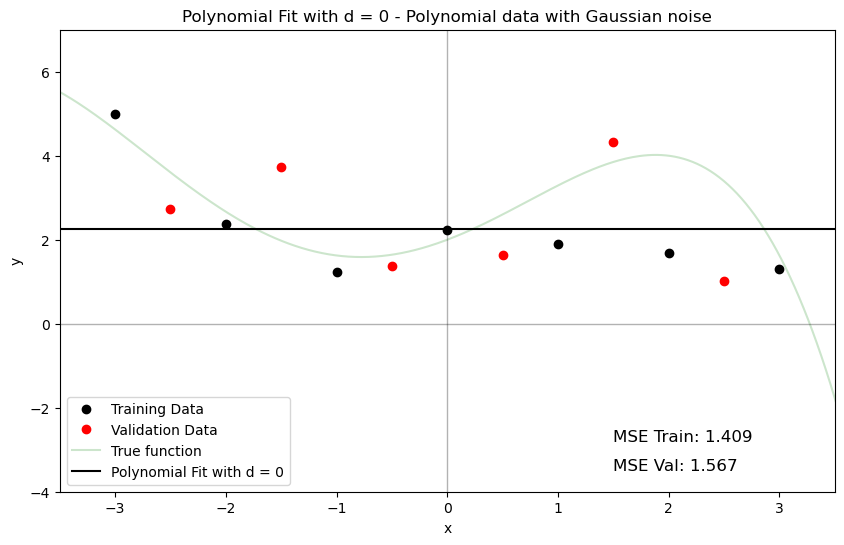

The polynomial is: 2.249033321 -0.4194555386 x 



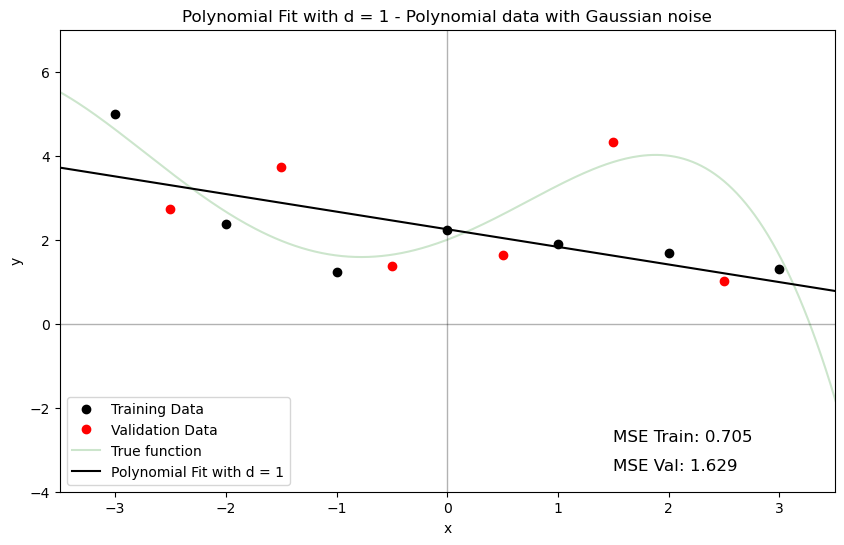

The polynomial is: 1.626320171 -0.4194555386 x +0.1556782875 x**2 



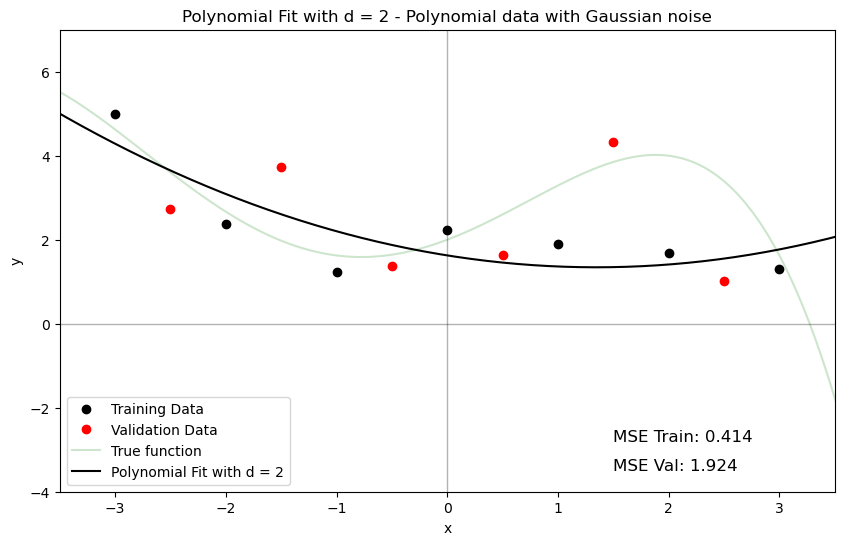

The polynomial is: 1.626320171 +0.2923726871 x +0.1556782875 x**2 -0.1016897465 x**3 



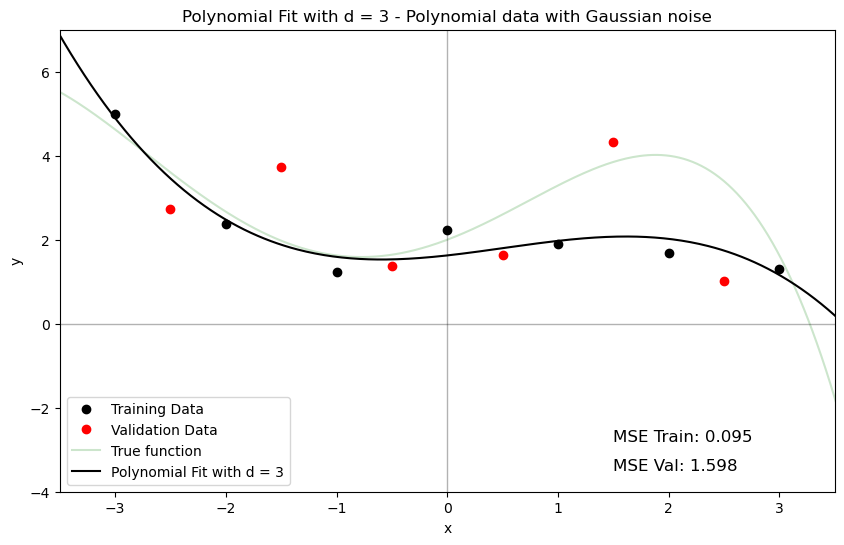

The polynomial is: 1.899295579 +0.2923726871 x -0.09834049462 x**2 -0.1016897465 x**3 +0.02653927574 x**4 



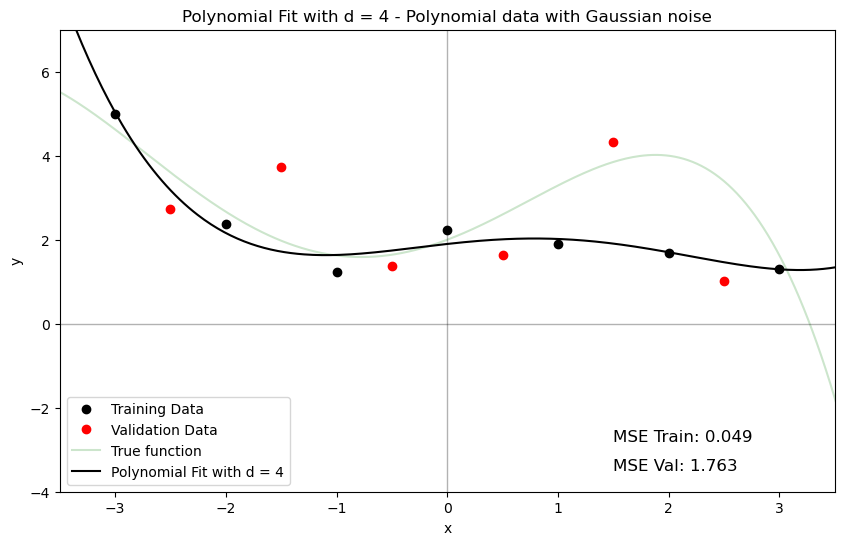

The polynomial is: 1.899295579 +0.550700738 x -0.09834049462 x**2 -0.2224729001 x**3 +0.02653927574 x**4 +0.01035284174 x**5 



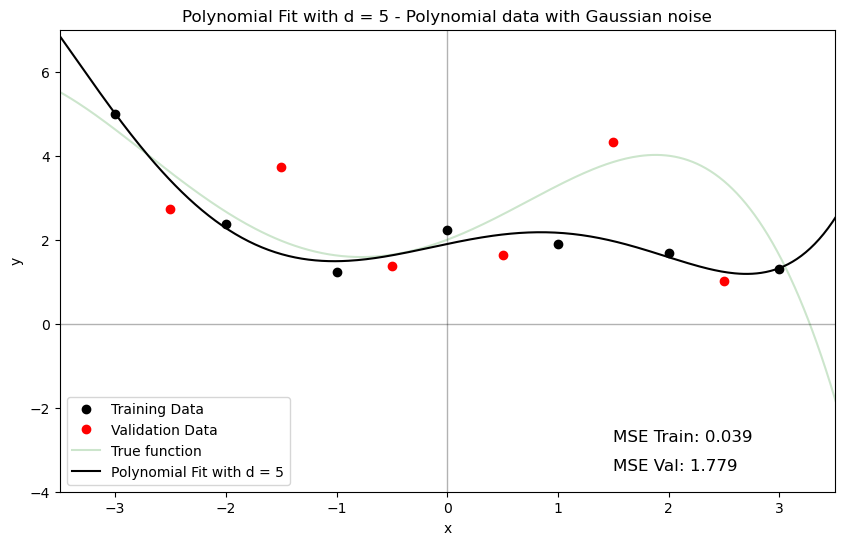

The polynomial is: 2.242937923 +0.550700738 x -0.9683283612 x**2 -0.2224729001 x**3 +0.3172034247 x**4 +0.01035284174 x**5 -0.02205038371 x**6 



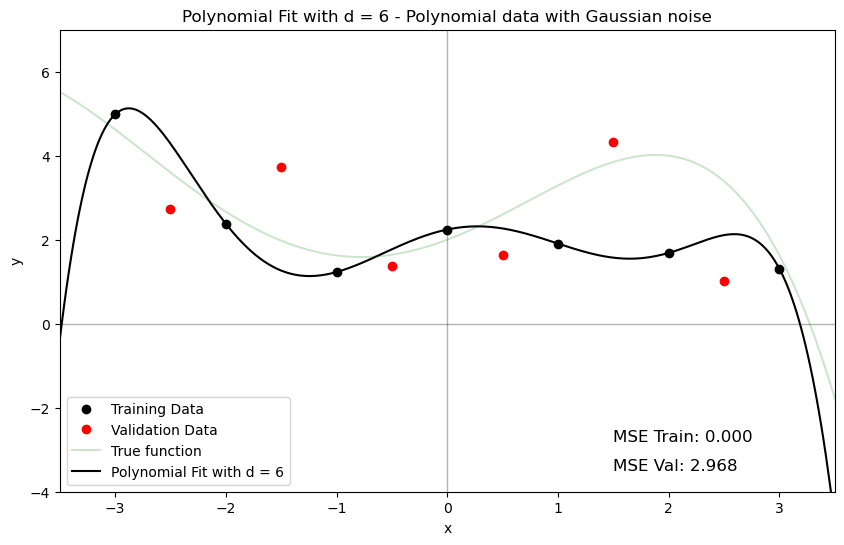

The polynomial is: 2.242937923 +0.2652954518 x -0.9683283612 x**2 +0.1659954061 x**3 +0.3172034247 x**4 -0.1006381029 x**5 -0.02205038371 x**6 +0.007927924616 x**7 



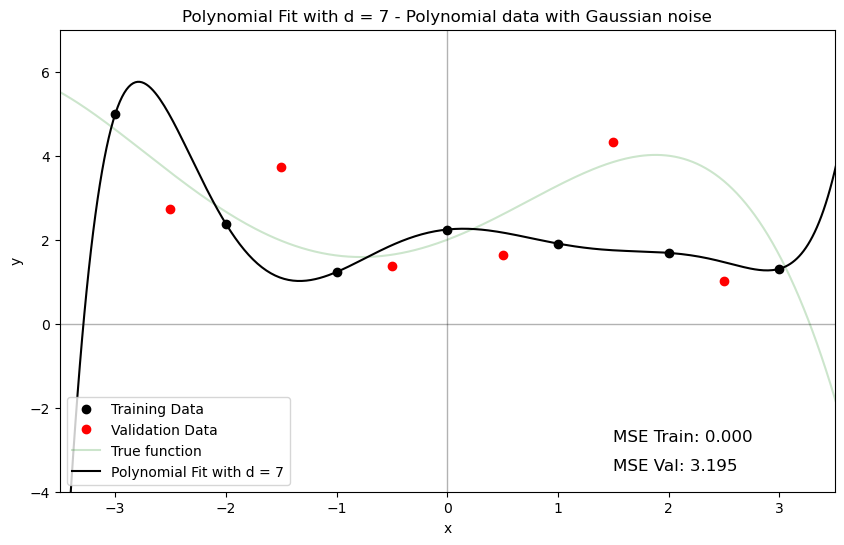

The polynomial is: 2.242937923 +0.265295452 x -0.4995009874 x**2 +0.1659954058 x**3 -0.3209227231 x**4 -0.1006381028 x**5 +0.1602713728 x**6 +0.00792792461 x**7 -0.01302298261 x**8 



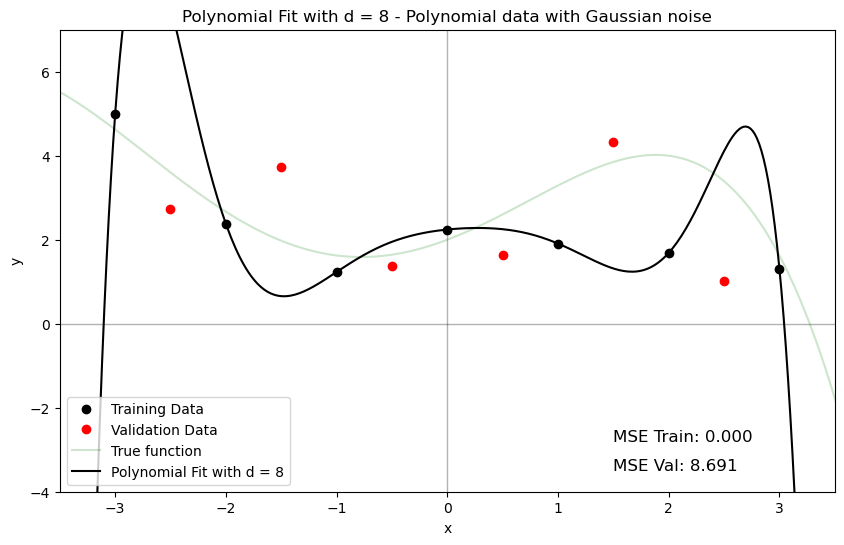

The polynomial is: 2.242937923 +0.1577992644 x -0.4995009884 x**2 +0.1424272936 x**3 -0.3209227217 x**4 +0.08878660238 x**5 +0.1602713724 x**6 -0.05515143537 x**7 -0.01302298258 x**8 +0.004718954657 x**9 



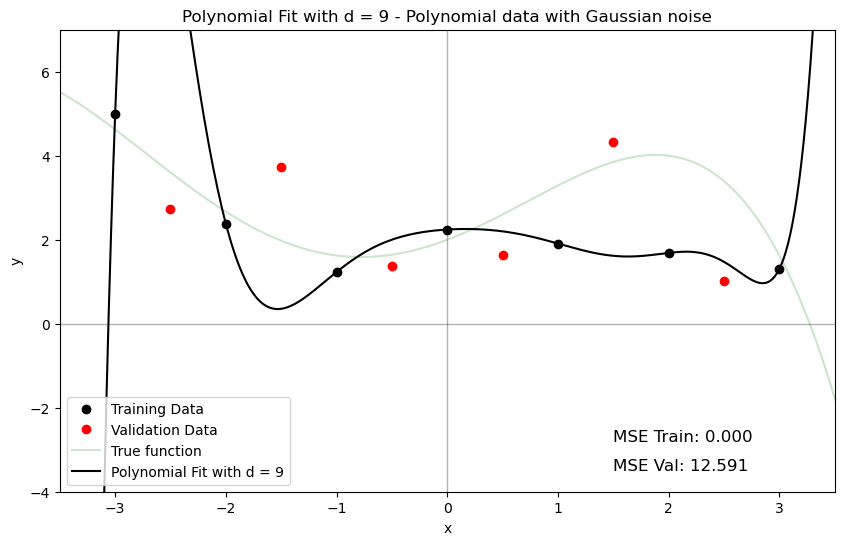

In [137]:
# Assuming polynomial_fits is a list of PolynomialTorch objects and solutions is a list of tuples containing the degree,
# omega solutions, polynomial objects, MSE for training, and MSE for validation.

# Example preparation (ensure these are defined appropriately in your actual code)
# polynomial_fits = [PolynomialTorch(omega_solution)(x) for d in range(8)]
# solutions = [(d, omega_hat, poly, MSE_train, MSE_val) for d, omega_hat, poly, MSE_train, MSE_val in ...]

def plot_polynomial_fits(x_train: torch.Tensor,
                         y_train: torch.Tensor,
                         x_val: torch.Tensor,
                         y_val: torch.Tensor,
                         polynomial_fits: List[Any],  # Replace with appropriate polynomial object type in PyTorch
                         solutions: List[Tuple[int, torch.Tensor, Any, torch.Tensor, torch.Tensor]],
                         dataset_name: str = "Dataset"
                        ) -> None:
    """Plots polynomial fits along with the training and validation data.
    
    Args:
        x_train: Training data x-values.
        y_train: Training data y-values.
        x_val: Validation data x-values.
        y_val: Validation data y-values.
        polynomial_fits: A list of polynomial fitting functions.
        solutions: A list of tuples containing information about each fit, including MSE for training and validation data.
    """
    for i in range(len(polynomial_fits)):
        print("The polynomial is:", polynomial_fits[i], "\n")
        plt.figure(figsize=(10, 6))
        plt.plot(x_train.numpy(), y_train.numpy(), 'o', label='Training Data', color='black')
        plt.plot(x_val.numpy(), y_val.numpy(), 'o', label='Validation Data', color='red')

        # Generate x values for plotting
        x_values: torch.Tensor = torch.linspace(-4., 4., 400, dtype=torch.float64)
        
        # Generate y values for the original function and its polynomial fit
        y_values_func: torch.Tensor = y(x_values)  # Assuming `y(x_values)` is defined in PyTorch
        y_values_fit: torch.Tensor = polynomial_fits[i](x_values)

        # Display MSE values as text on the plot
        mse_train: torch.Tensor = solutions[i][3]
        mse_val: torch.Tensor = solutions[i][4]
        plt.text(1.5, -2.8, f'MSE Train: {mse_train.item():.3f}', fontsize=12, color='black')
        plt.text(1.5, -3.5, f'MSE Val: {mse_val.item():.3f}', fontsize=12, color='black')
        
        # Plot the function and polynomial fit
        plt.plot(x_values.numpy(), y_values_func.numpy(), label='True function', color='green', alpha=0.2)
        plt.plot(x_values.numpy(), y_values_fit.numpy(), label=f'Polynomial Fit with d = {i}', color='black')
        
        # Draw axes
        plt.axhline(y=0, color='k', linestyle='-', linewidth=1, alpha=0.3)
        plt.axvline(x=0, color='k', linestyle='-', linewidth=1, alpha=0.3)
        
        # Finalizing plot
        plt.title(f'Polynomial Fit with d = {i} - {dataset_name}')
        plt.xlabel('x')
        plt.ylabel('y')
        plt.legend(loc='lower left')
        plt.xlim(-3.5, 3.5)
        plt.ylim(-4, 7)
        plt.show()

# Call the function
plot_polynomial_fits(x_train, y_train, x_val, y_val, polynomial_fits, solutions, "Polynomial data with Gaussian noise")


### Probabilistic model (non-polynomial data)

In [138]:
def y(x: torch.Tensor) -> torch.Tensor:
    """Computes the function 3 + sin(x) - cos(x) for given x values.
    
    Args:
        x: A torch tensor of x values.
    
    Returns:
        A torch tensor of y values computed from the function.
    """
    return (3 + torch.sin(x) - torch.cos(x)).double()

def y_stat(x: torch.Tensor) -> torch.Tensor:
    """Generates noisy polynomial data by adding Gaussian noise to the true y values.

    Args:
        x: A torch tensor of x values.

    Returns:
        A torch tensor of y values computed from the polynomial expression with added Gaussian noise.
    """
    # Generate true y values based on a polynomial expression
    true_y_values = y(x)

    # Add Gaussian noise with mean 0 and standard deviation 1
    noisy_y_values = torch.normal(mean=true_y_values, std=1.0)

    return noisy_y_values

In [139]:
# Generate data coordinates
x_train: torch.Tensor = torch.arange(-3, 4, 1, dtype=torch.float64)
x_val: torch.Tensor = torch.arange(-2.5, 3.5, 1, dtype=torch.float64)

# Generate target values with noise
torch.manual_seed(100)
y_train: torch.Tensor = y_stat(x_train)
y_val: torch.Tensor = y_stat(x_val)

# Prepare a list to store solutions
solutions: List[Tuple[Any, torch.Tensor, Any, torch.Tensor, torch.Tensor]] = []

# Perform the fit for each degree and print the results
show: bool = True
for d in range(10):
    # Generate the design matrix
    X_train: torch.Tensor = design_matrix(d, x_train)
    
    # Compute the weights of the solution
    omega_hat: torch.Tensor = omega_solution(X_train, y_train)
    
    # Define the fit polynomial
    poly = poly_solution(omega_hat)  # Assuming `poly_solution` is adapted for PyTorch
    
    # Compute the MSE for the training and validation data
    MSE_train: torch.Tensor = MSE(omega_hat, x_train, y_train)
    MSE_val: torch.Tensor = MSE(omega_hat, x_val, y_val)
    
    # Store the results
    solutions.append((d, omega_hat, poly, MSE_train, MSE_val))
    
    # Print the results
    if show:
        print(f"===================================================")
        print(f"---------------------- d = {d} ----------------------")
        print(f"===================================================")
        print(f"The degree of the polynomial is: {d}\n")
        # print(f"The hypothesis is: {poly}\n")
        print(f"The design matrix is:\n{X_train}\n")
        print(f"The solution for omega is: {omega_hat}\n")  
        print(f"The polynomial is: {poly}\n")
        print(f"The MSE for the training data is: {MSE_train}")
        print(f"The MSE for the validation data is: {MSE_val}\n")

# Extract polynomial fits
polynomial_fits = [sol[2] for sol in solutions]

---------------------- d = 0 ----------------------
The degree of the polynomial is: 0

The design matrix is:
tensor([[1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.]], dtype=torch.float64)

The solution for omega is: tensor([2.5202], dtype=torch.float64)

The polynomial is: 2.520224853

The MSE for the training data is: 0.9991625789380075
The MSE for the validation data is: 1.2164143621116636

---------------------- d = 1 ----------------------
The degree of the polynomial is: 1

The design matrix is:
tensor([[ 1., -3.],
        [ 1., -2.],
        [ 1., -1.],
        [ 1.,  0.],
        [ 1.,  1.],
        [ 1.,  2.],
        [ 1.,  3.]], dtype=torch.float64)

The solution for omega is: tensor([ 2.5202, -0.0325], dtype=torch.float64)

The polynomial is: 2.520224853 -0.03254416742 x

The MSE for the training data is: 0.9949260876063658
The MSE for the validation data is: 1.224524705388555

---------------------- d = 2 ----------------------
The 

/var/folders/8p/lb_zz6bs7g7cdkt7y_yjy0z40000gn/T/ipykernel_41146/1536676131.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.coefficients = torch.tensor(coefficients, dtype=torch.float64)
/var/folders/8p/lb_zz6bs7g7cdkt7y_yjy0z40000gn/T/ipykernel_41146/1536676131.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float64)


The polynomial is: 2.520224853 



/var/folders/8p/lb_zz6bs7g7cdkt7y_yjy0z40000gn/T/ipykernel_41146/1536676131.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float64)


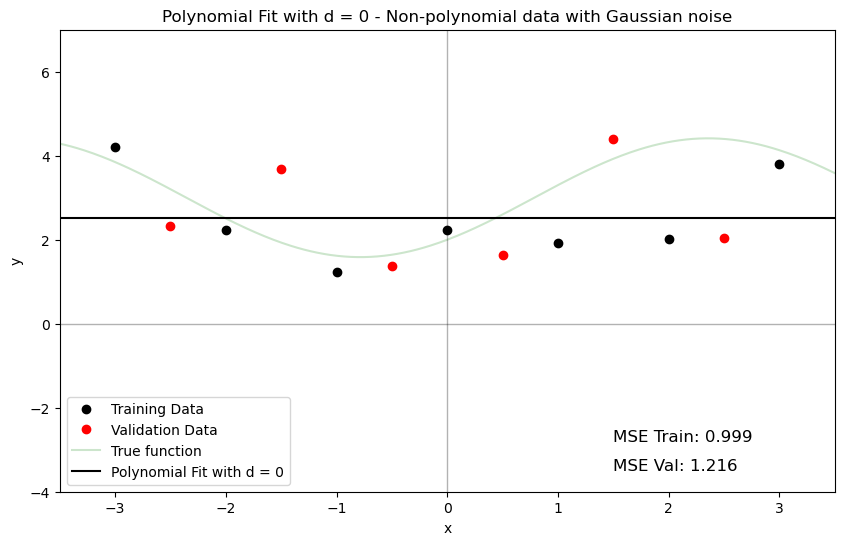

The polynomial is: 2.520224853 -0.03254416742 x 



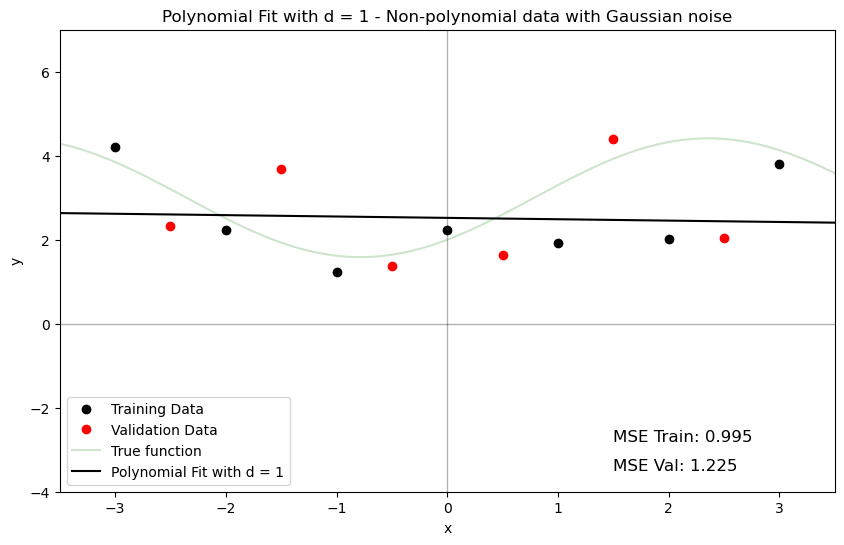

The polynomial is: 1.486000331 -0.03254416742 x +0.2585561304 x**2 



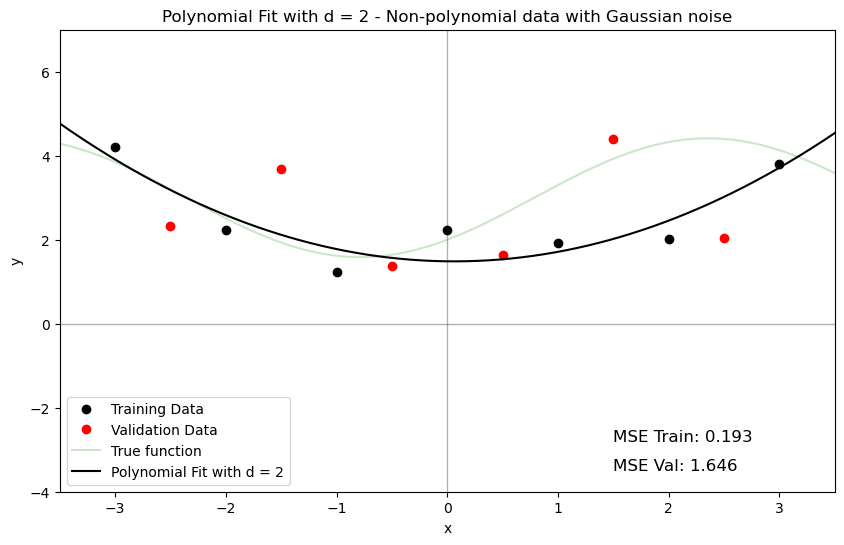

The polynomial is: 1.486000331 +0.1385917707 x +0.2585561304 x**2 -0.02444799116 x**3 



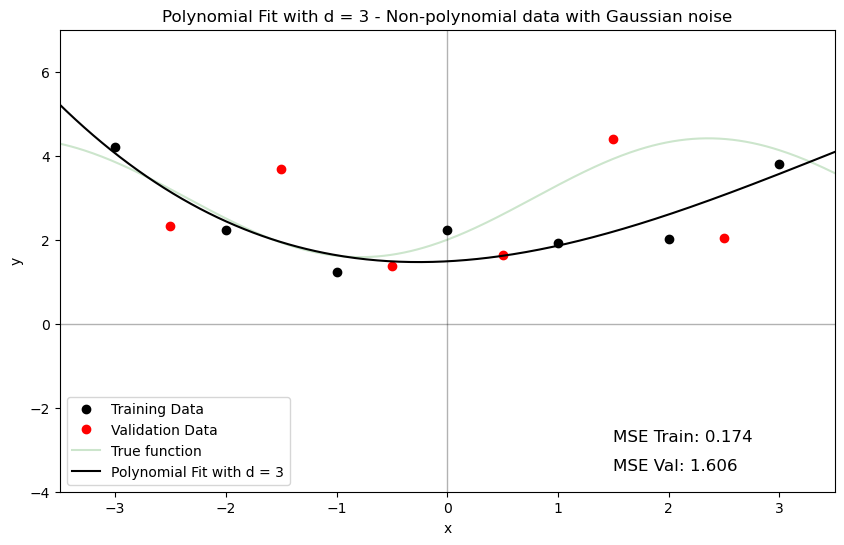

The polynomial is: 1.916117089 +0.1385917707 x -0.1416914082 x**2 -0.02444799116 x**3 +0.04181690702 x**4 



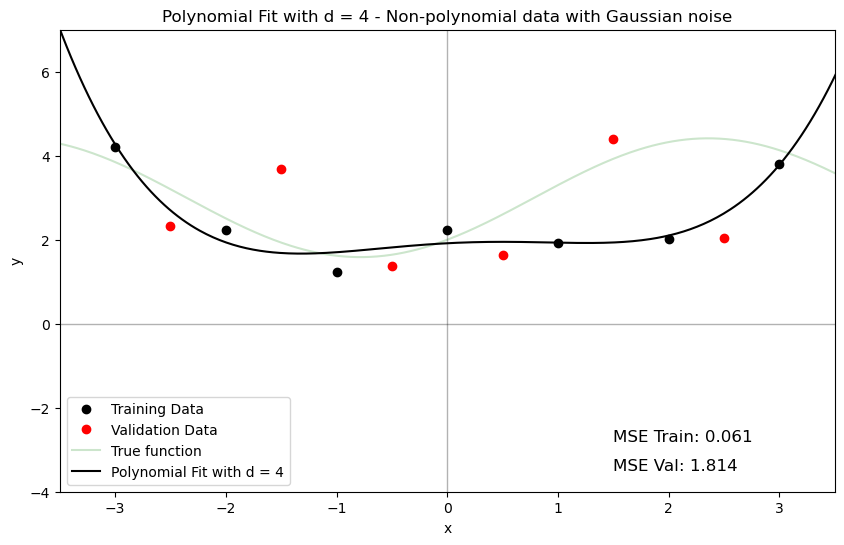

The polynomial is: 1.916117089 +0.5448219874 x -0.1416914082 x**2 -0.2143838749 x**3 +0.04181690702 x**4 +0.01628021861 x**5 



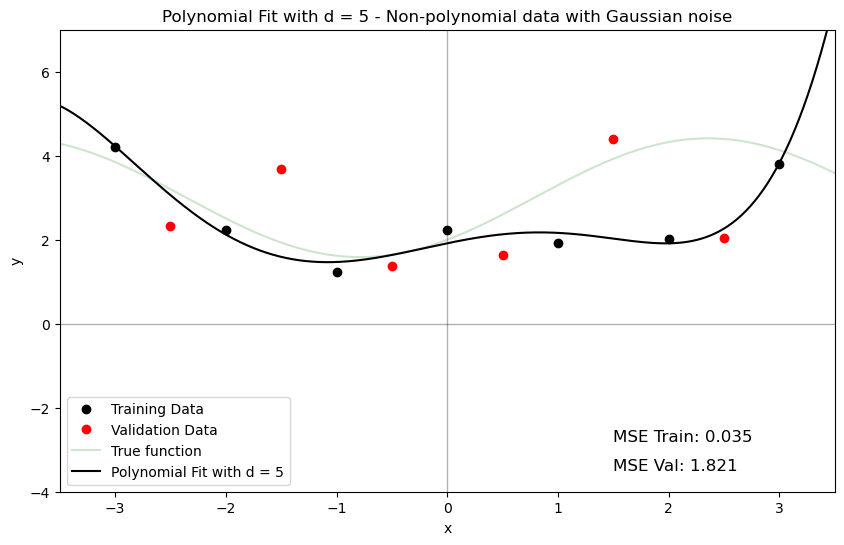

The polynomial is: 2.242937923 +0.5448219874 x -0.9690928177 x**2 -0.2143838749 x**3 +0.3182528618 x**4 +0.01628021861 x**5 -0.02097100347 x**6 



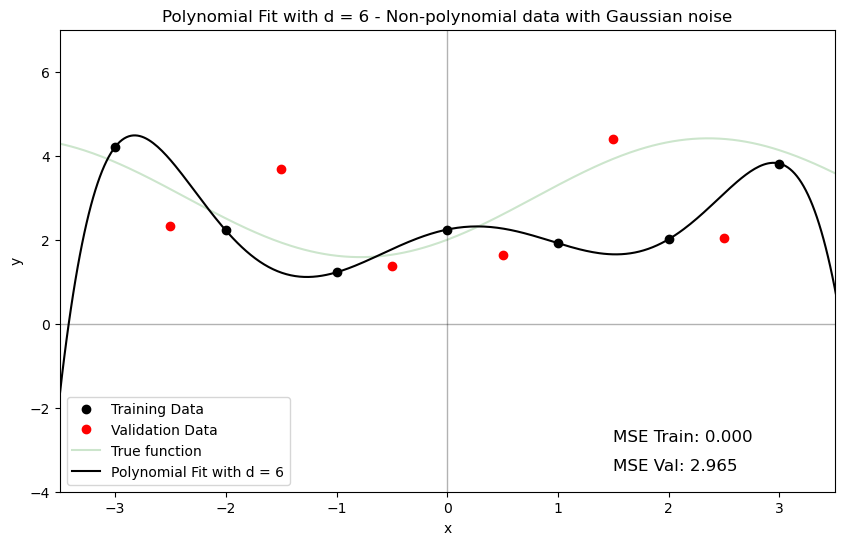

The polynomial is: 2.242937923 +0.2642704514 x -0.9690928177 x**2 +0.167477938 x**3 +0.3182528618 x**4 -0.0928231565 x**5 -0.02097100347 x**6 +0.007793098222 x**7 



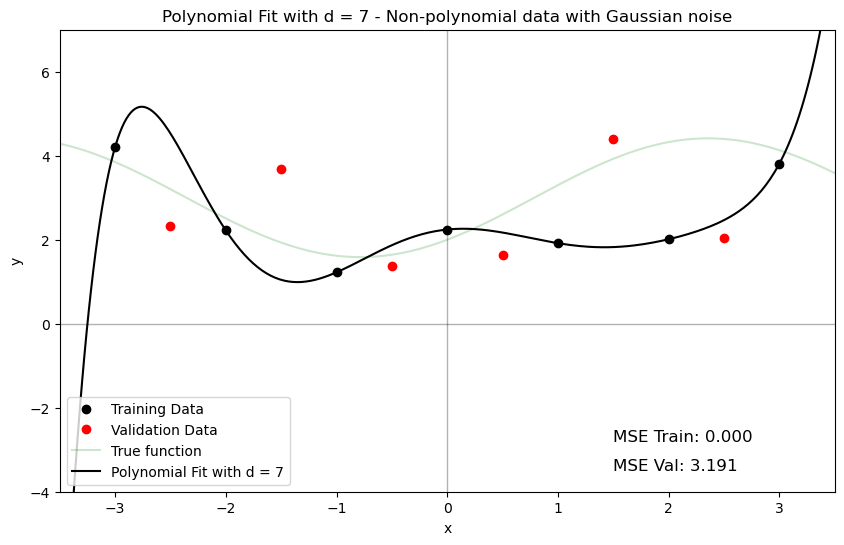

The polynomial is: 2.242937923 +0.2642704516 x -0.499675322 x**2 +0.1674779377 x**3 -0.3206765076 x**4 -0.09282315642 x**5 +0.1615802449 x**6 +0.007793098216 x**7 -0.01303937489 x**8 



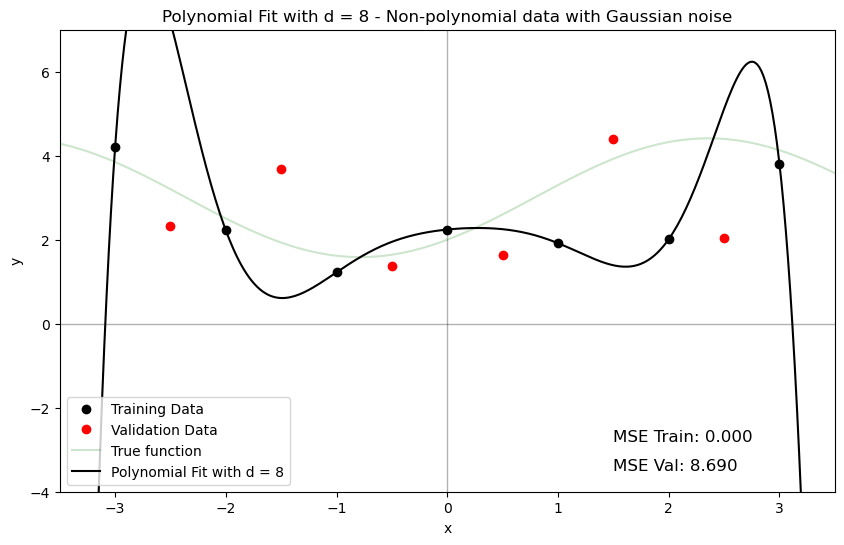

The polynomial is: 2.242937923 +0.1600079891 x -0.499675323 x**2 +0.1446188069 x**3 -0.3206765062 x**4 +0.09090323122 x**5 +0.1615802445 x**6 -0.05338869395 x**7 -0.01303937486 x**8 +0.004576997978 x**9 



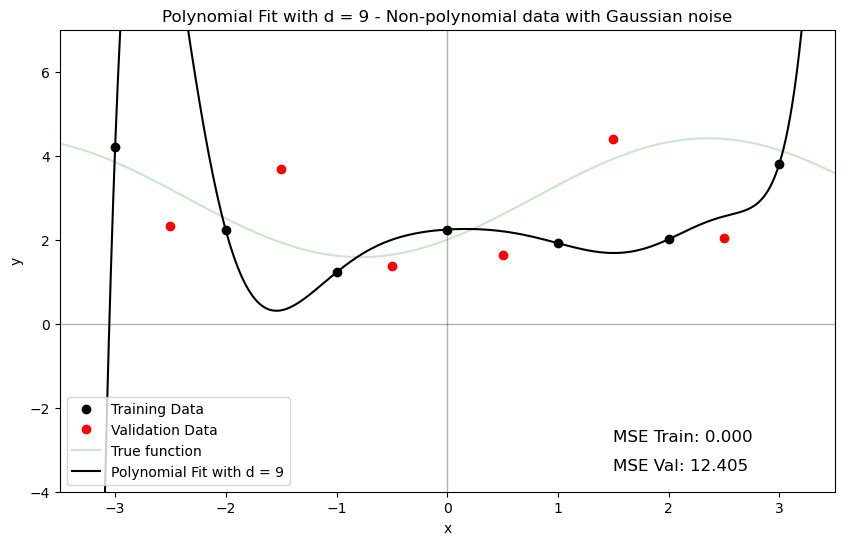

In [140]:
plot_polynomial_fits(x_train, y_train, x_val, y_val, polynomial_fits, solutions, "Non-polynomial data with Gaussian noise")

### Probabilistic model with non-polynomial fit (non-polynomial data)

In [147]:
def y(x: torch.Tensor) -> torch.Tensor:
    """Computes the function 3 + sin(x) - cos(x) for given x values.
    
    Args:
        x: A torch tensor of x values.
    
    Returns:
        A torch tensor of y values computed from the function.
    """
    return (3 + torch.sin(x) - torch.cos(x)).double()

def y_stat(x: torch.Tensor) -> torch.Tensor:
    """Generates noisy polynomial data by adding Gaussian noise to the true y values.

    Args:
        x: A torch tensor of x values.

    Returns:
        A torch tensor of y values computed from the polynomial expression with added Gaussian noise.
    """
    # Generate true y values based on a polynomial expression
    true_y_values = y(x)

    # Add Gaussian noise with mean 0 and standard deviation 1
    noisy_y_values = torch.normal(mean=true_y_values, std=1.0)

    return noisy_y_values

def y_stat_np(x: np.ndarray) -> np.ndarray:
    """Generates noisy polynomial data by adding Gaussian noise to the true y values.
    
    Args:
        x: A numpy array of x values.
    
    Returns:
        A numpy array of y values computed from the polynomial expression with added Gaussian noise.
    """
    # Generate true y values based on a polynomial expression
    true_y_values: np.ndarray = y(torch.tensor(x)).numpy()
    
    # Add Gaussian noise with a mean of 0 and standard deviation of 1 to the true y values
    noisy_y_values: np.ndarray = np.random.normal(true_y_values, 1)
    
    return noisy_y_values

def design_matrix_trig_torch(x_values: torch.Tensor) -> torch.Tensor:
    """Generates a design matrix for trigonometric regression with PyTorch.
    
    Args:
        x_values: A torch.Tensor of x values.
    
    Returns:
        A torch.Tensor representing the design matrix with columns for 1, sin(x), and cos(x).
    """
    ones = torch.ones_like(x_values)
    sin_x = torch.sin(x_values)
    cos_x = torch.cos(x_values)
    # Stack along the second dimension (axis=1) to form the design matrix
    return torch.stack([ones, sin_x, cos_x], dim=1)

def omega_solution(X: torch.Tensor, 
                   Y: torch.Tensor
                  ) -> torch.Tensor:
    """Calculates the polynomial coefficients (omega) that best fit the data.
    
    Args:
        X: The design matrix.
        Y: A torch tensor of target y values.
    
    Returns:
        A torch tensor of calculated omega values.
    """
    XT: torch.Tensor = X.t()  # Transpose of X
    Y: torch.Tensor = Y.view(-1, 1)  # Reshape Y to be a column vector
    omega: torch.Tensor = torch.linalg.pinv(XT @ X) @ XT @ Y
    return omega.view(-1)  # Flatten the omega tensor

def trig_solution(omega_solution: torch.Tensor, 
                  x_values: torch.Tensor
                 ) -> torch.Tensor:
    """Evaluates the trigonometric model at given x values using the omega coefficients.
    
    Args:
        omega_solution: A torch.Tensor of omega coefficients for [constant, sin(x), cos(x)].
        x_values: A torch.Tensor of x values for evaluation.
    
    Returns:
        A torch.Tensor of y values predicted by the trigonometric model.
    """
    return omega_solution[0] + omega_solution[1] * torch.sin(x_values) + omega_solution[2] * torch.cos(x_values)

def MSE(omega_solution: torch.Tensor, 
        x_values: torch.Tensor,
        y_true: torch.Tensor
       ) -> torch.Tensor:
    """Calculates the Mean Squared Error (MSE) for given omega coefficients and x values.
    
    Args:
        omega_solution: A 1D torch.Tensor of omega coefficients.
        x_values: A 1D torch.Tensor of x values for evaluation.
    
    Returns:
        The MSE as a torch.Tensor.
    """
    y_pred: torch.Tensor = trig_solution(omega_solution, x_values)
    return torch.mean((y_true - y_pred)**2)

In [148]:
# Generate data coordinates
x_train = torch.arange(-3, 4, 1, dtype=torch.float64)
x_val = torch.arange(-2.5, 3.5, 1, dtype=torch.float64)

# Generate target values through the statistical model with torch
torch.manual_seed(100)
y_train = y_stat(x_train)
y_val = y_stat(x_val)

# Flag to control printing of the solution details
show = True

# Generate the design matrix
X_train = design_matrix_trig_torch(x_train)

# Compute the weights of the solution
omega_hat = omega_solution(X_train, y_train)

# Compute the MSE for the training and validation data
MSE_train = MSE(omega_hat, x_train, y_train)
MSE_val = MSE(omega_hat, x_val, y_val)

# Print the results
if show:
    print("----------------- Trigonometric Model -----------------")
    print(f"The design matrix is:\n{X_train}\n")
    print(f"The target values are:\n{y_train}\n")
    print(f"The solution for omega is: {omega_hat}\n")
    print(f"The MSE for the training data is: {MSE_train}")
    print(f"The MSE for the validation data is: {MSE_val}\n")

----------------- Trigonometric Model -----------------
The design matrix is:
tensor([[ 1.0000, -0.1411, -0.9900],
        [ 1.0000, -0.9093, -0.4161],
        [ 1.0000, -0.8415,  0.5403],
        [ 1.0000,  0.0000,  1.0000],
        [ 1.0000,  0.8415,  0.5403],
        [ 1.0000,  0.9093, -0.4161],
        [ 1.0000,  0.1411, -0.9900]], dtype=torch.float64)

The target values are:
tensor([4.2095, 2.2209, 1.2244, 2.2429, 1.9178, 2.0120, 3.8139],
       dtype=torch.float64)

The solution for omega is: tensor([ 2.4128,  0.1086, -1.0278], dtype=torch.float64)

The MSE for the training data is: 0.4183487933903772
The MSE for the validation data is: 1.3736800844998454



In [149]:
# Generate data coordinates
x_train = torch.arange(-3, 4, 1, dtype=torch.float64)
x_val = torch.arange(-2.5, 3.5, 1, dtype=torch.float64)

# Set the random seed for reproducibility using NumPy
np.random.seed(100)

# Generate target values through the statistical model with NumPy (for consistency)
y_train = y_stat_np(x_train)
y_val = y_stat_np(x_val)

# Flag to control printing of the solution details
show = True

# Generate the design matrix (Torch)
X_train = design_matrix_trig_torch(x_train)

# Compute the weights of the solution
omega_hat = omega_solution(X_train, torch.tensor(y_train, dtype=torch.float64))

# Compute the MSE for the training and validation data
MSE_train = MSE(omega_hat, x_train, torch.tensor(y_train, dtype=torch.float64))
MSE_val = MSE(omega_hat, x_val, torch.tensor(y_val, dtype=torch.float64))

# Print the results
if show:
    print("----------------- Trigonometric Model -----------------")
    print(f"The design matrix is:\n{X_train}\n")
    print(f"The target values are:\n{y_train}\n")
    print(f"The solution for omega is: {omega_hat}\n")
    print(f"The MSE for the training data is: {MSE_train}")
    print(f"The MSE for the validation data is: {MSE_val}\n")

----------------- Trigonometric Model -----------------
The design matrix is:
tensor([[ 1.0000, -0.1411, -0.9900],
        [ 1.0000, -0.9093, -0.4161],
        [ 1.0000, -0.8415,  0.5403],
        [ 1.0000,  0.0000,  1.0000],
        [ 1.0000,  0.8415,  0.5403],
        [ 1.0000,  0.9093, -0.4161],
        [ 1.0000,  0.1411, -0.9900]], dtype=torch.float64)

The target values are:
[2.09910702 2.84952981 2.77126251 1.74756396 4.28248947 4.8396631
 4.35229217]

The solution for omega is: tensor([ 3.2327,  1.0931, -0.4274], dtype=torch.float64)

The MSE for the training data is: 0.6231208529025825
The MSE for the validation data is: 0.4426790841588111



/var/folders/8p/lb_zz6bs7g7cdkt7y_yjy0z40000gn/T/ipykernel_41146/2030768385.py:39: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  true_y_values: np.ndarray = y(torch.tensor(x)).numpy()


Fit with true function



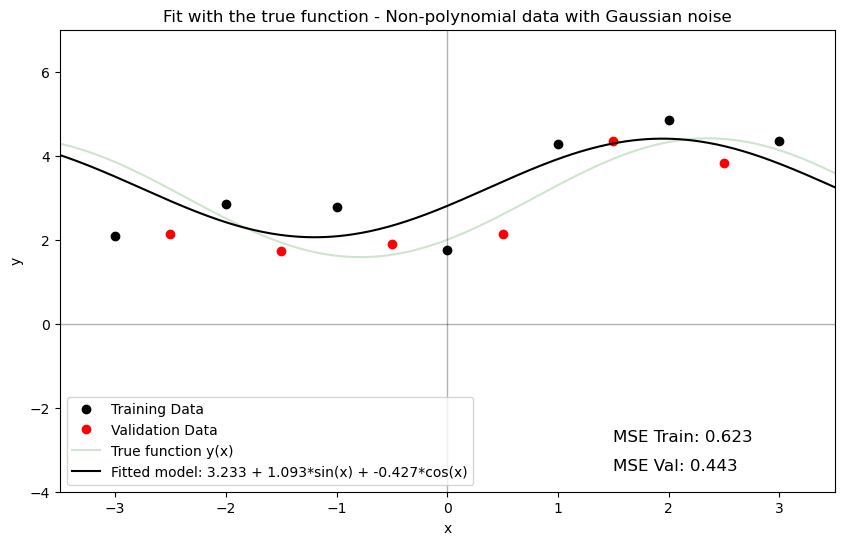

In [150]:
# Print the results
print("Fit with true function\n")
omega_hat_str = f"{omega_hat[0]:.3f} + {omega_hat[1]:.3f}*sin(x) + {omega_hat[2]:.3f}*cos(x)"

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(x_train.numpy(), y_train, 'o', label='Training Data', color='black')
plt.plot(x_val.numpy(), y_val, 'o', label='Validation Data', color='red')

# Generate x values for plotting (to create a smooth curve for the plot)
x_values = torch.linspace(-4., 4., 400, dtype=torch.float64)

# Generate y values for the function and the fitted model
y_values_func = y(x_values)
y_values_fit = trig_solution(omega_hat, x_values)

# Plot the results
plt.text(1.5, -2.8, f'MSE Train: {MSE_train:.3f}', fontsize=12, color='black')
plt.text(1.5, -3.5, f'MSE Val: {MSE_val:.3f}', fontsize=12, color='black')
plt.plot(x_values.numpy(), y_values_func.numpy(), label='True function y(x)', color='green', alpha=0.2)
plt.plot(x_values.numpy(), y_values_fit.numpy(), label=f'Fitted model: {omega_hat_str}', color='black')

# Drawing axes
plt.axhline(y=0, color='k', linestyle='-', linewidth=1, alpha=0.3)
plt.axvline(x=0, color='k', linestyle='-', linewidth=1, alpha=0.3)

# Finalizing plot
plt.title('Fit with the true function - Non-polynomial data with Gaussian noise')
plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc='lower left')
plt.xlim(-3.5, 3.5)
plt.ylim(-4, 7)
plt.show()